# LAB 01 - THỰC HÀNH: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU

## 1.1. THỐNG KÊ MÔ TẢ

### Bài toán 1

#### Nhiệm vụ 1: Khám phá dữ liệu COVID

In [36]:
# Import thư viện
import numpy as np
import pandas as pd
from scipy import stats

#Load the .csv into a dataframe using read_csv (Vì file dữ liệu gốc owid-covid-data quá lớn nên trong bài này đã rút gọn thành file chỉ chứa 6 cột đầu)
covid_data = pd.read_csv("Data/covid_6cols.csv")
covid_data = covid_data[['iso_code','continent','location','date','total_cases','new_cases']]
# Take a quick look at the data
covid_data.head(5)
covid_data.dtypes
covid_data.shape

(350085, 6)

In [37]:
# Bỏ các giá trị NaN trong cột new_cases
new_cases = covid_data["new_cases"].dropna()

In [41]:
# Tính mean, median, mode, variance, standard deviation, range, percentile, quartile, interquartile range (IQR) của biến new_cases

# Get the mean of the data
data_mean = np.mean(new_cases)
# Get the median of the data
data_median = np.median(new_cases)
# Get the mode of the data
data_mode = stats.mode(new_cases)
# Obtain the variance of the data
data_variance = np.var(new_cases)
# Obtain the standard deviation of the data
data_sd = np.std(new_cases)
# Compute the maximum and minimum values of the data
data_max = np.max(new_cases)
data_min = np.min(new_cases)
# Obtain the 60th percentile of the data
data_percentile = np.percentile(new_cases,60)
# Obtain the quartiles of the data
data_quartile = np.quantile(new_cases,0.75)
# Get the IQR of the data
data_IQR = stats.iqr(new_cases)

In [42]:
# Fix mode cho mọi phiên bản SciPy
mode_value = data_mode.mode if np.isscalar(data_mode.mode) else data_mode.mode[0]

In [44]:
# In kết quả
print("Thống kê mô tả cho biến new_cases:\n")
print(f"Mean (Trung bình): {data_mean:.2f}")
print(f"Median (Trung vị): {data_median:.2f}")
print(f"Mode (Mode): {mode_value:.2f}")
print(f"Variance (Phương sai): {data_variance:.2f}")
print(f"Standard Deviation (Độ lệch chuẩn): {data_sd:.2f}")
print(f"Max (Giá trị lớn nhất): {data_max}")
print(f"Min (Giá trị nhỏ nhất): {data_min}")
print(f"60th Percentile: {data_percentile:.2f}")
print(f"3rd Quartile (Q3): {data_quartile:.2f}")
print(f"IQR (Khoảng tứ phân vị): {data_IQR:.2f}")

Thống kê mô tả cho biến new_cases:

Mean (Trung bình): 9601.63
Median (Trung vị): 2.00
Mode (Mode): 0.00
Variance (Phương sai): 12160956141.24
Standard Deviation (Độ lệch chuẩn): 110276.73
Max (Giá trị lớn nhất): 8401961.0
Min (Giá trị nhỏ nhất): 0.0
60th Percentile: 22.00
3rd Quartile (Q3): 264.00
IQR (Khoảng tứ phân vị): 264.00


#### Nhiệm vụ 2: Khám phá và xử lý dữ liệu Marketing Campaign

In [47]:
# Đọc dữ liệu
import pandas as pd
marketing_data = pd.read_csv("Data/marketing_campaign.csv", delimiter="\t")
marketing_data = marketing_data[['ID','Year_Birth', 'Education', 'Marital_Status','Income', 'Kidhome',
                                 'Teenhome', 'Dt_Customer', 'Recency', 'NumStorePurchases','NumWebVisitsMonth']]

In [48]:
# Loại bỏ dữ liệu trùng lặp
marketing_data.head()
# Remove duplicates across the columns in our dataset:
marketing_data_duplicate = marketing_data.drop_duplicates()
# Delete a specified row at index value 1:
marketing_data.drop(labels=[1], axis=0)
# Delete a single column
marketing_data.drop(labels=['Year_Birth'], axis=1)

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,NumStorePurchases,NumWebVisitsMonth
0,5524,Graduation,Single,58138.0,0,0,04-09-2012,58,4,7
1,2174,Graduation,Single,46344.0,1,1,08-03-2014,38,2,5
2,4141,Graduation,Together,71613.0,0,0,21-08-2013,26,10,4
3,6182,Graduation,Together,26646.0,1,0,10-02-2014,26,4,6
4,5324,PhD,Married,58293.0,1,0,19-01-2014,94,6,5
...,...,...,...,...,...,...,...,...,...,...
2235,10870,Graduation,Married,61223.0,0,1,13-06-2013,46,4,5
2236,4001,PhD,Together,64014.0,2,1,10-06-2014,56,5,7
2237,7270,Graduation,Divorced,56981.0,0,0,25-01-2014,91,13,6
2238,8235,Master,Together,69245.0,0,1,24-01-2014,8,10,3


In [49]:
# Thay thế dữ liệu và thay đổi định dạng của dữ liệu

# Replace the values in Teenhome with has teen and has no teen
marketing_data['Teenhome_replaced'] = marketing_data['Teenhome'].replace([0,1,2],['has no teen','has teen','has teen'])
# Fill NAs in the Income column
marketing_data['Income'] = marketing_data['Income'].fillna(0)
# Change the data type of the Income column from float to int
marketing_data['Income_changed'] = marketing_data['Income'].astype(int)

In [50]:
# Xử lý dữ liệu thiếu
# Check for missing values using the isnull and sum methods
marketing_data.isnull().sum()
# Drop missing values using the dropna method
marketing_data_withoutna = marketing_data.dropna(how = 'any')
marketing_data_withoutna.shape

(2240, 13)

### Bài tập thực hành 1

In [51]:
# Import thư viện
import pandas as pd
import numpy as np
from scipy import stats

In [52]:
# Đọc dữ liệu
df = pd.read_csv("Data/winequality-red.csv")
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         

In [58]:
# Cột quality là biến mục tiêu
data_col = df['quality']

# Tính các chỉ số thống kê
mean_val = np.mean(data_col)
median_val = np.median(data_col)
mode_val = stats.mode(data_col, keepdims=True)[0][0]   # mode
var_val = np.var(data_col, ddof=1)                     # phương sai
std_val = np.std(data_col, ddof=1)                     # độ lệch chuẩn
min_val = np.min(data_col)
max_val = np.max(data_col)
range_val = max_val - min_val

q25 = np.percentile(data_col, 25)
q50 = np.percentile(data_col, 50)
q75 = np.percentile(data_col, 75)
iqr_val = q75 - q25

# In kết quả
print("Thống kê mô tả cho cột quality:\n")
print(f"Mean (Trung bình): {mean_val}")
print(f"Median (Trung vị): {median_val}")
print(f"Mode (Mode): {mode_val}")
print(f"Variance (Phương sai): {var_val}")
print(f"Standard Deviation (Độ lệch chuẩn): {std_val}")
print(f"Range (Khoảng): {range_val}")
print(f"25th Percentile: {q25}")
print(f"50th Percentile (Median): {q50}")
print(f"75th Percentile: {q75}")
print(f"IQR (Interquartile Range): {iqr_val}")

Thống kê mô tả cho cột quality:

Mean (Trung bình): 5.6360225140712945
Median (Trung vị): 6.0
Mode (Mode): 5
Variance (Phương sai): 0.6521683999934209
Standard Deviation (Độ lệch chuẩn): 0.8075694397347023
Range (Khoảng): 5
25th Percentile: 5.0
50th Percentile (Median): 6.0
75th Percentile: 6.0
IQR (Interquartile Range): 1.0


### Bài tập thực hành 2

In [63]:
# Import thư viện
import pandas as pd
import numpy as np
from scipy import stats

# Đọc dữ liệu
df = pd.read_csv("Data/diabetes.csv")

In [62]:
# Cột Outcome là biến mục tiêu
data_col = df['Outcome']

# Tính các chỉ số thống kê
mean_val = np.mean(data_col)
median_val = np.median(data_col)
mode_val = stats.mode(data_col, keepdims=True)[0][0]
var_val = np.var(data_col, ddof=1)
std_val = np.std(data_col, ddof=1)
min_val = np.min(data_col)
max_val = np.max(data_col)
range_val = max_val - min_val

q25 = np.percentile(data_col, 25)
q50 = np.percentile(data_col, 50)
q75 = np.percentile(data_col, 75)
iqr_val = q75 - q25

# In kết quả
print(f"Thống kê mô tả cho biến Outcome (tiểu đường):\n")
print(f"Mean (Trung bình): {mean_val}")
print(f"Median (Trung vị): {median_val}")
print(f"Mode (Mode): {mode_val}")
print(f"Variance (Phương sai): {var_val}")
print(f"Standard Deviation (Độ lệch chuẩn): {std_val}")
print(f"Range (Khoảng): {range_val}")
print(f"25th Percentile: {q25}")
print(f"50th Percentile (Median): {q50}")
print(f"75th Percentile: {q75}")
print(f"IQR (Interquartile Range): {iqr_val}")

Thống kê mô tả cho biến Outcome (tiểu đường):

Mean (Trung bình): 0.3489583333333333
Median (Trung vị): 0.0
Mode (Mode): 0
Variance (Phương sai): 0.22748261625380098
Standard Deviation (Độ lệch chuẩn): 0.4769513772427971
Range (Khoảng): 1
25th Percentile: 0.0
50th Percentile (Median): 0.0
75th Percentile: 1.0
IQR (Interquartile Range): 1.0


## 1.2. XỬ LÝ VÀ TRỰC QUAN HÓA DỮ LIỆU

### Bài toán 1

#### Nhiệm vụ 1: 

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Chuẩn bị dữ liệu cho trực quan hóa dữ liệu

import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 400 #high res figures

houseprices_data = pd.read_csv("Data/HousingPrices-Amsterdam-August-2021.csv")
houseprices_data = houseprices_data[['Zip', 'Price', 'Area', 'Room']]
# Create a PriceperSqm variable based on the Price and Area variables:
houseprices_data['PriceperSqm'] = houseprices_data['Price']/houseprices_data['Area']

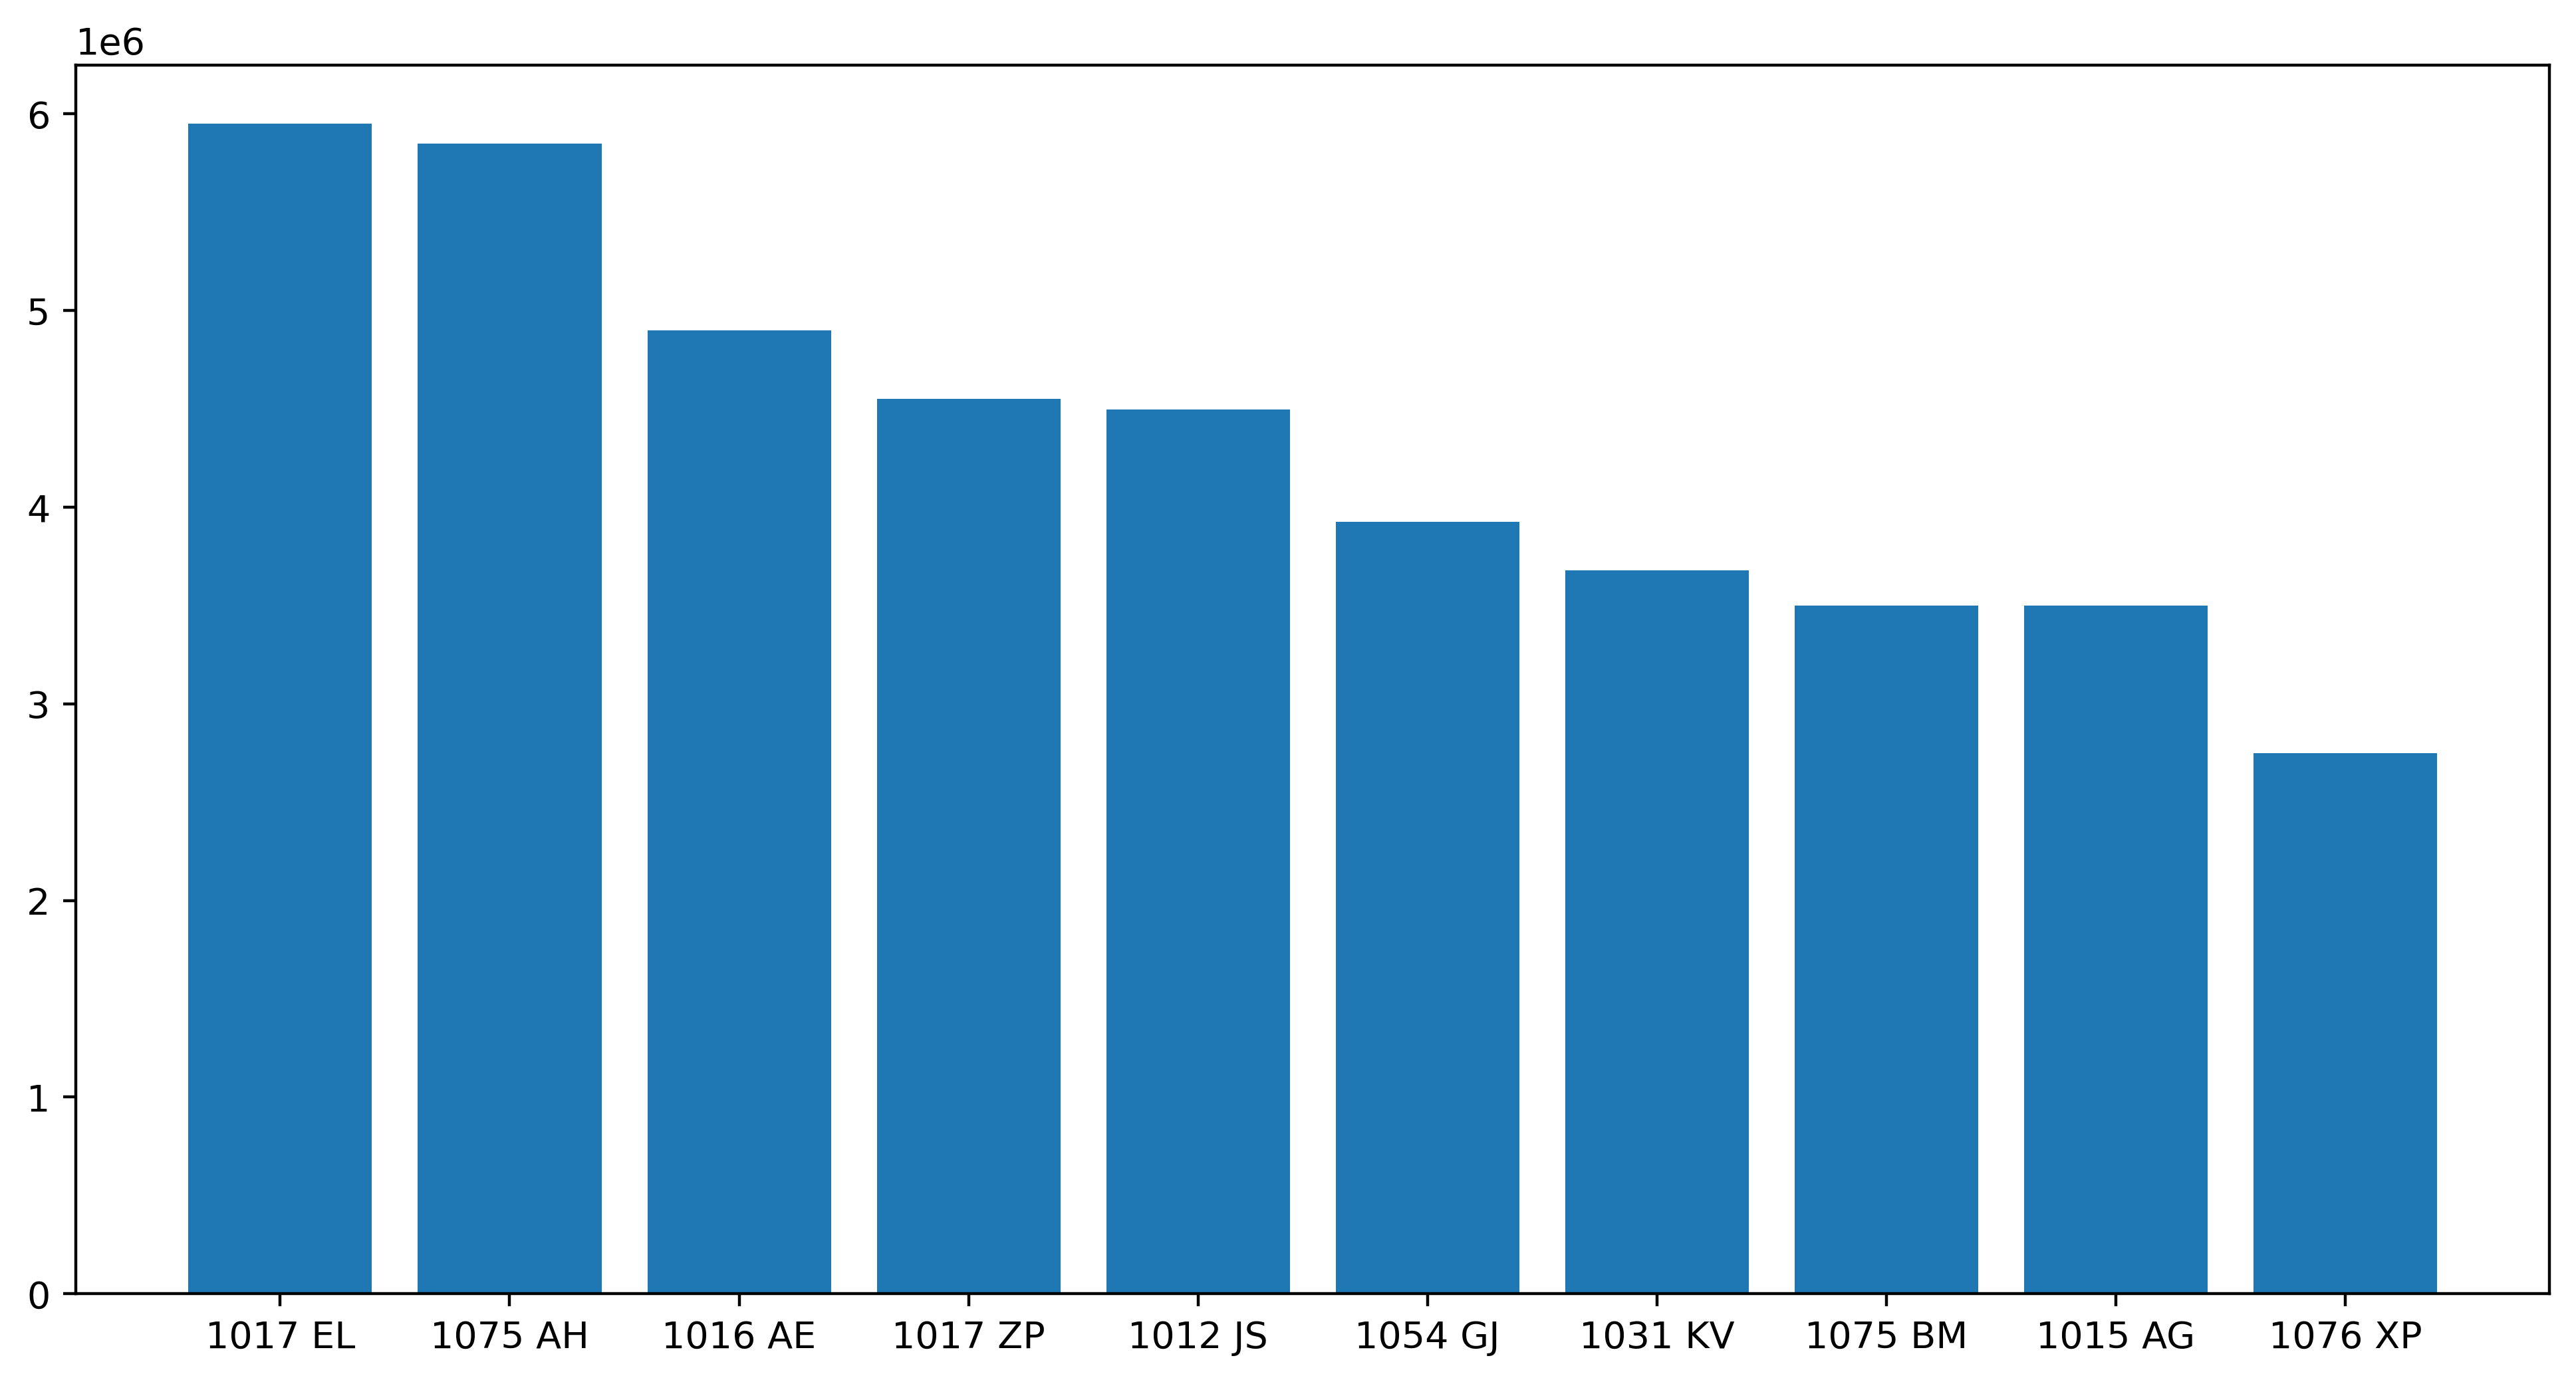

In [3]:
# Trực quan hóa dữ liệu với thư viện Matplotlib
houseprices_sorted = houseprices_data.sort_values('Price', ascending = False)
houseprices_sorted.head()
# case 1: basic
plt.figure(figsize= (12,6))
x = houseprices_sorted['Zip'][0:10]
y = houseprices_sorted['Price'][0:10]
plt.bar(x,y)
plt.show()

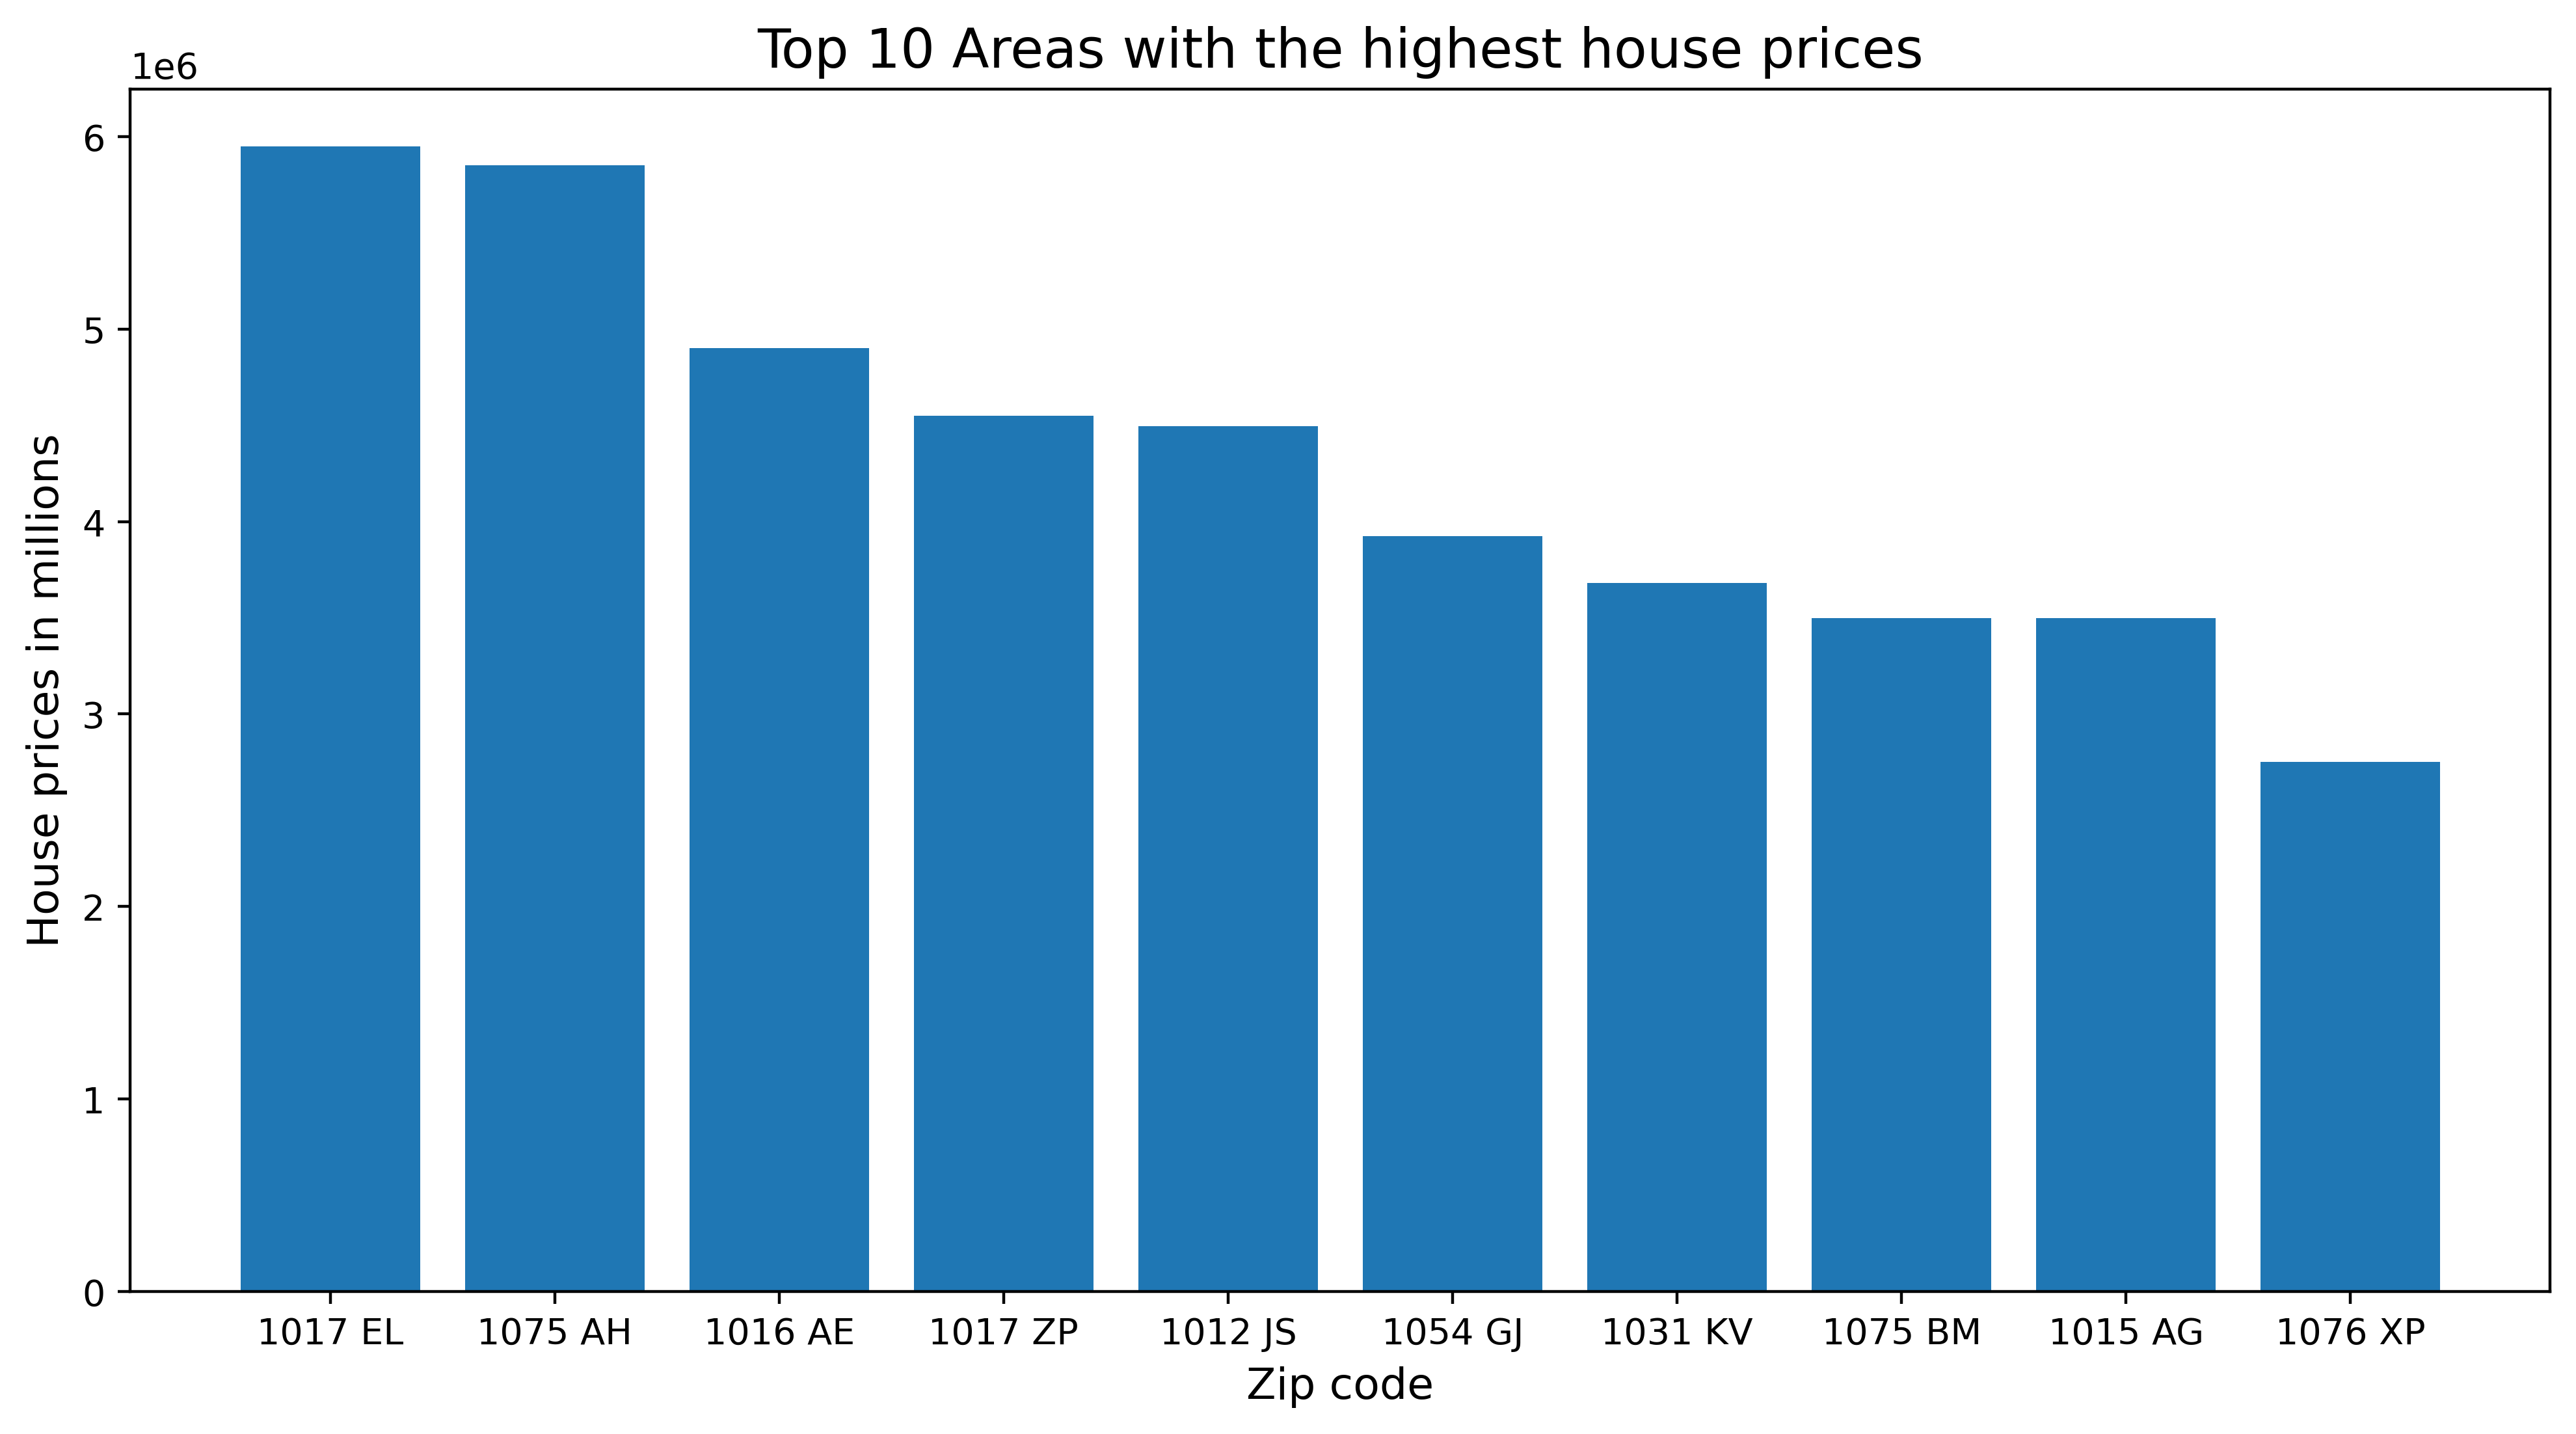

In [76]:
# case 2: advanced 1
plt.figure(figsize= (12,6))
plt.bar(x,y)
plt.title('Top 10 Areas with the highest house prices', fontsize=15)
plt.xlabel('Zip code', fontsize = 12)
plt.xticks(fontsize=10)
plt.ylabel('House prices in millions', fontsize=12)
plt.yticks(fontsize=10)
plt.show()

In [75]:
# case 3: advanced 2
fig, ax = plt.subplots(figsize=(40,18))
x = houseprices_sorted['Zip'][0:10]
y = houseprices_sorted['Price'][0:10]
y1 = houseprices_sorted['PriceperSqm'][0:10]
plt.subplot(1,2,1)
plt.bar(x,y)
plt.xticks(fontsize=17)
plt.ylabel('House prices in millions', fontsize=25)
plt.yticks(fontsize=20)
plt.title('Top 10 Areas with the highest house prices',
fontsize=25)
plt.subplot(1,2,2)
plt.bar(x,y1)
plt.xticks(fontsize=17)
plt.ylabel('House prices per sqm', fontsize=25)
plt.yticks(fontsize=20)
plt.title('Top 10 Areas with the highest house prices per sqm',
fontsize=25)
plt.show()

<Axes: xlabel='Zip', ylabel='Price'>

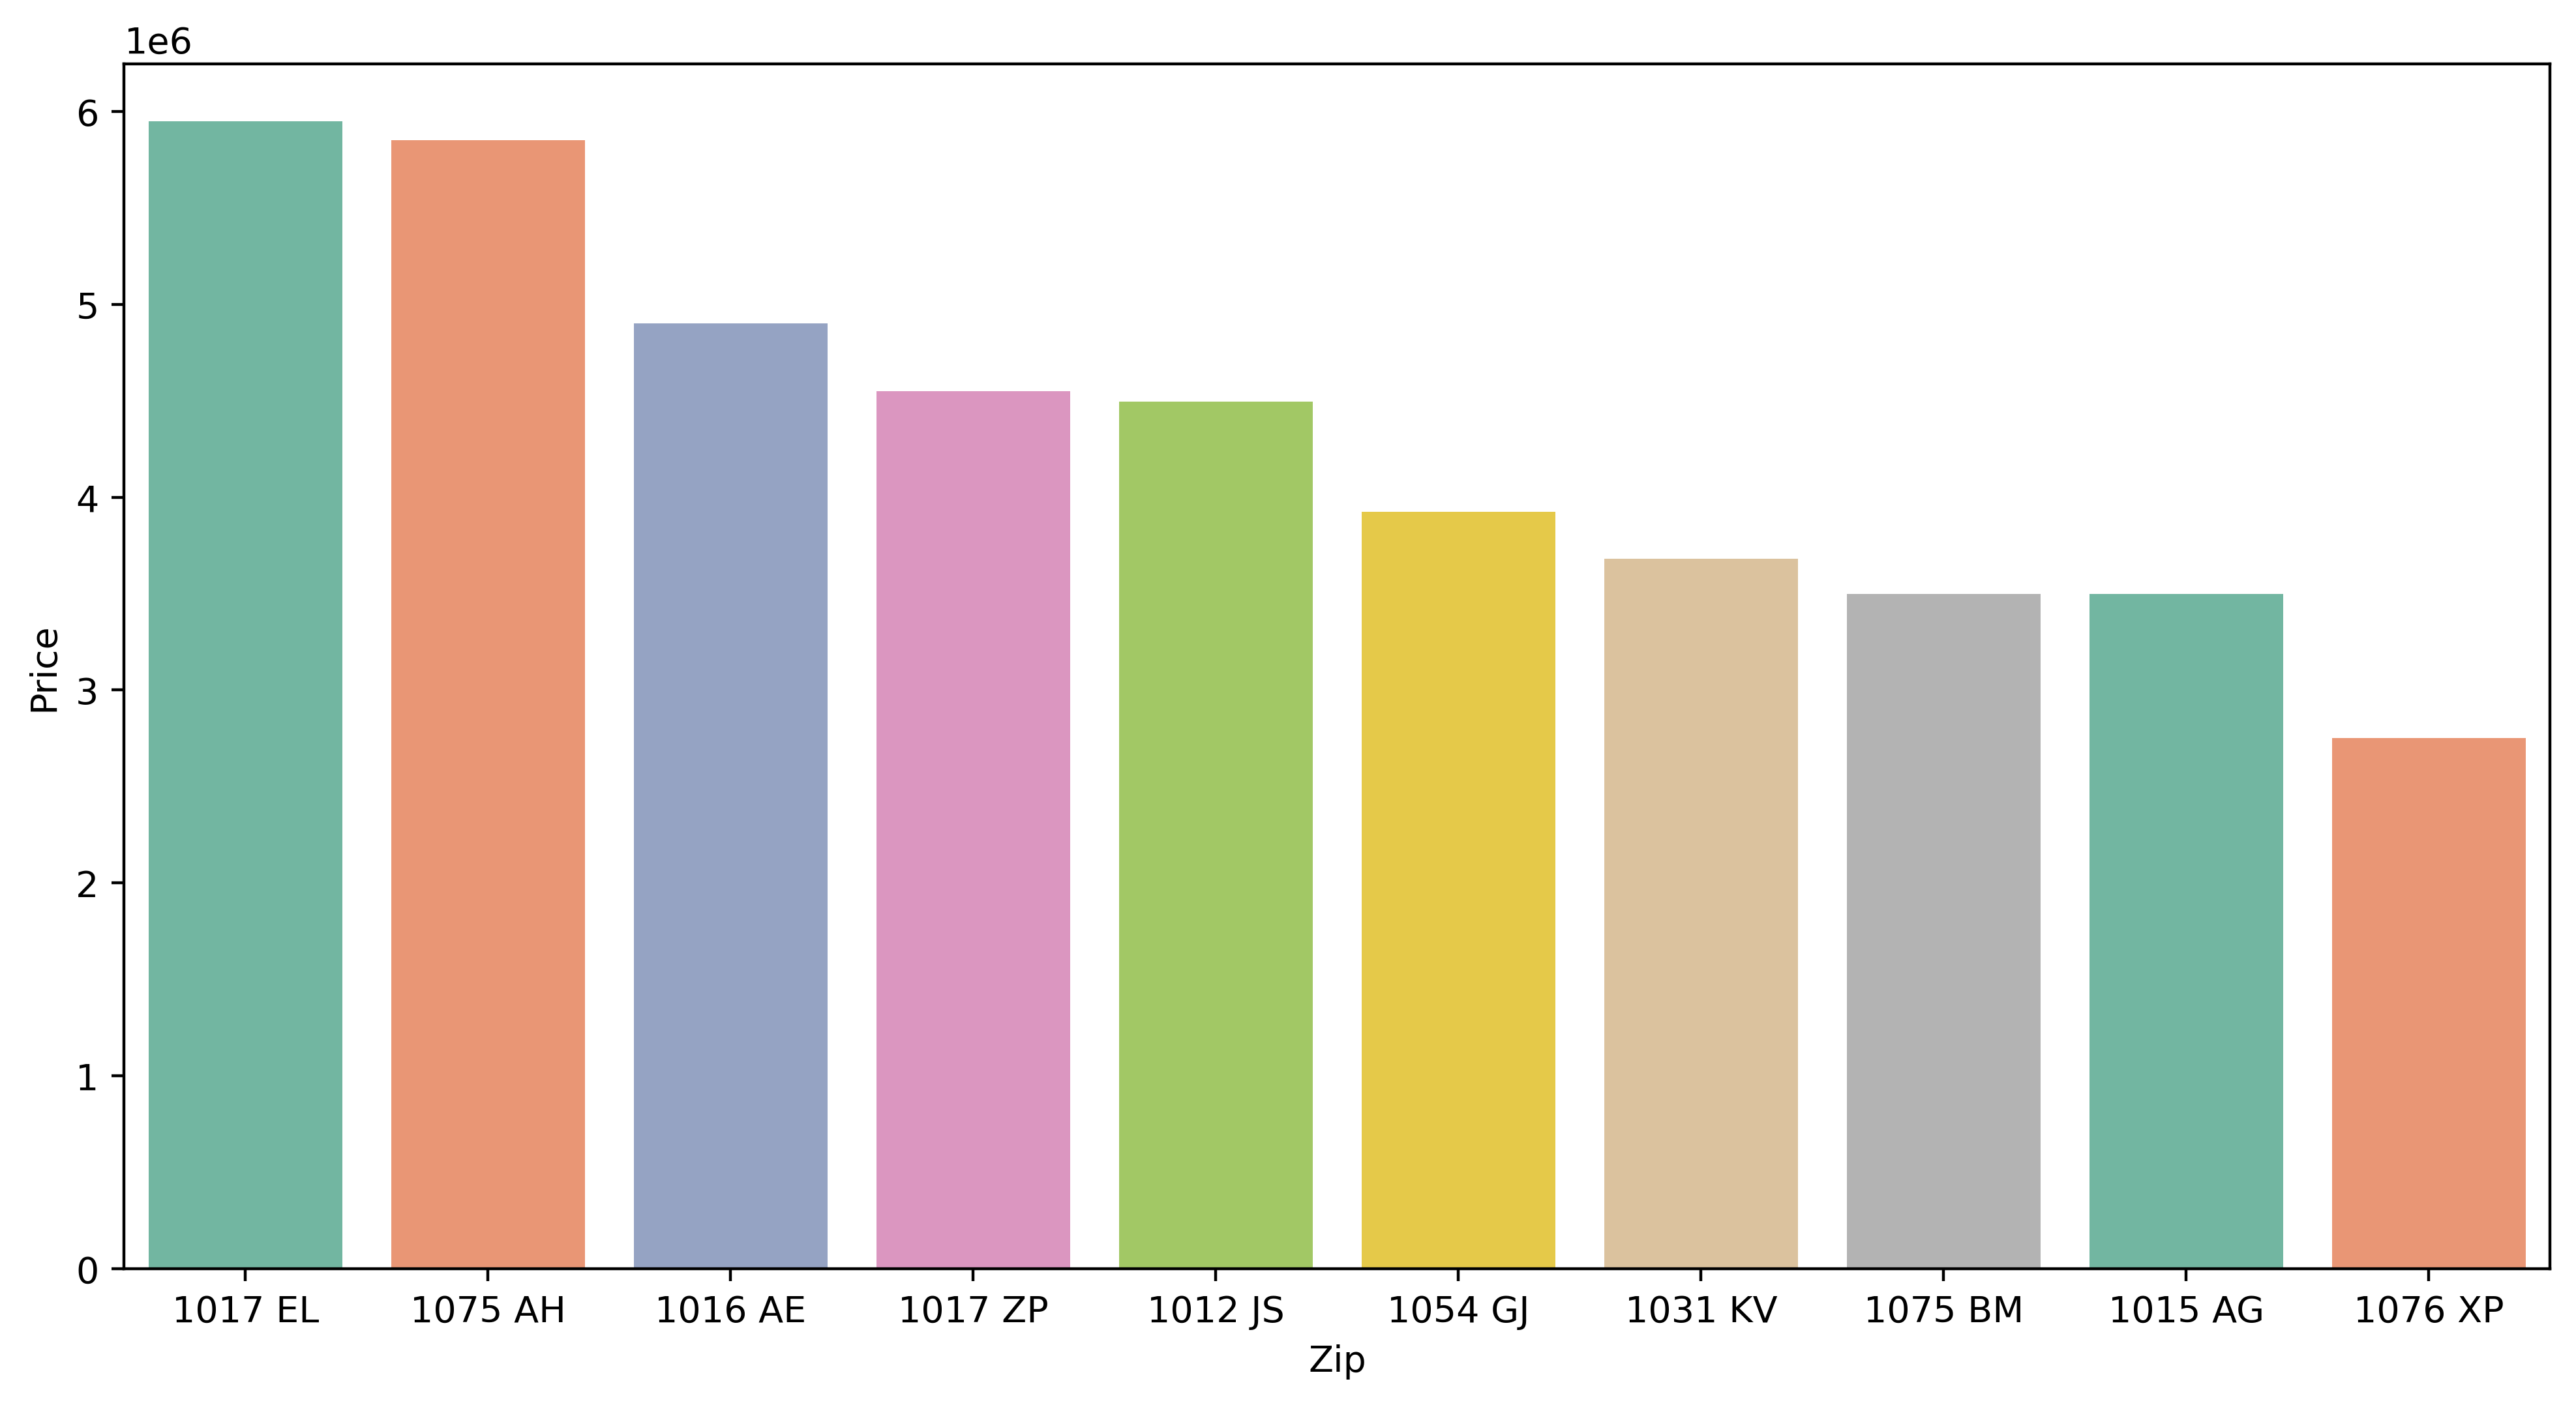

In [79]:
# Trực quan hóa dữ liệu với thư viện Seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# case 1: basic
plt.figure(figsize= (12,6))
data = houseprices_sorted[0:10]
sns.barplot(data=data, x='Zip', y='Price', palette="Set2")

Text(0.5, 1.0, 'Top 10 Areas with the highest house prices')

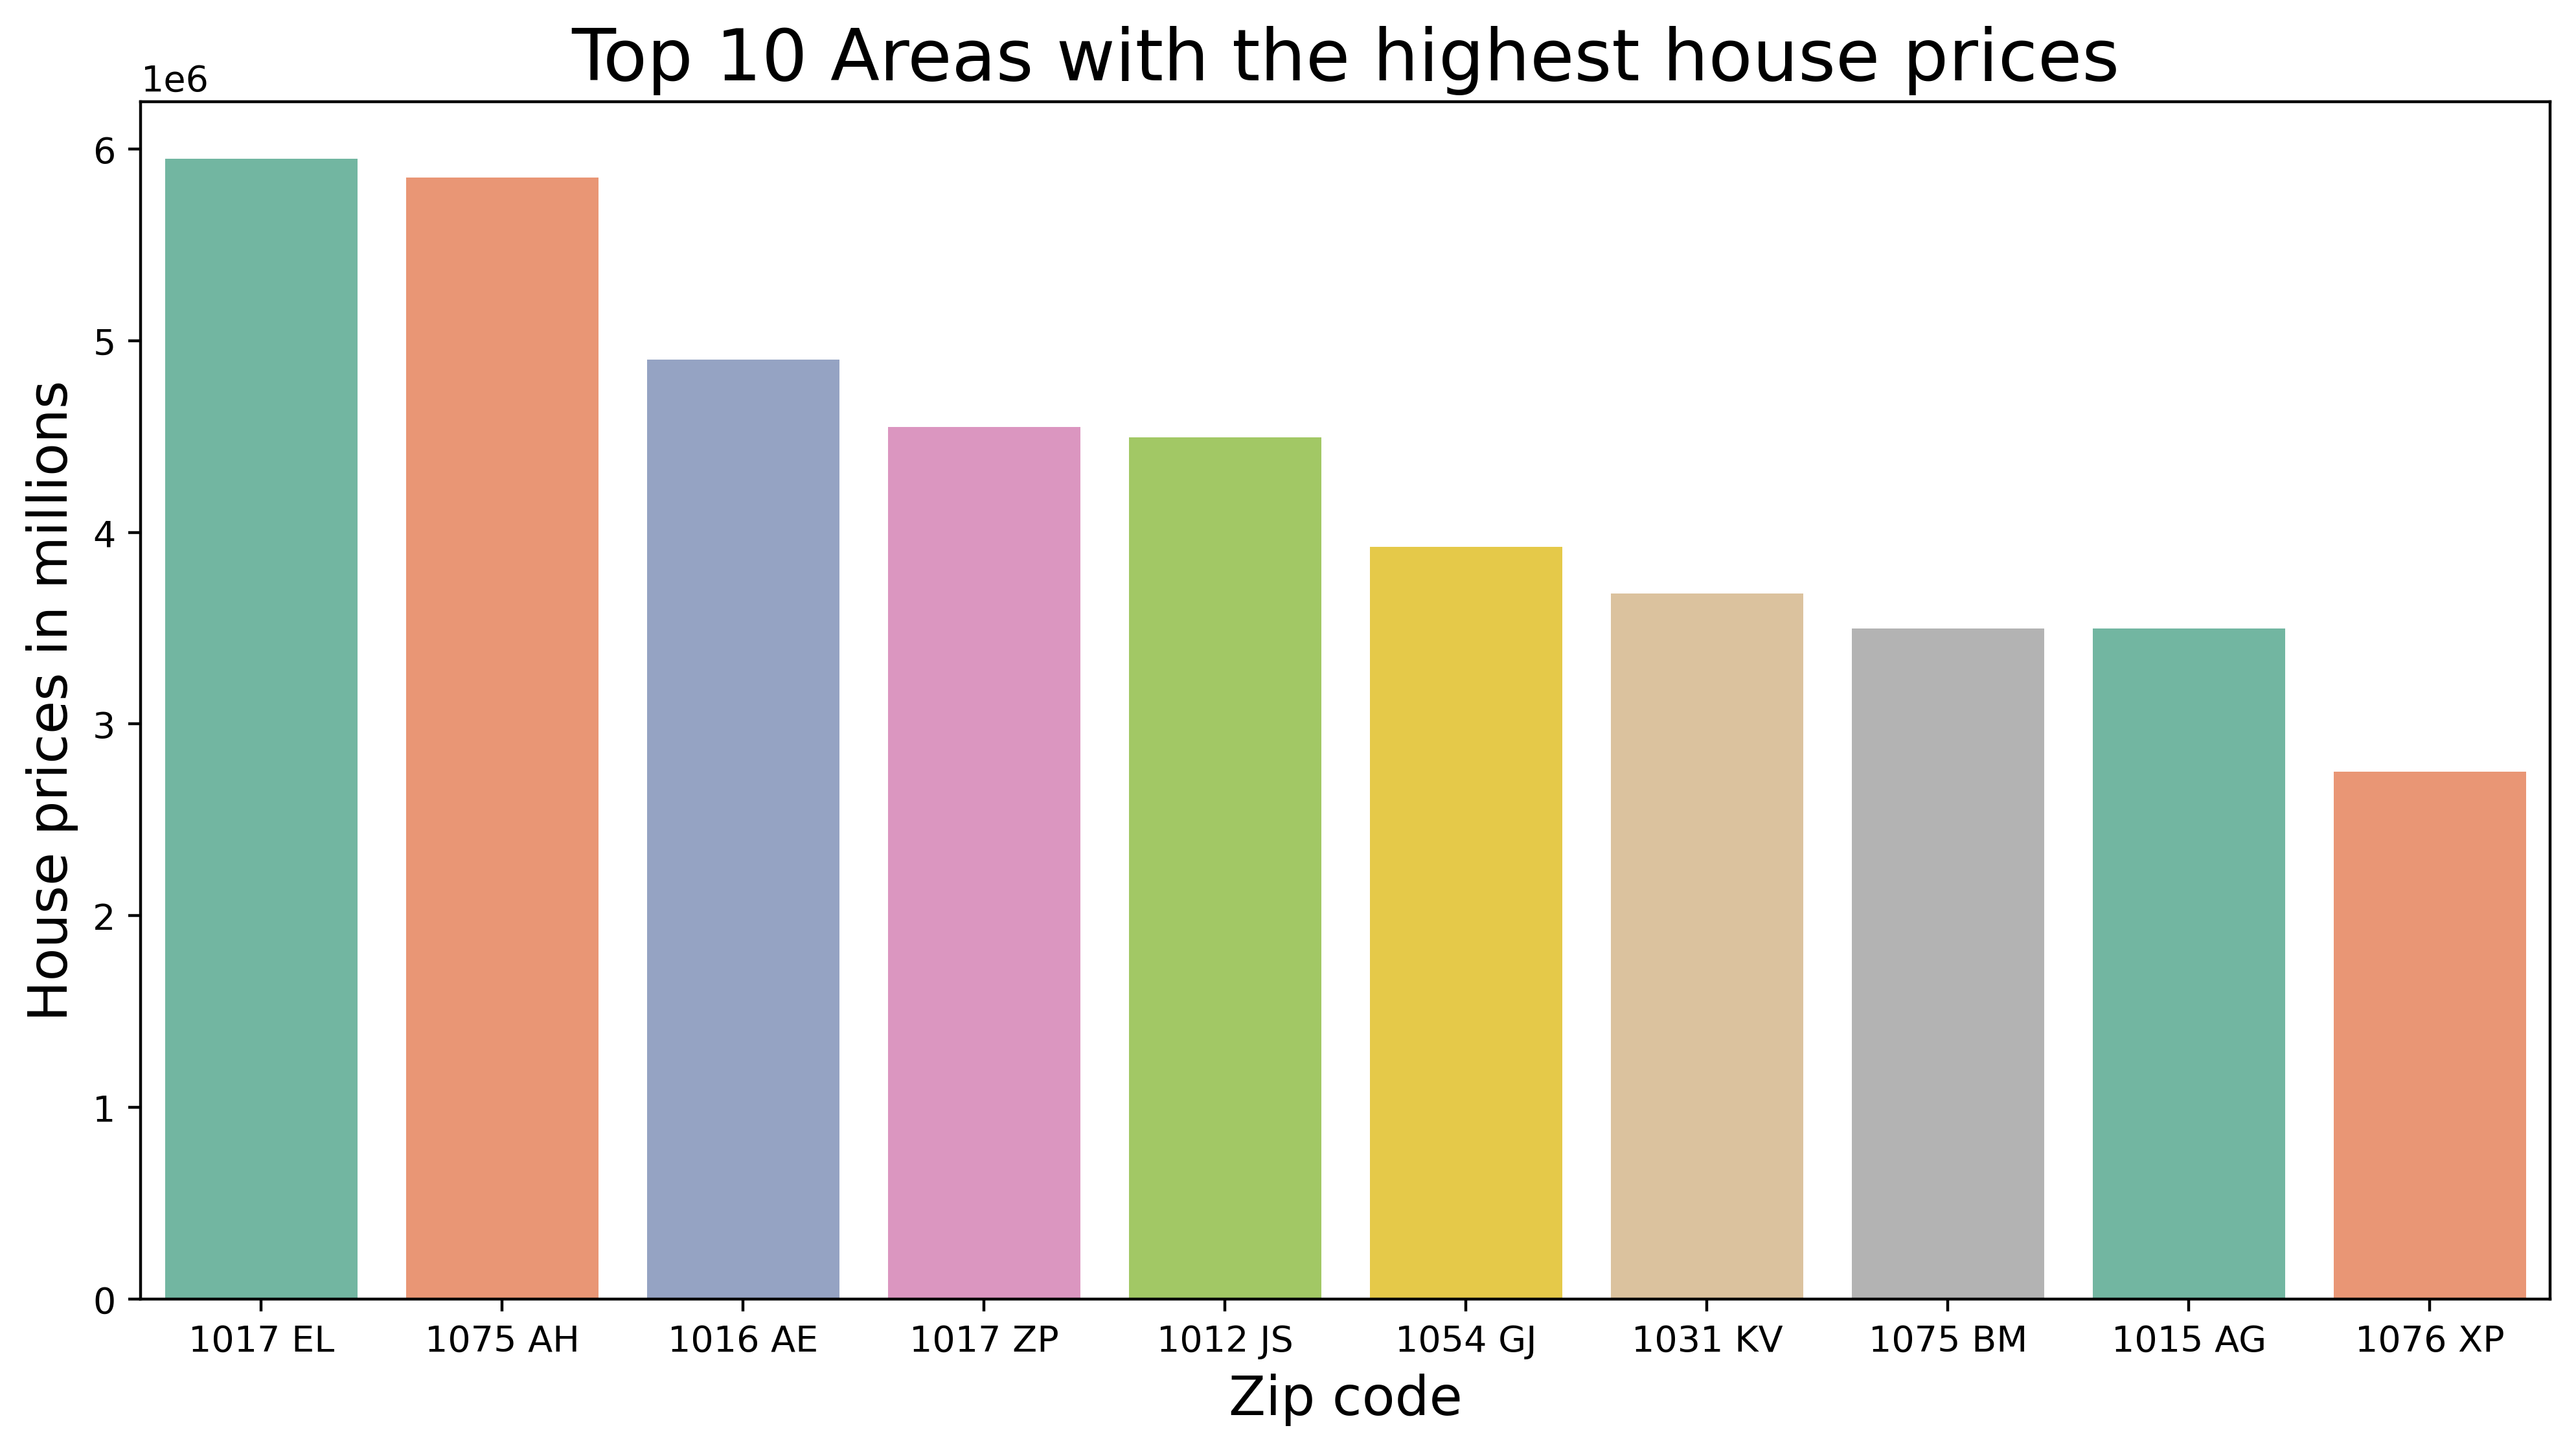

In [80]:
# case 2: advanced 1
plt.figure(figsize=(12,6))
data = houseprices_sorted[0:10]
ax = sns.barplot(data=data, x='Zip', y='Price', palette="Set2")
ax.set_xlabel('Zip code', fontsize=15)
ax.set_ylabel('House prices in millions', fontsize=15)
ax.set_title('Top 10 Areas with the highest house prices', fontsize=20)

In [83]:
# case 3: multiple perspectives at once
fig, ax = plt.subplots(1, 2, figsize=(40,18))
data = houseprices_sorted[0:10]
sns.set(font_scale=2.5)   # chỉnh font chung

ax1 = sns.barplot(data=data, x='Zip', y='Price', ax=ax[0], palette="Set2")
ax1.set_xlabel('Zip code', fontsize=20)
ax1.set_ylabel('House prices in millions', fontsize=20)
ax1.set_title('Top 10 Areas with the highest house prices', fontsize=24)
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=14)  # giảm cỡ chữ nhãn X
ax1.tick_params(axis='y', labelsize=14)  # giảm cỡ chữ nhãn Y

ax2 = sns.barplot(data=data, x='Zip', y='PriceperSqm', ax=ax[1], palette="Set2")
ax2.set_xlabel('Zip code', fontsize=20)
ax2.set_ylabel('House prices per sqm', fontsize=20)
ax2.set_title('Top 10 Areas with the highest price per sqm', fontsize=24)
ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=14)  # giảm cỡ chữ nhãn X
ax2.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

### Bài tập thực hành 1

In [4]:
# Import thư viện
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv("Data/winequality-red.csv")

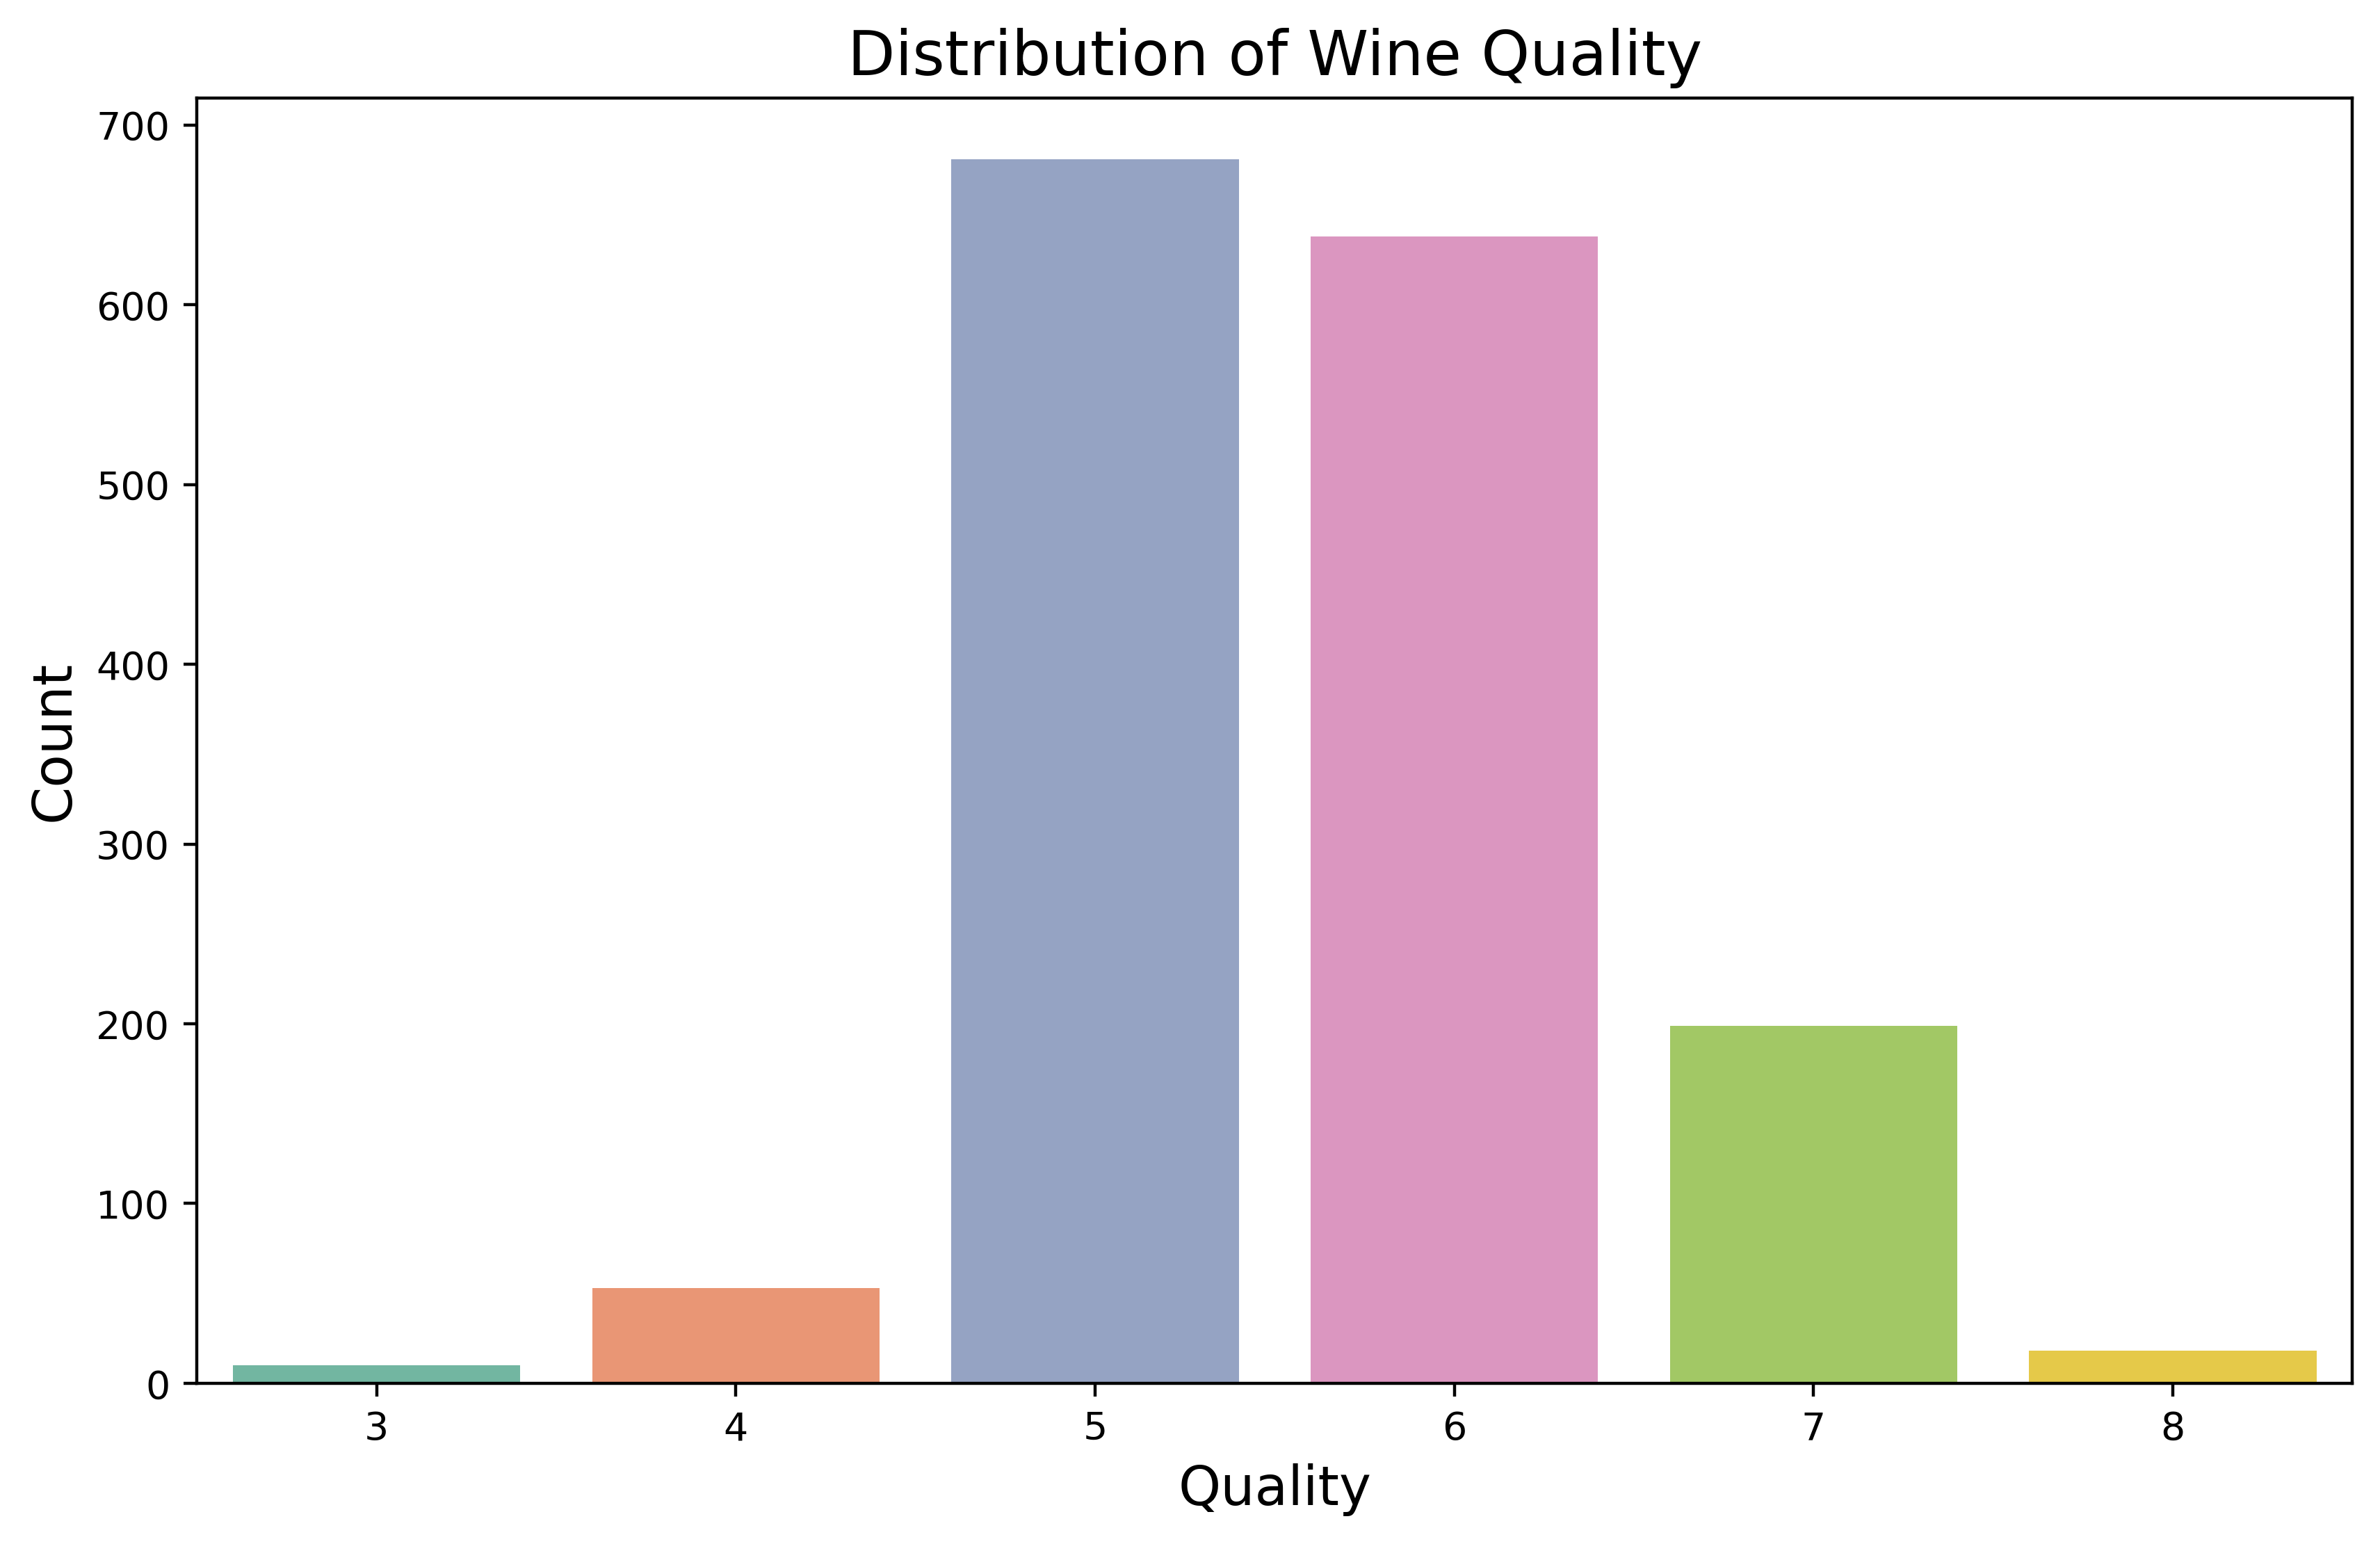

In [9]:
# Biểu đồ cột: phân phối số lượng rượu theo quality
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="quality", palette="Set2")
plt.xlabel("Quality", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution of Wine Quality", fontsize=16)
plt.show()

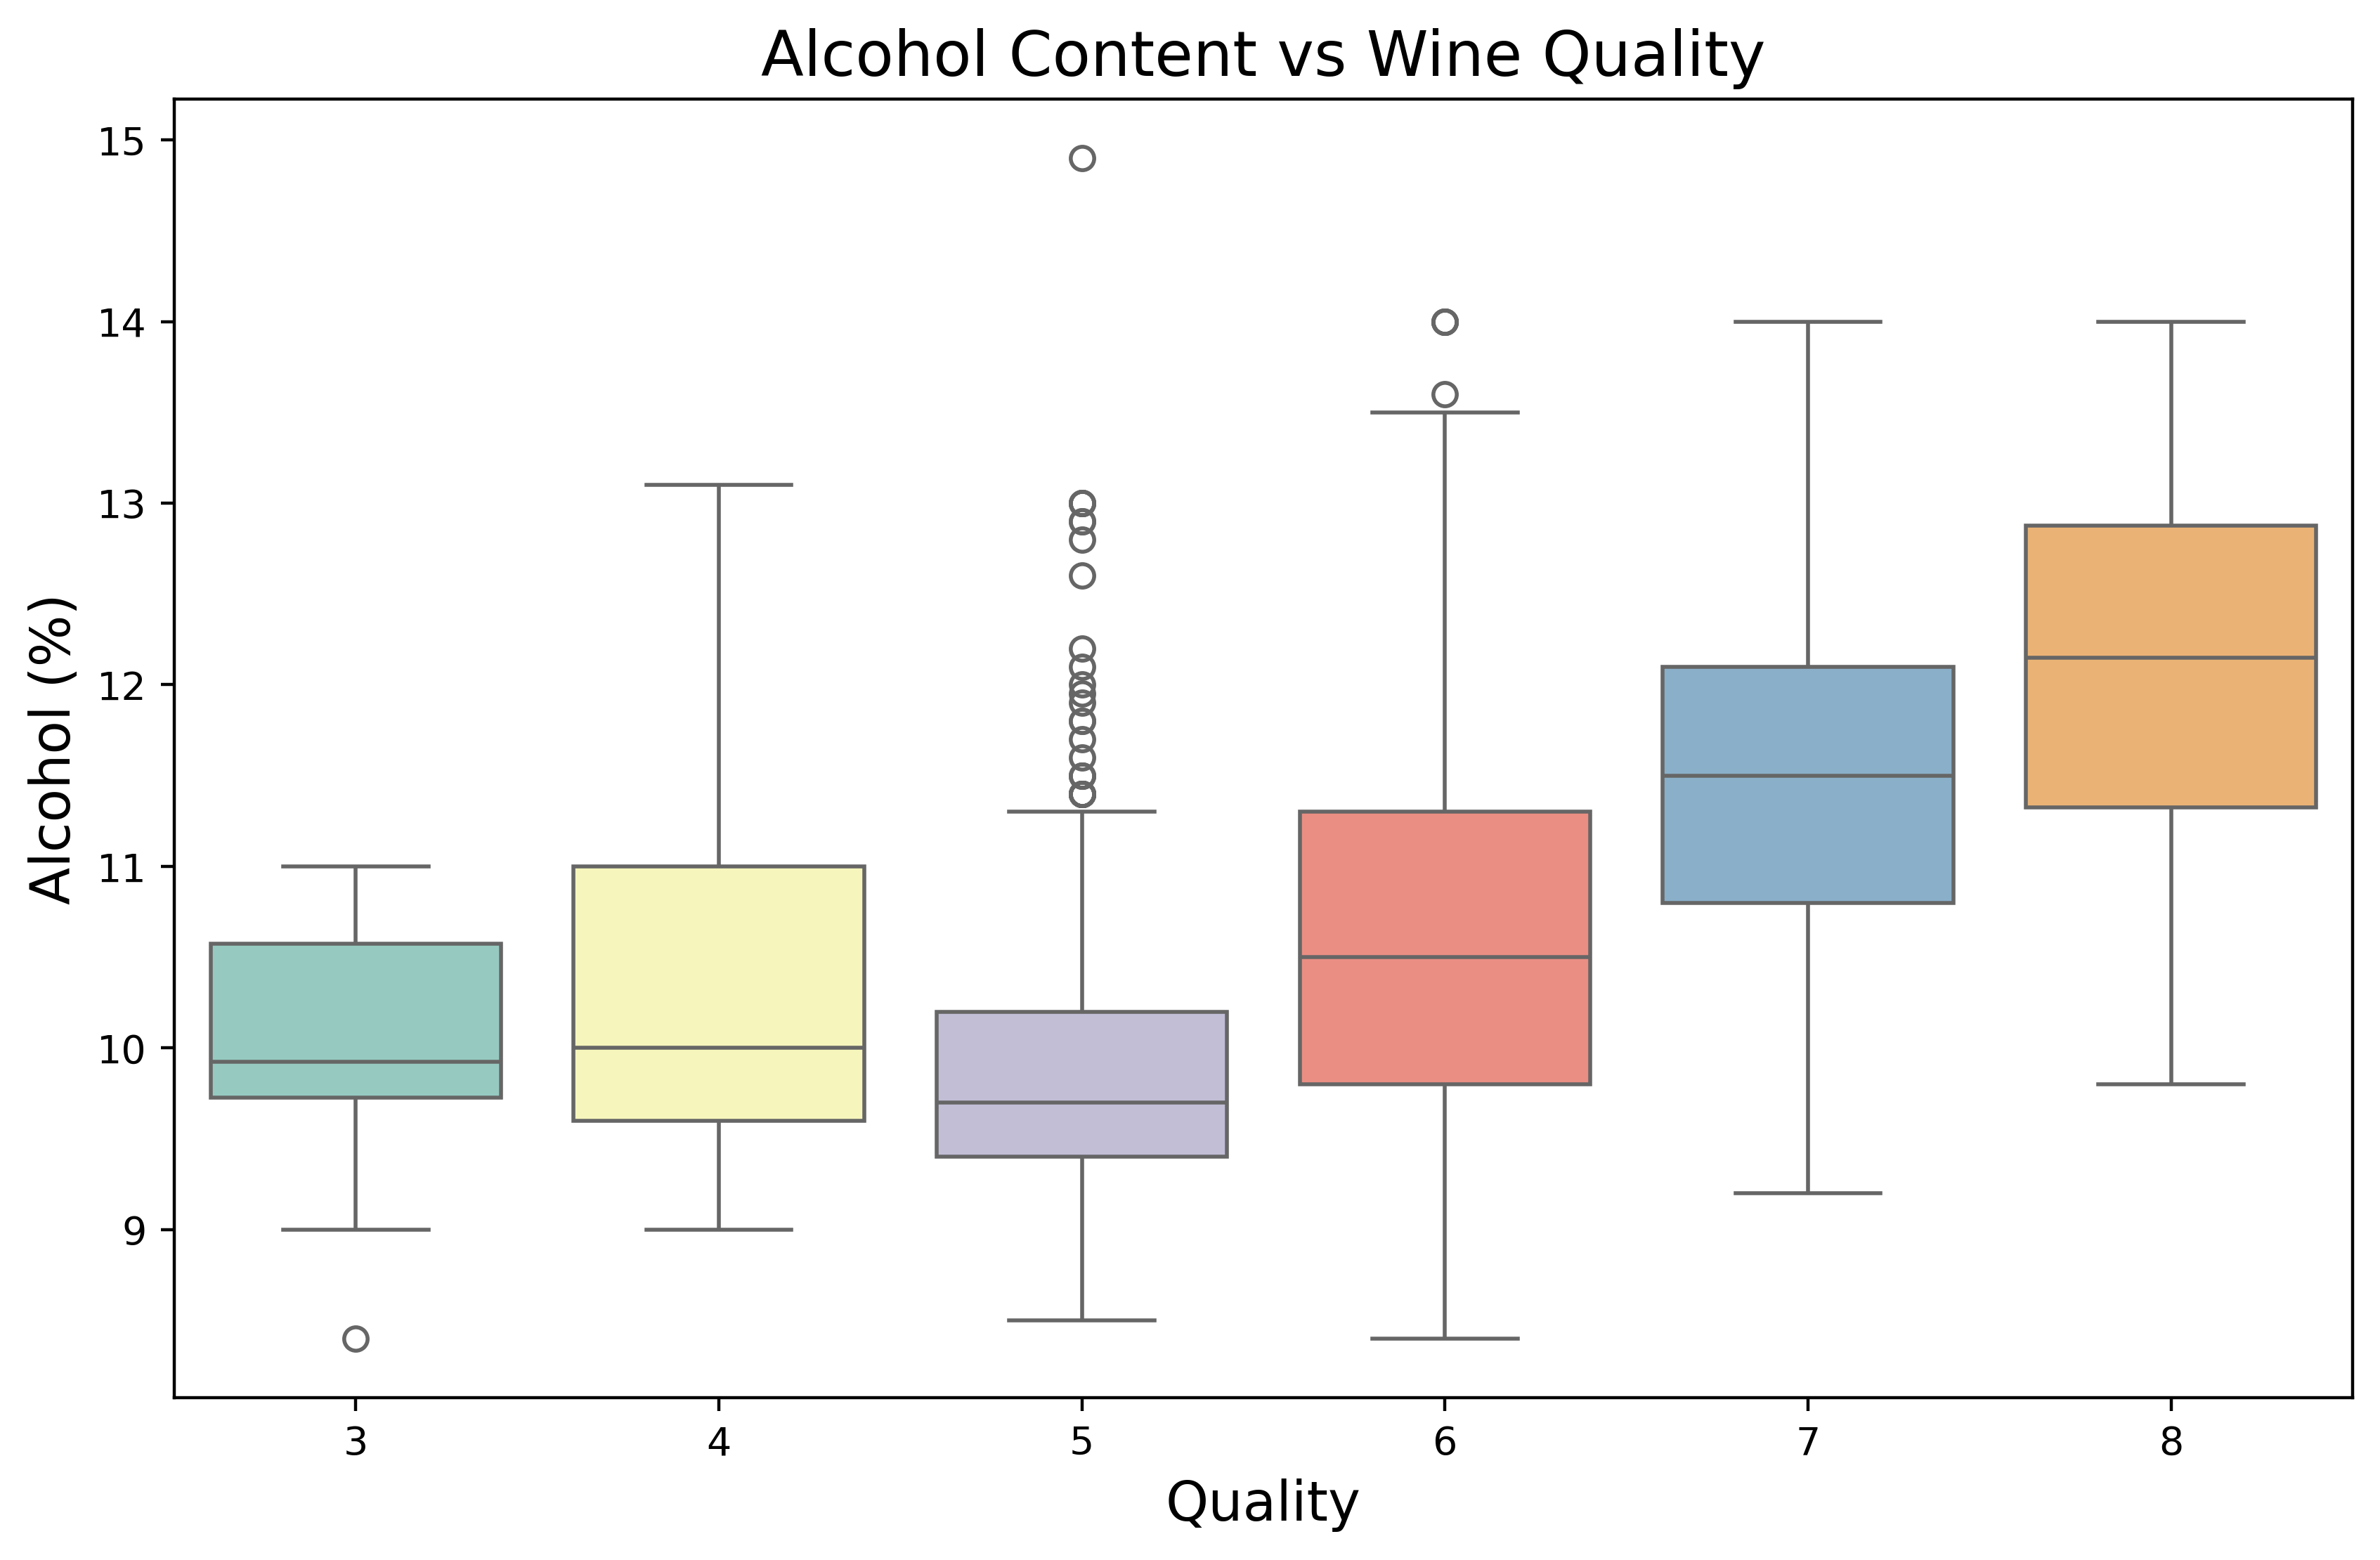

In [6]:
# Boxplot: So sánh nồng độ alcohol theo quality
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="quality", y="alcohol", palette="Set3")
plt.xlabel("Quality", fontsize=14)
plt.ylabel("Alcohol (%)", fontsize=14)
plt.title("Alcohol Content vs Wine Quality", fontsize=16)
plt.show()

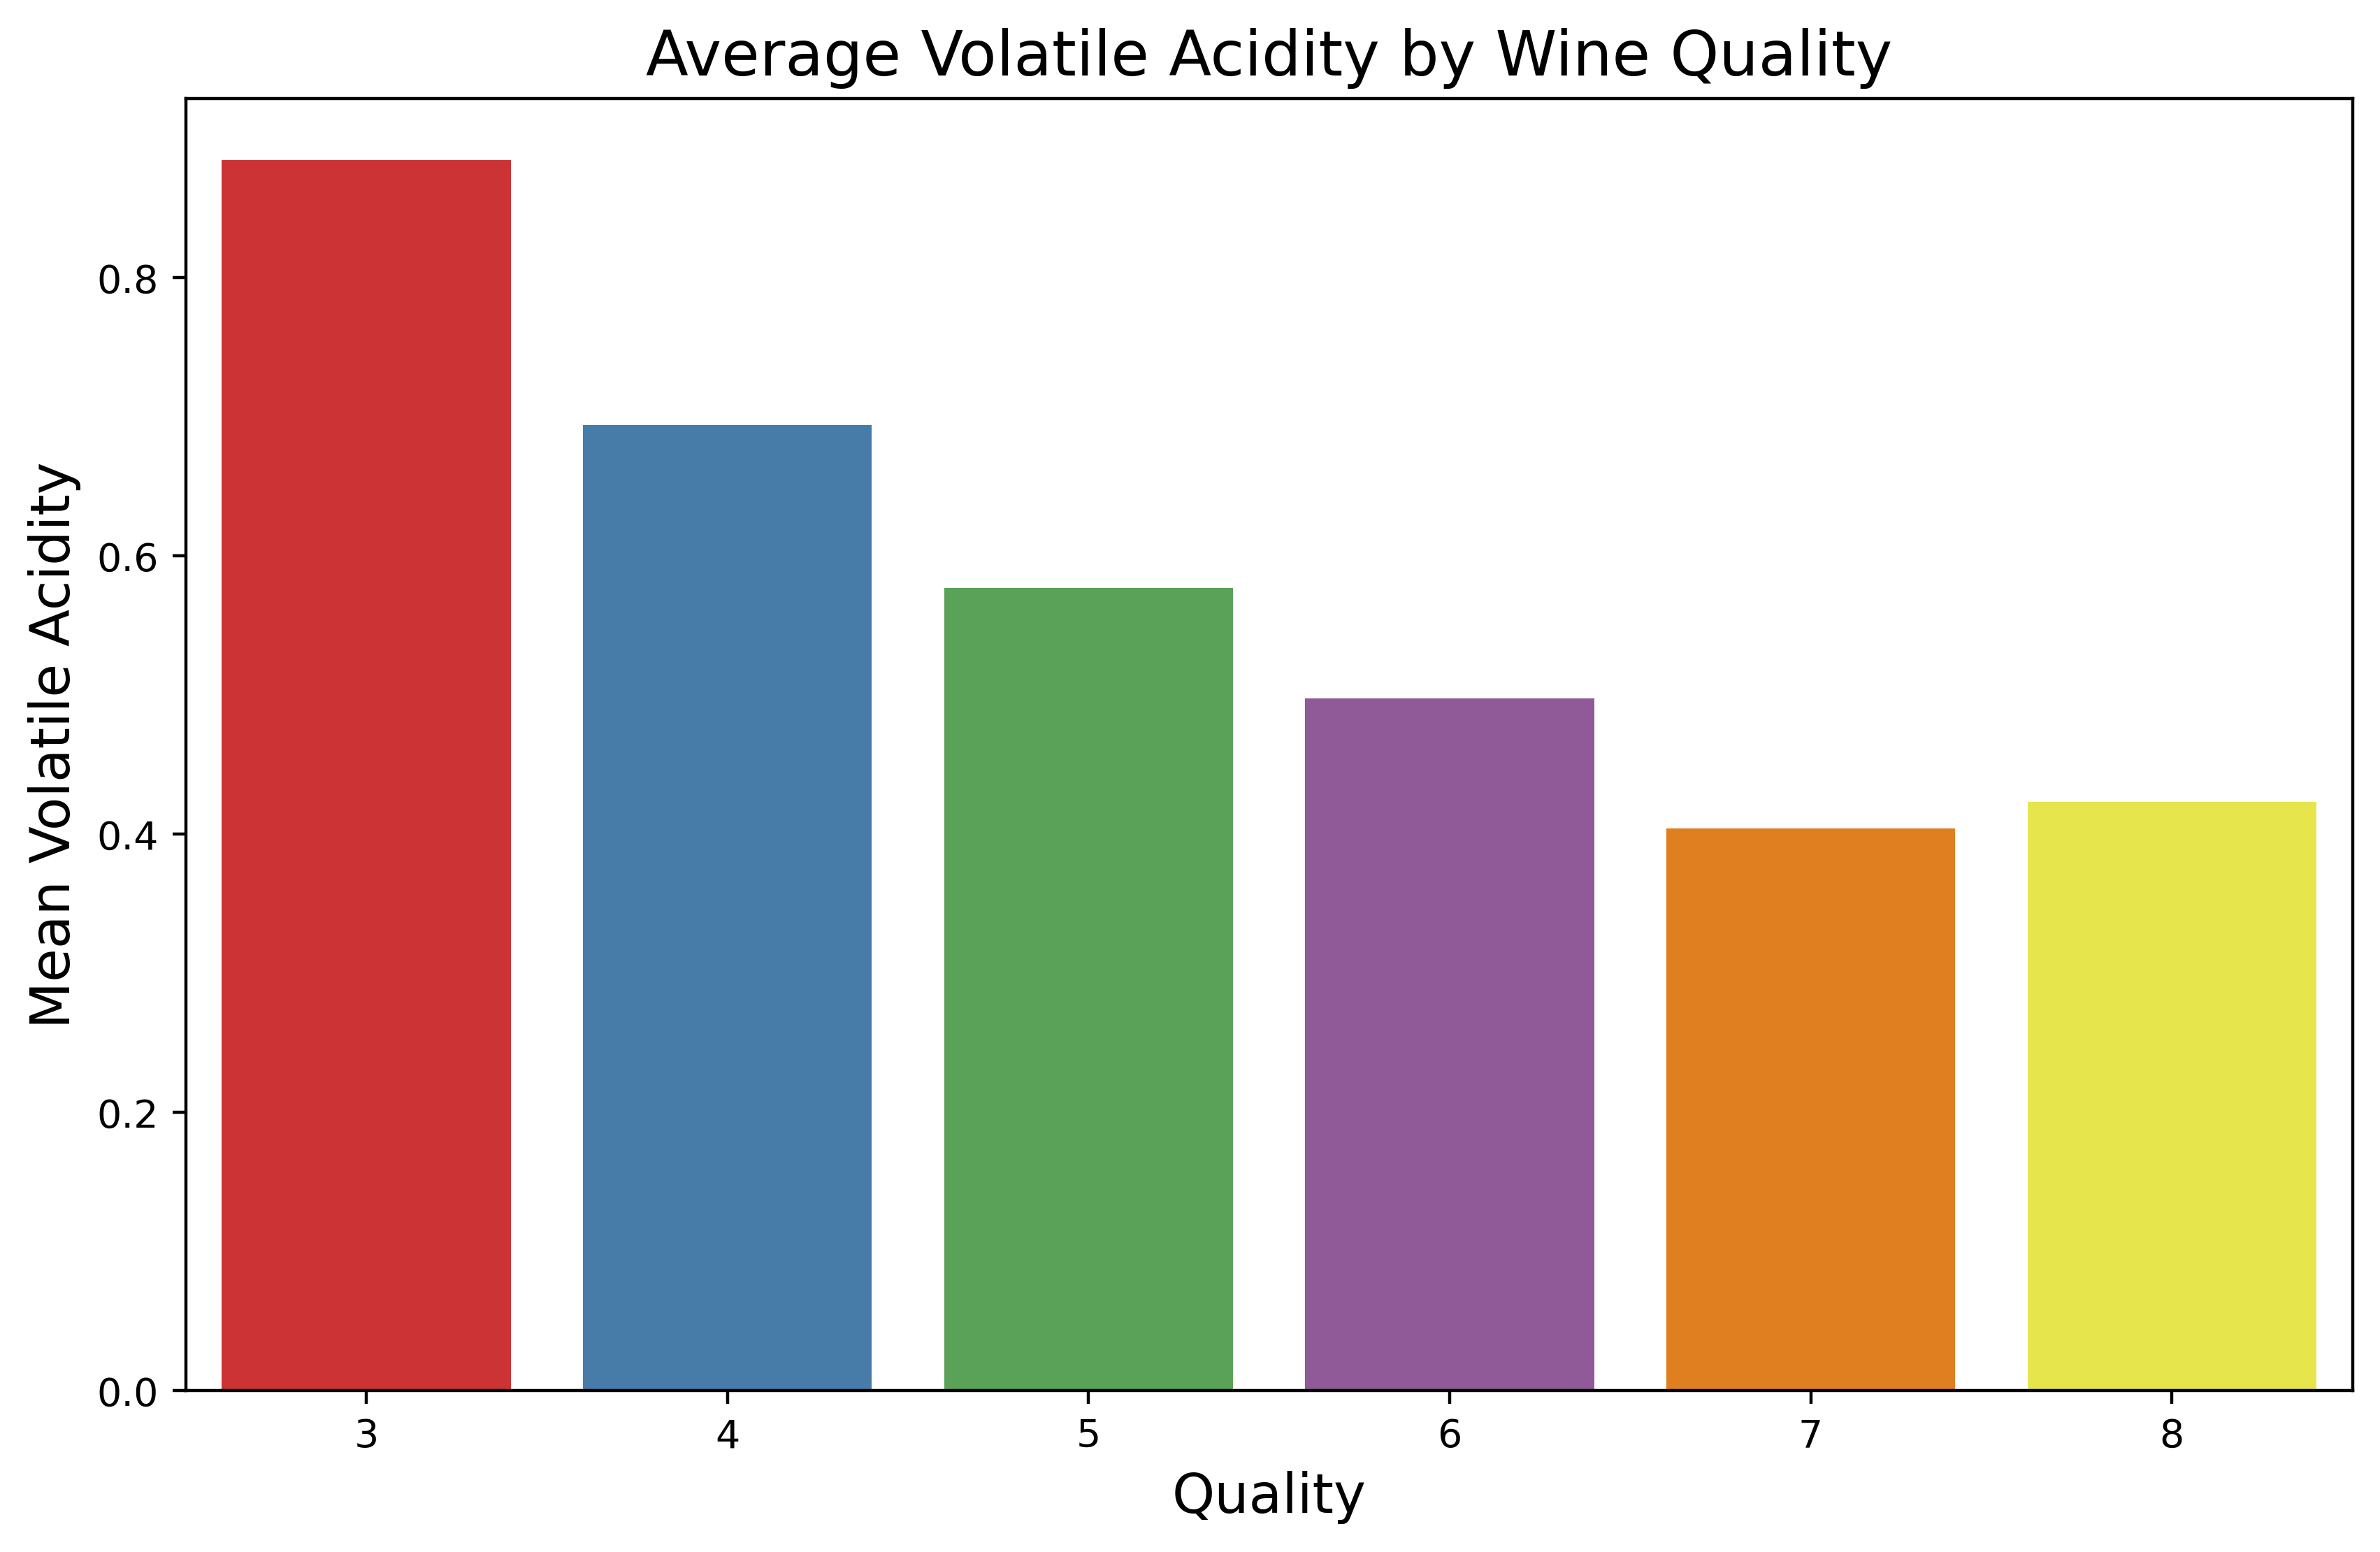

In [7]:
# Barplot: Trung bình volatile acidity theo quality
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="quality", y="volatile acidity", palette="Set1", ci=None)
plt.xlabel("Quality", fontsize=14)
plt.ylabel("Mean Volatile Acidity", fontsize=14)
plt.title("Average Volatile Acidity by Wine Quality", fontsize=16)
plt.show()

### Bài tập thực hành 2

#### Nhiệm vụ 1: Thực hiện trực quan hóa dữ liệu trên tập dữ liệu về bệnh tiểu đường|

In [16]:
# Import dữ liệu
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv("Data/diabetes.csv")

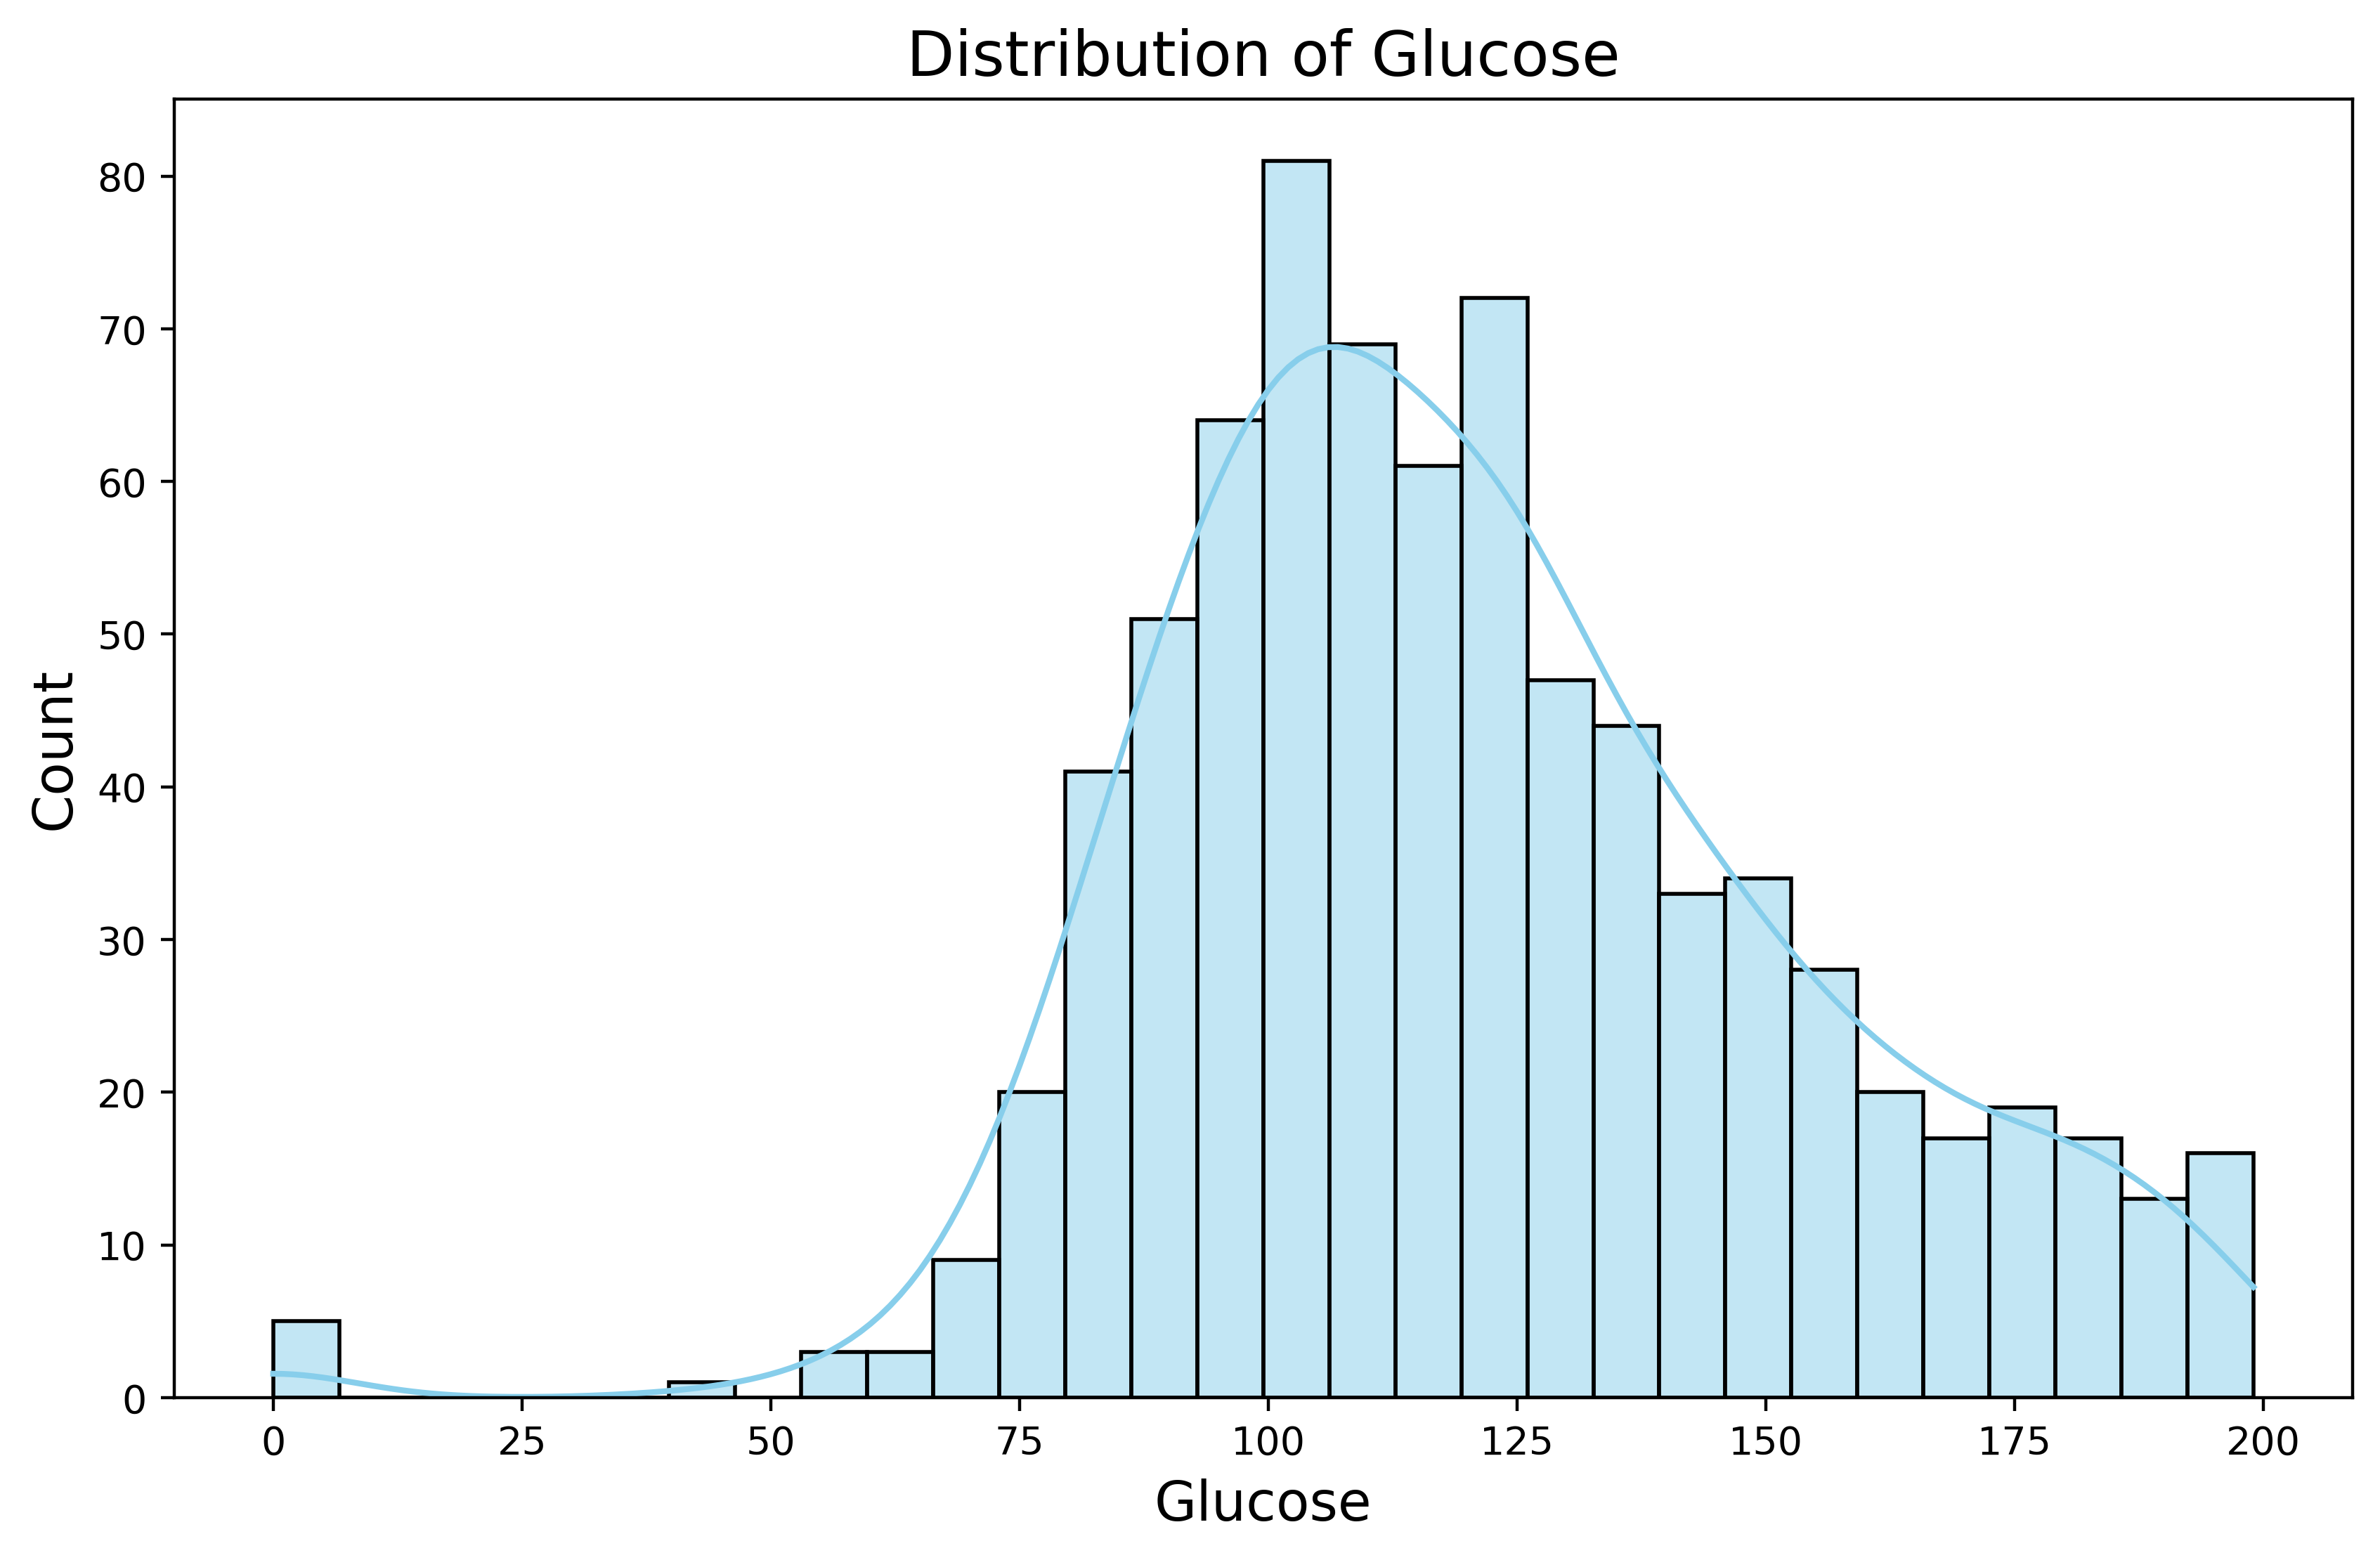

In [11]:
# case 1: Basic - phân phối Glucose
plt.figure(figsize=(10,6))
sns.histplot(df['Glucose'], bins=30, kde=True, color='skyblue')
plt.xlabel("Glucose", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution of Glucose", fontsize=16)
plt.show()

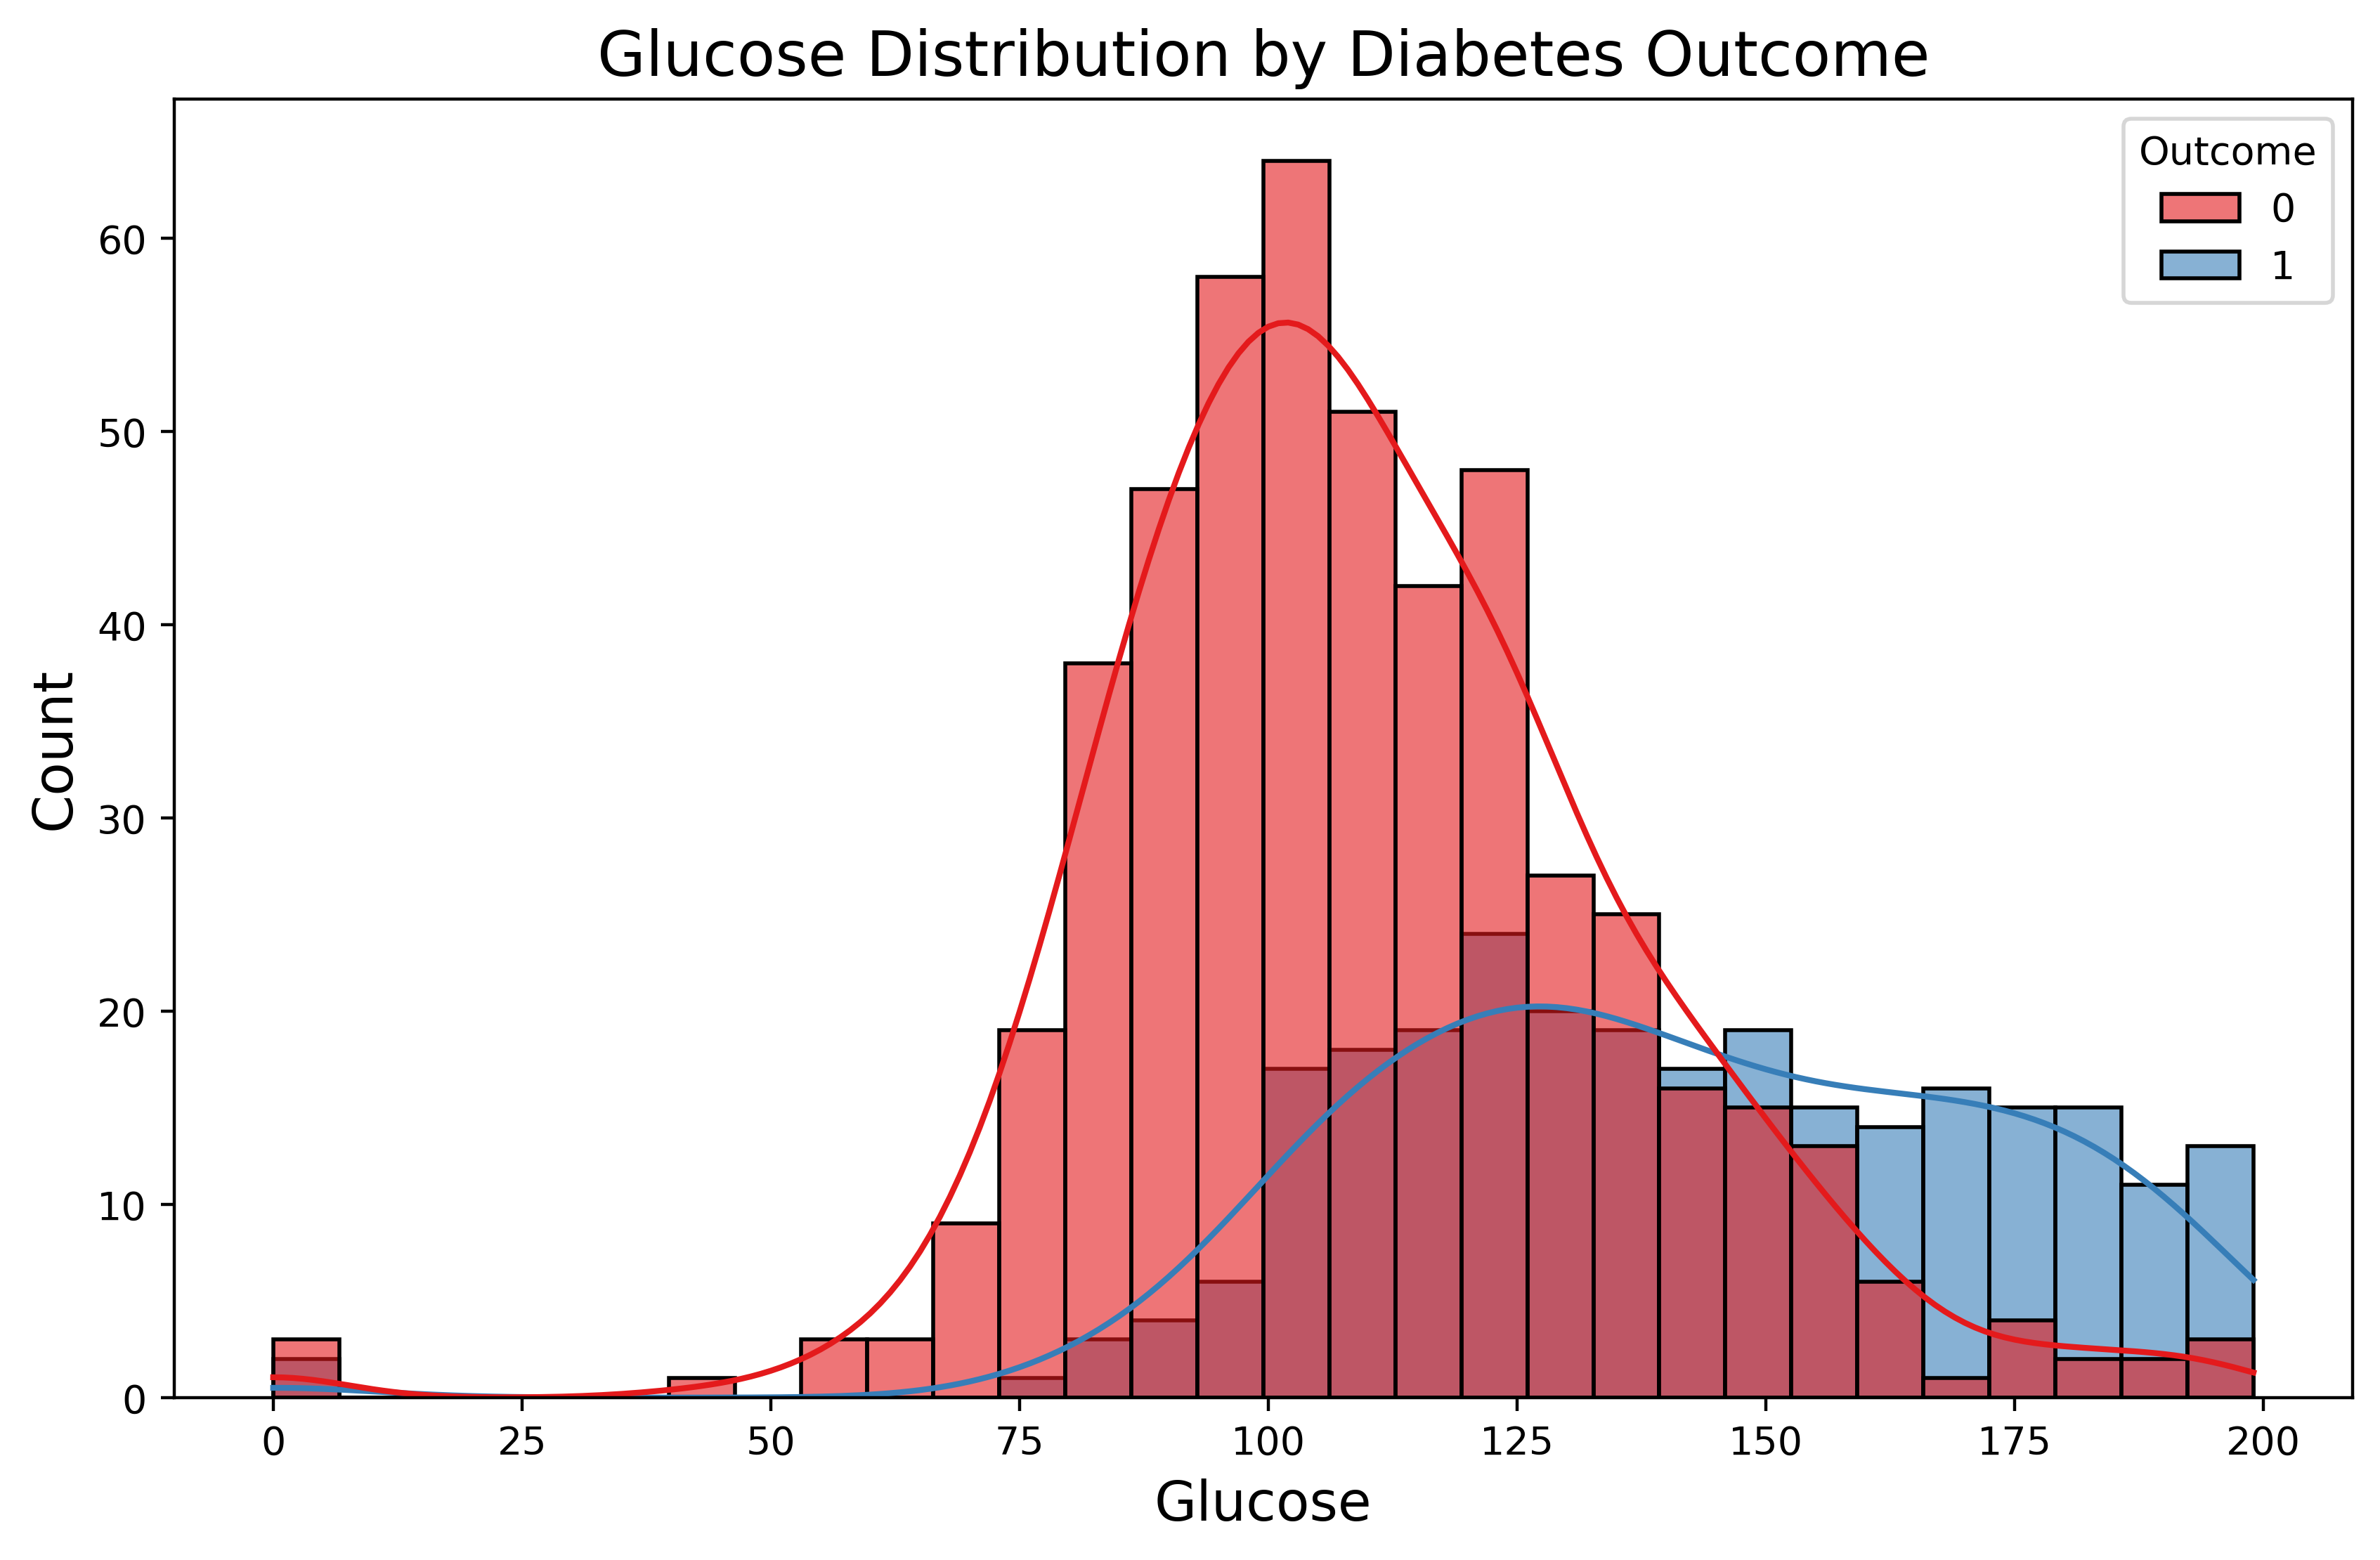

In [12]:
# case 2: Advanced - phân phối Glucose theo Outcome
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Glucose", bins=30, kde=True, hue="Outcome", palette="Set1", alpha=0.6)
plt.xlabel("Glucose", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Glucose Distribution by Diabetes Outcome", fontsize=16)
plt.show()

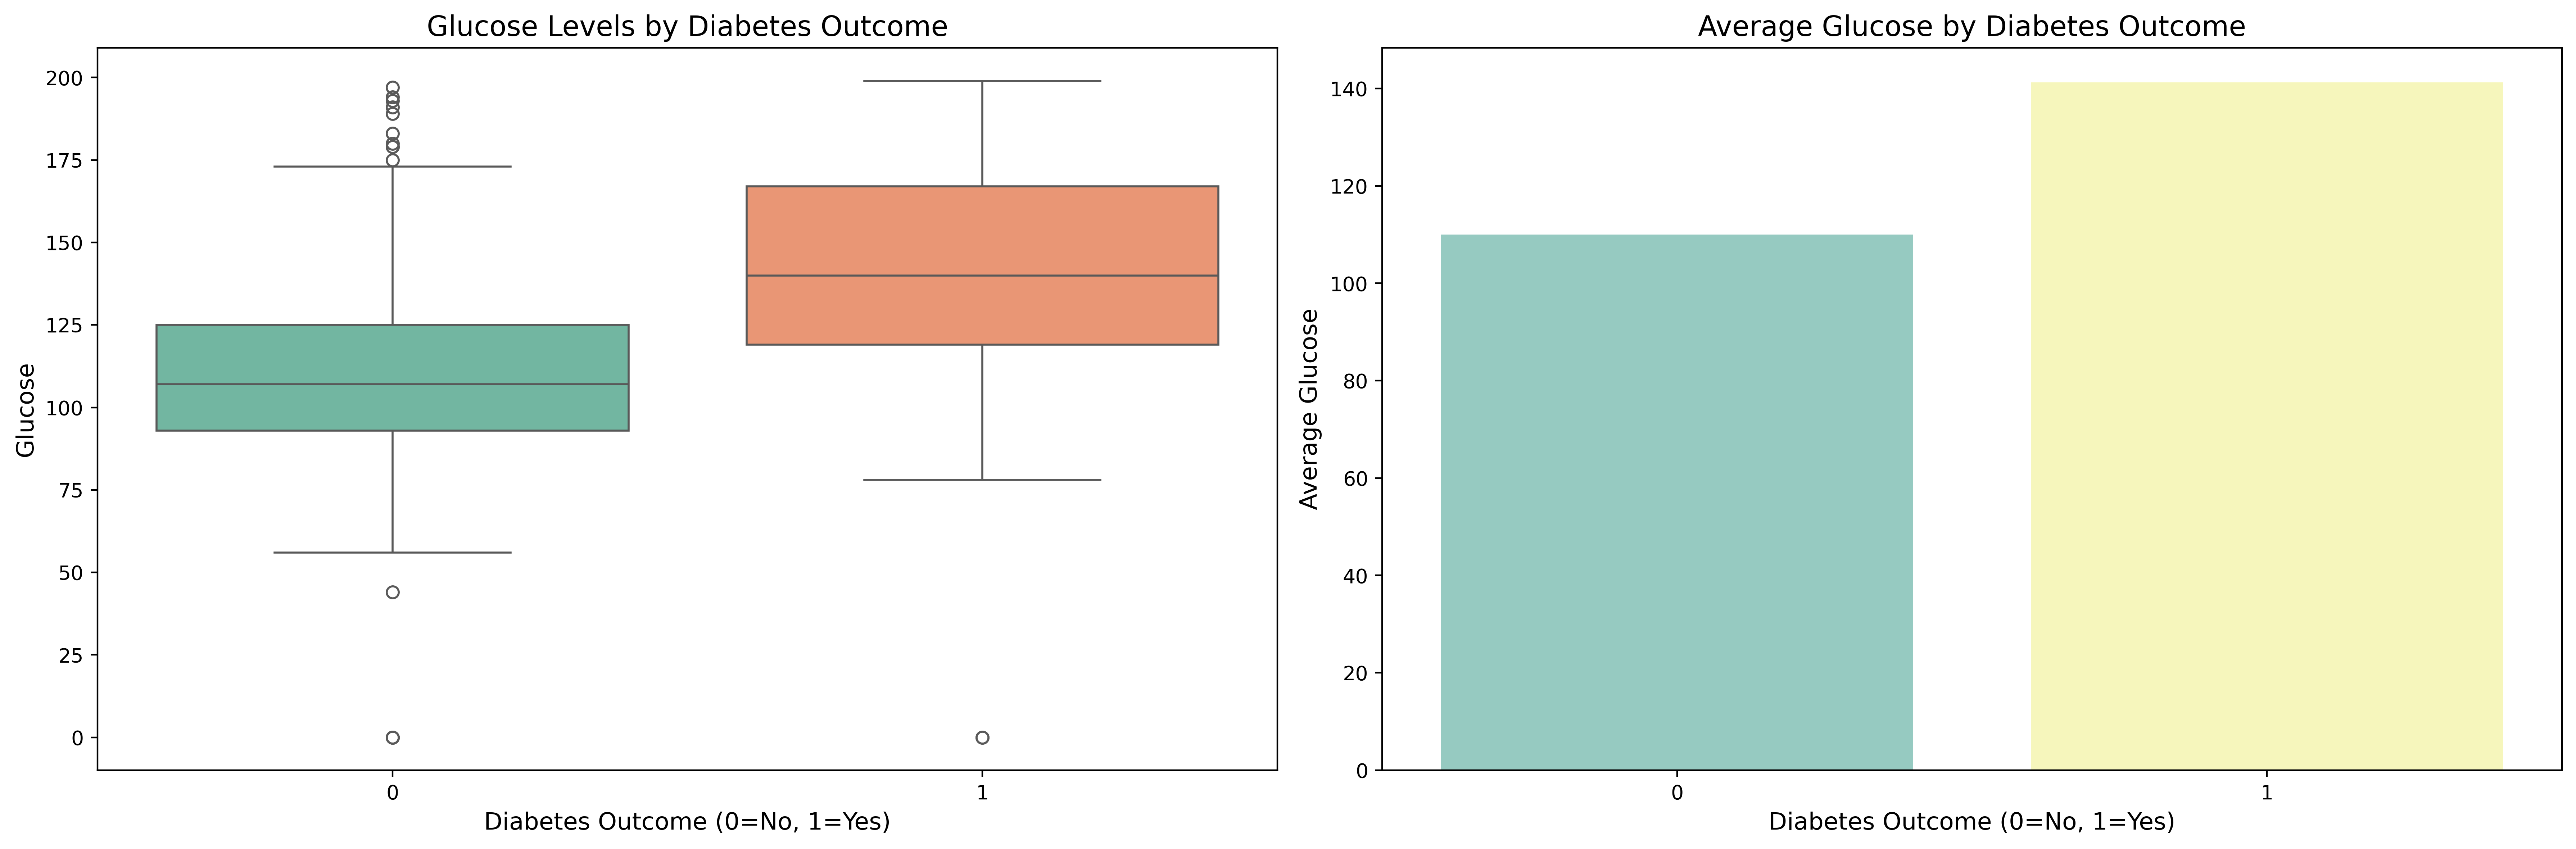

In [18]:
# case 3: Multiple perspectives at once
fig, ax = plt.subplots(1, 2, figsize=(18,6))

# Boxplot: Glucose vs Outcome
sns.boxplot(data=df, x="Outcome", y="Glucose", palette="Set2", ax=ax[0])
ax[0].set_xlabel("Diabetes Outcome (0=No, 1=Yes)", fontsize=12)
ax[0].set_ylabel("Glucose", fontsize=12)
ax[0].set_title("Glucose Levels by Diabetes Outcome", fontsize=14)

# Barplot: Trung bình Glucose theo Outcome
sns.barplot(data=df, x="Outcome", y="Glucose", palette="Set3", ci=None, ax=ax[1])
ax[1].set_xlabel("Diabetes Outcome (0=No, 1=Yes)", fontsize=12)
ax[1].set_ylabel("Average Glucose", fontsize=12)
ax[1].set_title("Average Glucose by Diabetes Outcome", fontsize=14)

plt.tight_layout()
plt.show()

#### Nhiệm vụ 2: Thực hiện EDA trên tập dữ liệu mua sắm tại siêu thị

In [1]:
# Import thư viện
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_excel("Data/Online Retail.xlsx")

# Tạo thêm cột Doanh thu = Quantity * UnitPrice
df['Revenue'] = df['Quantity'] * df['UnitPrice']

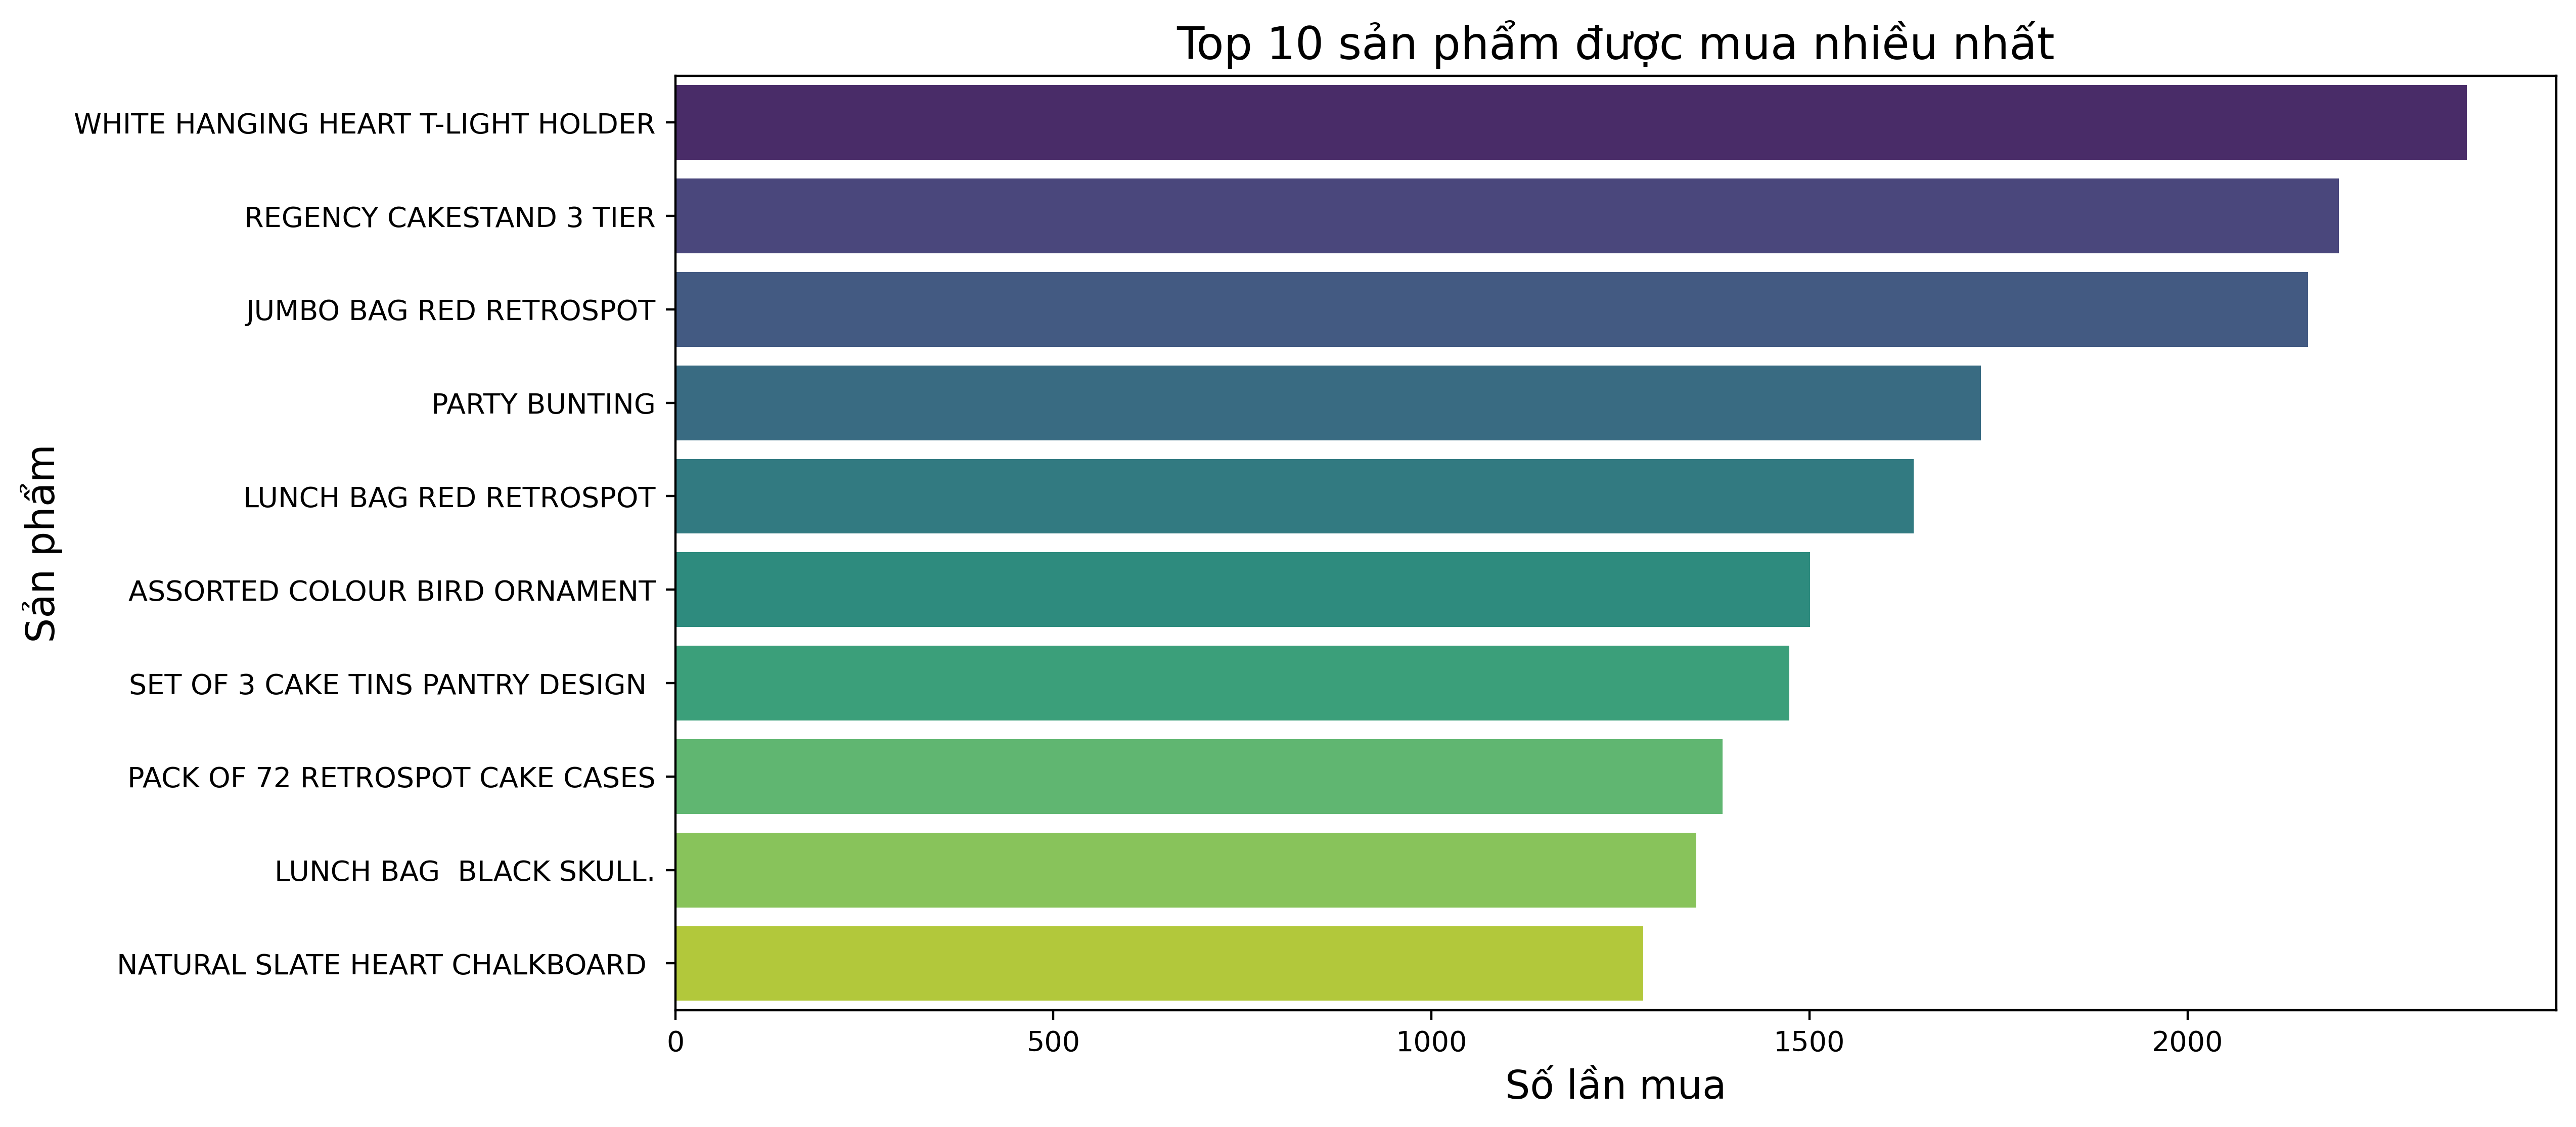

In [6]:
# case 1: Basic - Top 10 sản phẩm được mua nhiều nhất
plt.figure(figsize=(12,6))
top_products = df['Description'].value_counts().head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.xlabel("Số lần mua", fontsize=14)
plt.ylabel("Sản phẩm", fontsize=14)
plt.title("Top 10 sản phẩm được mua nhiều nhất", fontsize=16)
plt.show()

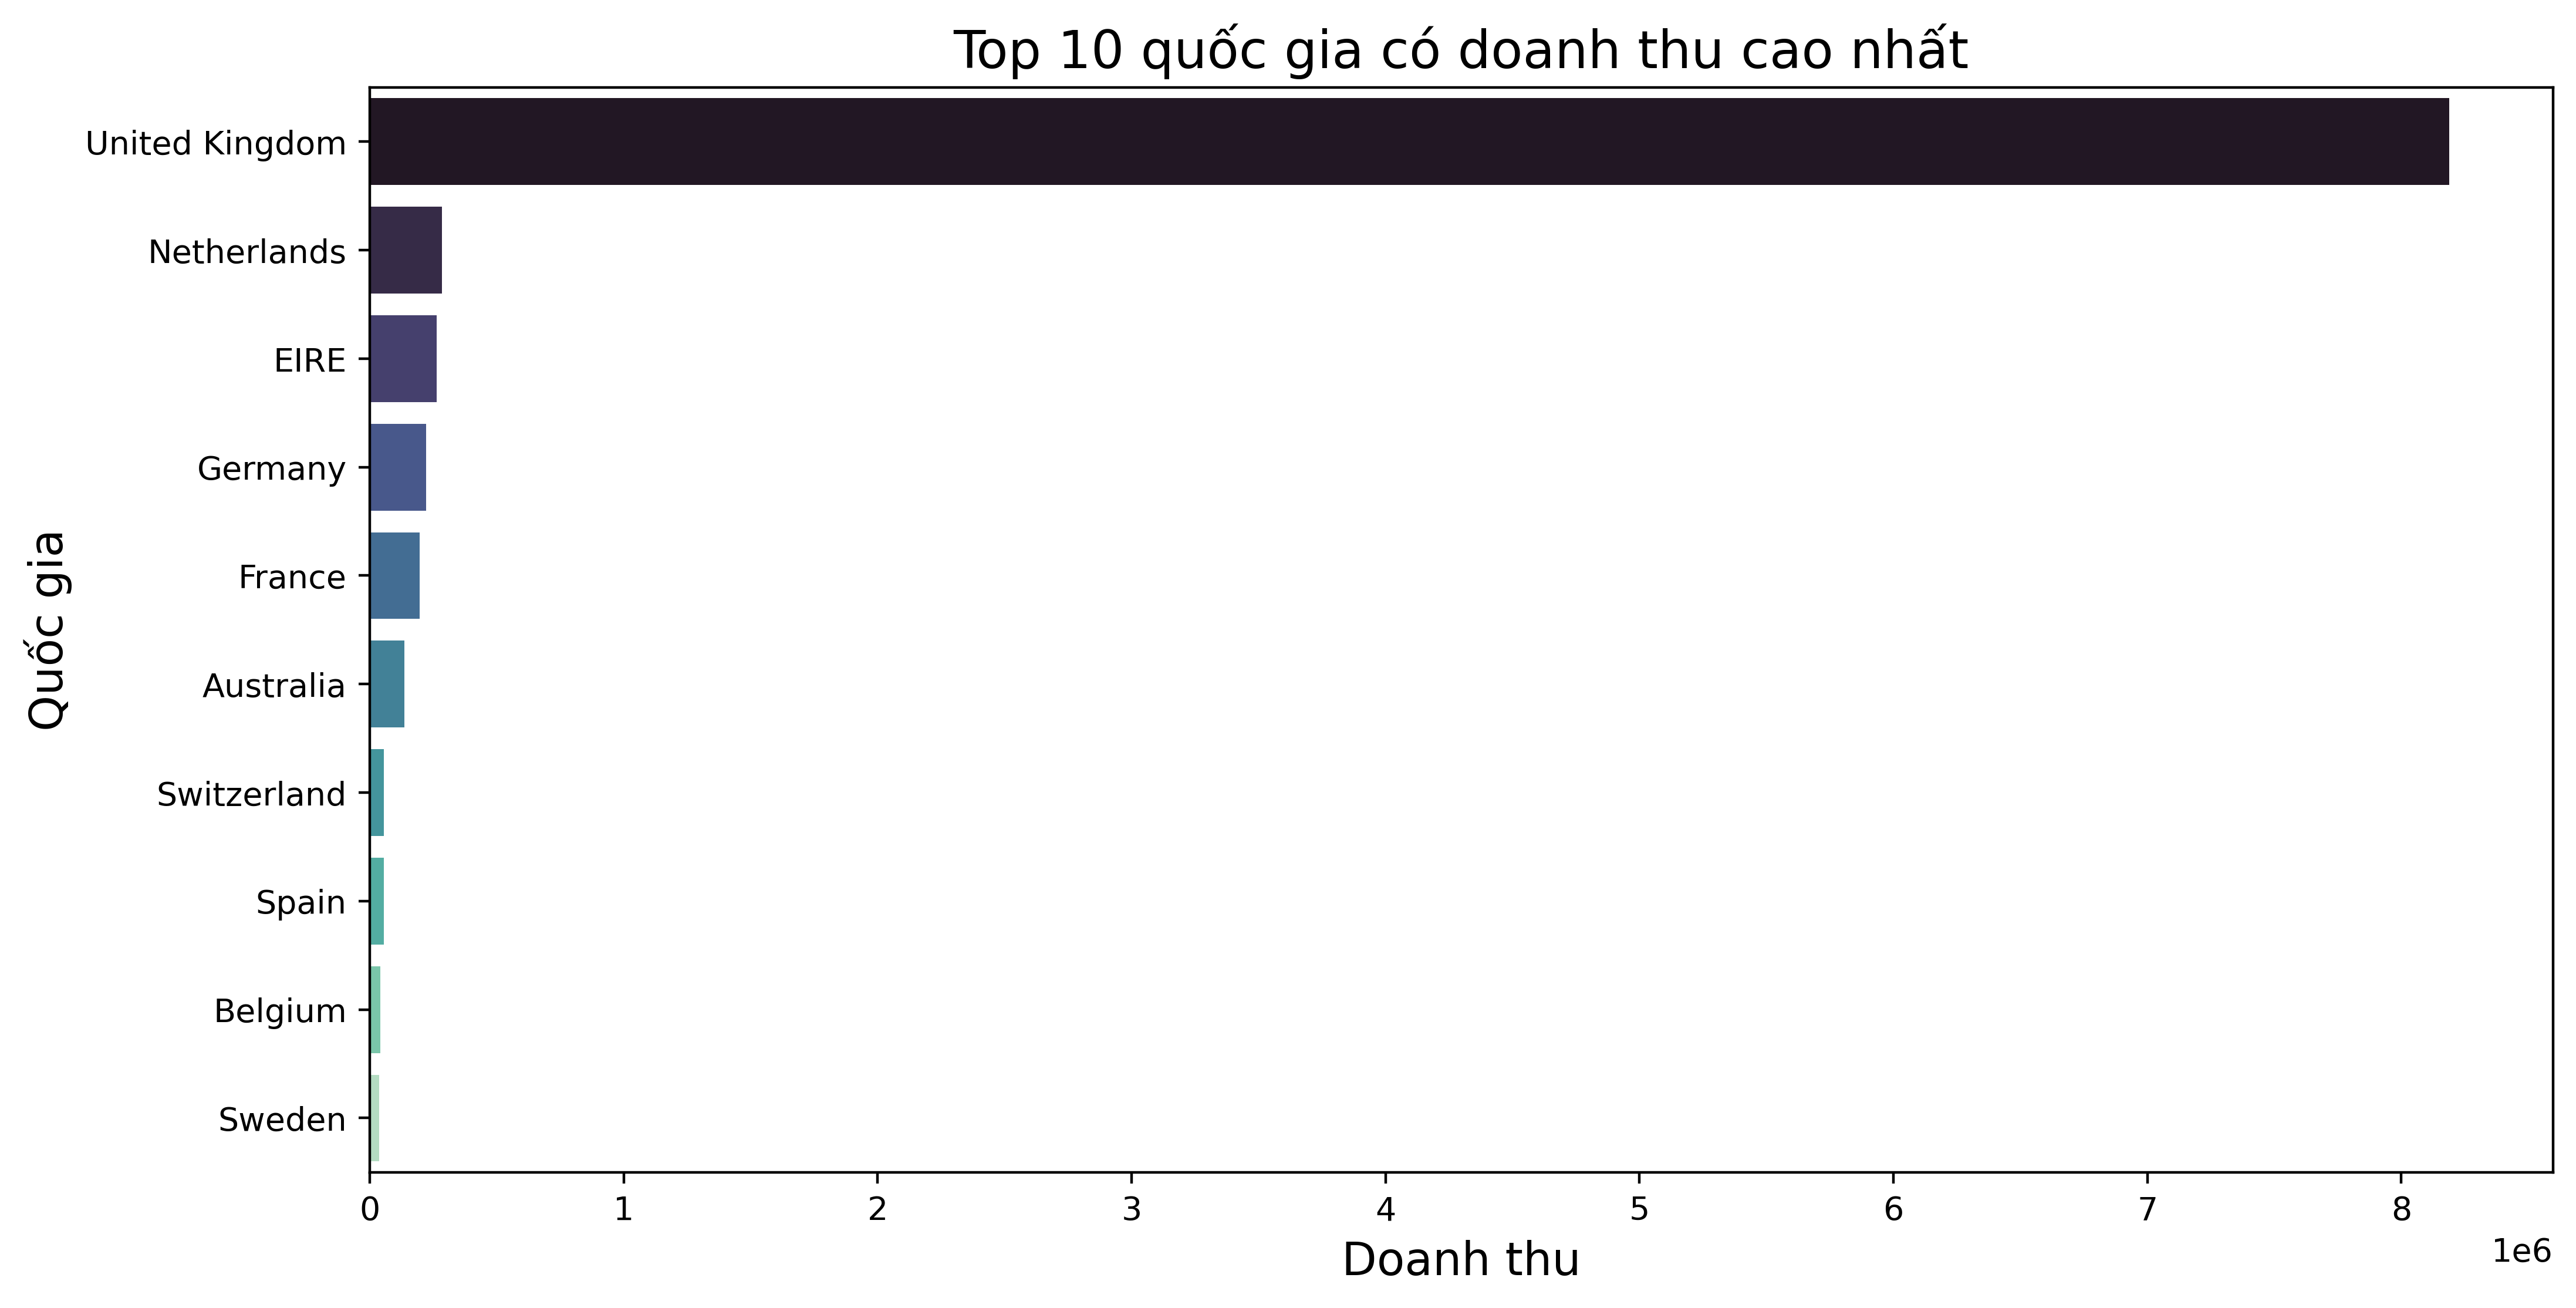

In [7]:
# case 2: Advanced - Doanh thu theo quốc gia (Top 10)
plt.figure(figsize=(12,6))
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="mako")
plt.xlabel("Doanh thu", fontsize=14)
plt.ylabel("Quốc gia", fontsize=14)
plt.title("Top 10 quốc gia có doanh thu cao nhất", fontsize=16)
plt.show()

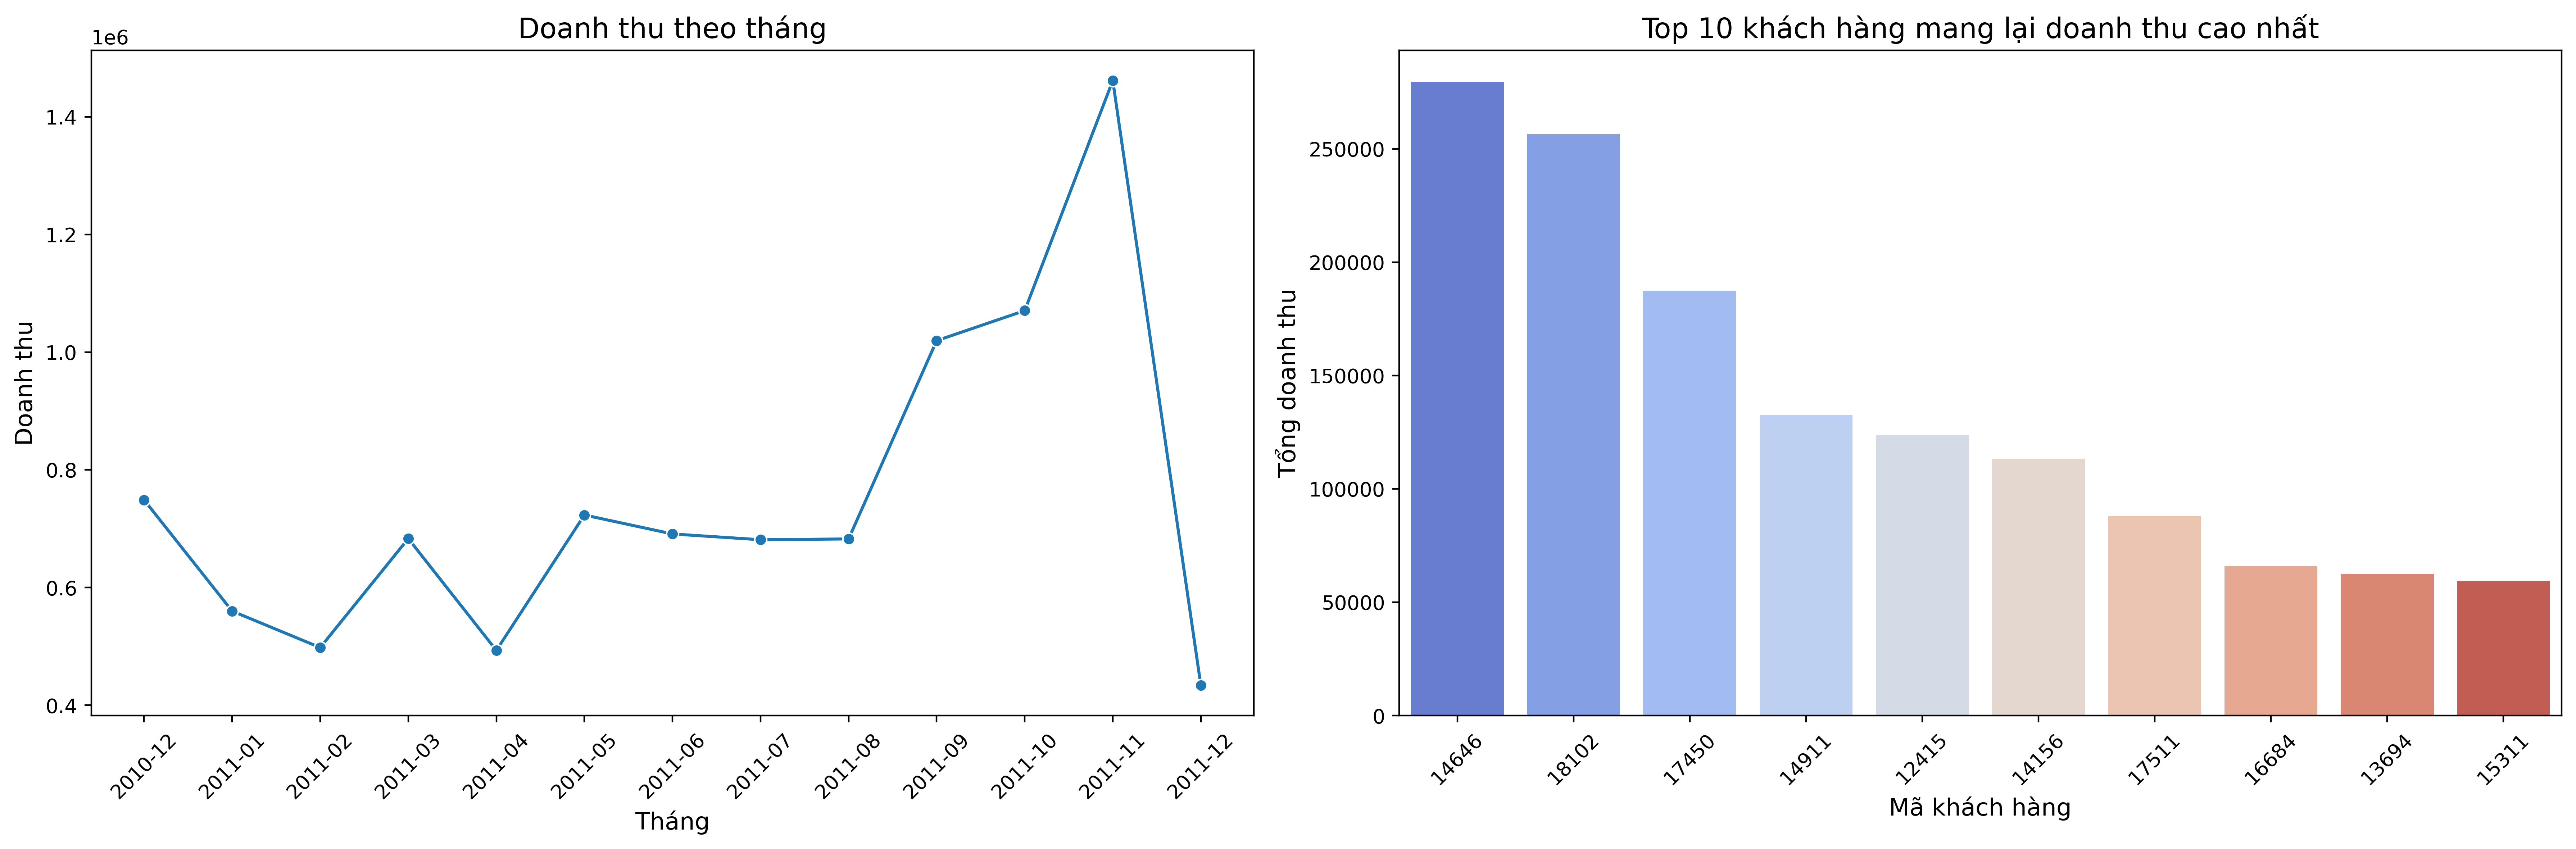

In [9]:
# case 3: Multiple perspectives at once
fig, ax = plt.subplots(1, 2, figsize=(18,6))

# Doanh thu theo tháng
df['Month'] = pd.to_datetime(df['InvoiceDate']).dt.to_period("M")
monthly_revenue = df.groupby('Month')['Revenue'].sum()

sns.lineplot(x=monthly_revenue.index.astype(str), y=monthly_revenue.values, marker="o", ax=ax[0])
ax[0].set_xlabel("Tháng", fontsize=12)
ax[0].set_ylabel("Doanh thu", fontsize=12)
ax[0].set_title("Doanh thu theo tháng", fontsize=14)
ax[0].tick_params(axis='x', rotation=45)

# Doanh thu theo khách hàng (Top 10)
top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(x=top_customers.index.astype(int).astype(str), y=top_customers.values, palette="coolwarm", ax=ax[1])

plt.xlabel("Mã khách hàng", fontsize=12)
plt.ylabel("Tổng doanh thu", fontsize=12)
plt.title("Top 10 khách hàng mang lại doanh thu cao nhất", fontsize=14)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 1.3. PHÂN TÍCH ĐƠN BIẾN VÀ HAI BIẾN

### Bài toán 1

#### Nhiệm vụ 1: phân tích dữ liệu đơn biến trên dữ liệu về chim cánh cụt

In [16]:
# Import thư viện và nạp dữ liệu
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

penguins_data = pd.read_csv("Data/penguins_size.csv")
penguins_data = penguins_data[['species','culmen_length_mm']]

<Axes: xlabel='culmen_length_mm', ylabel='Count'>

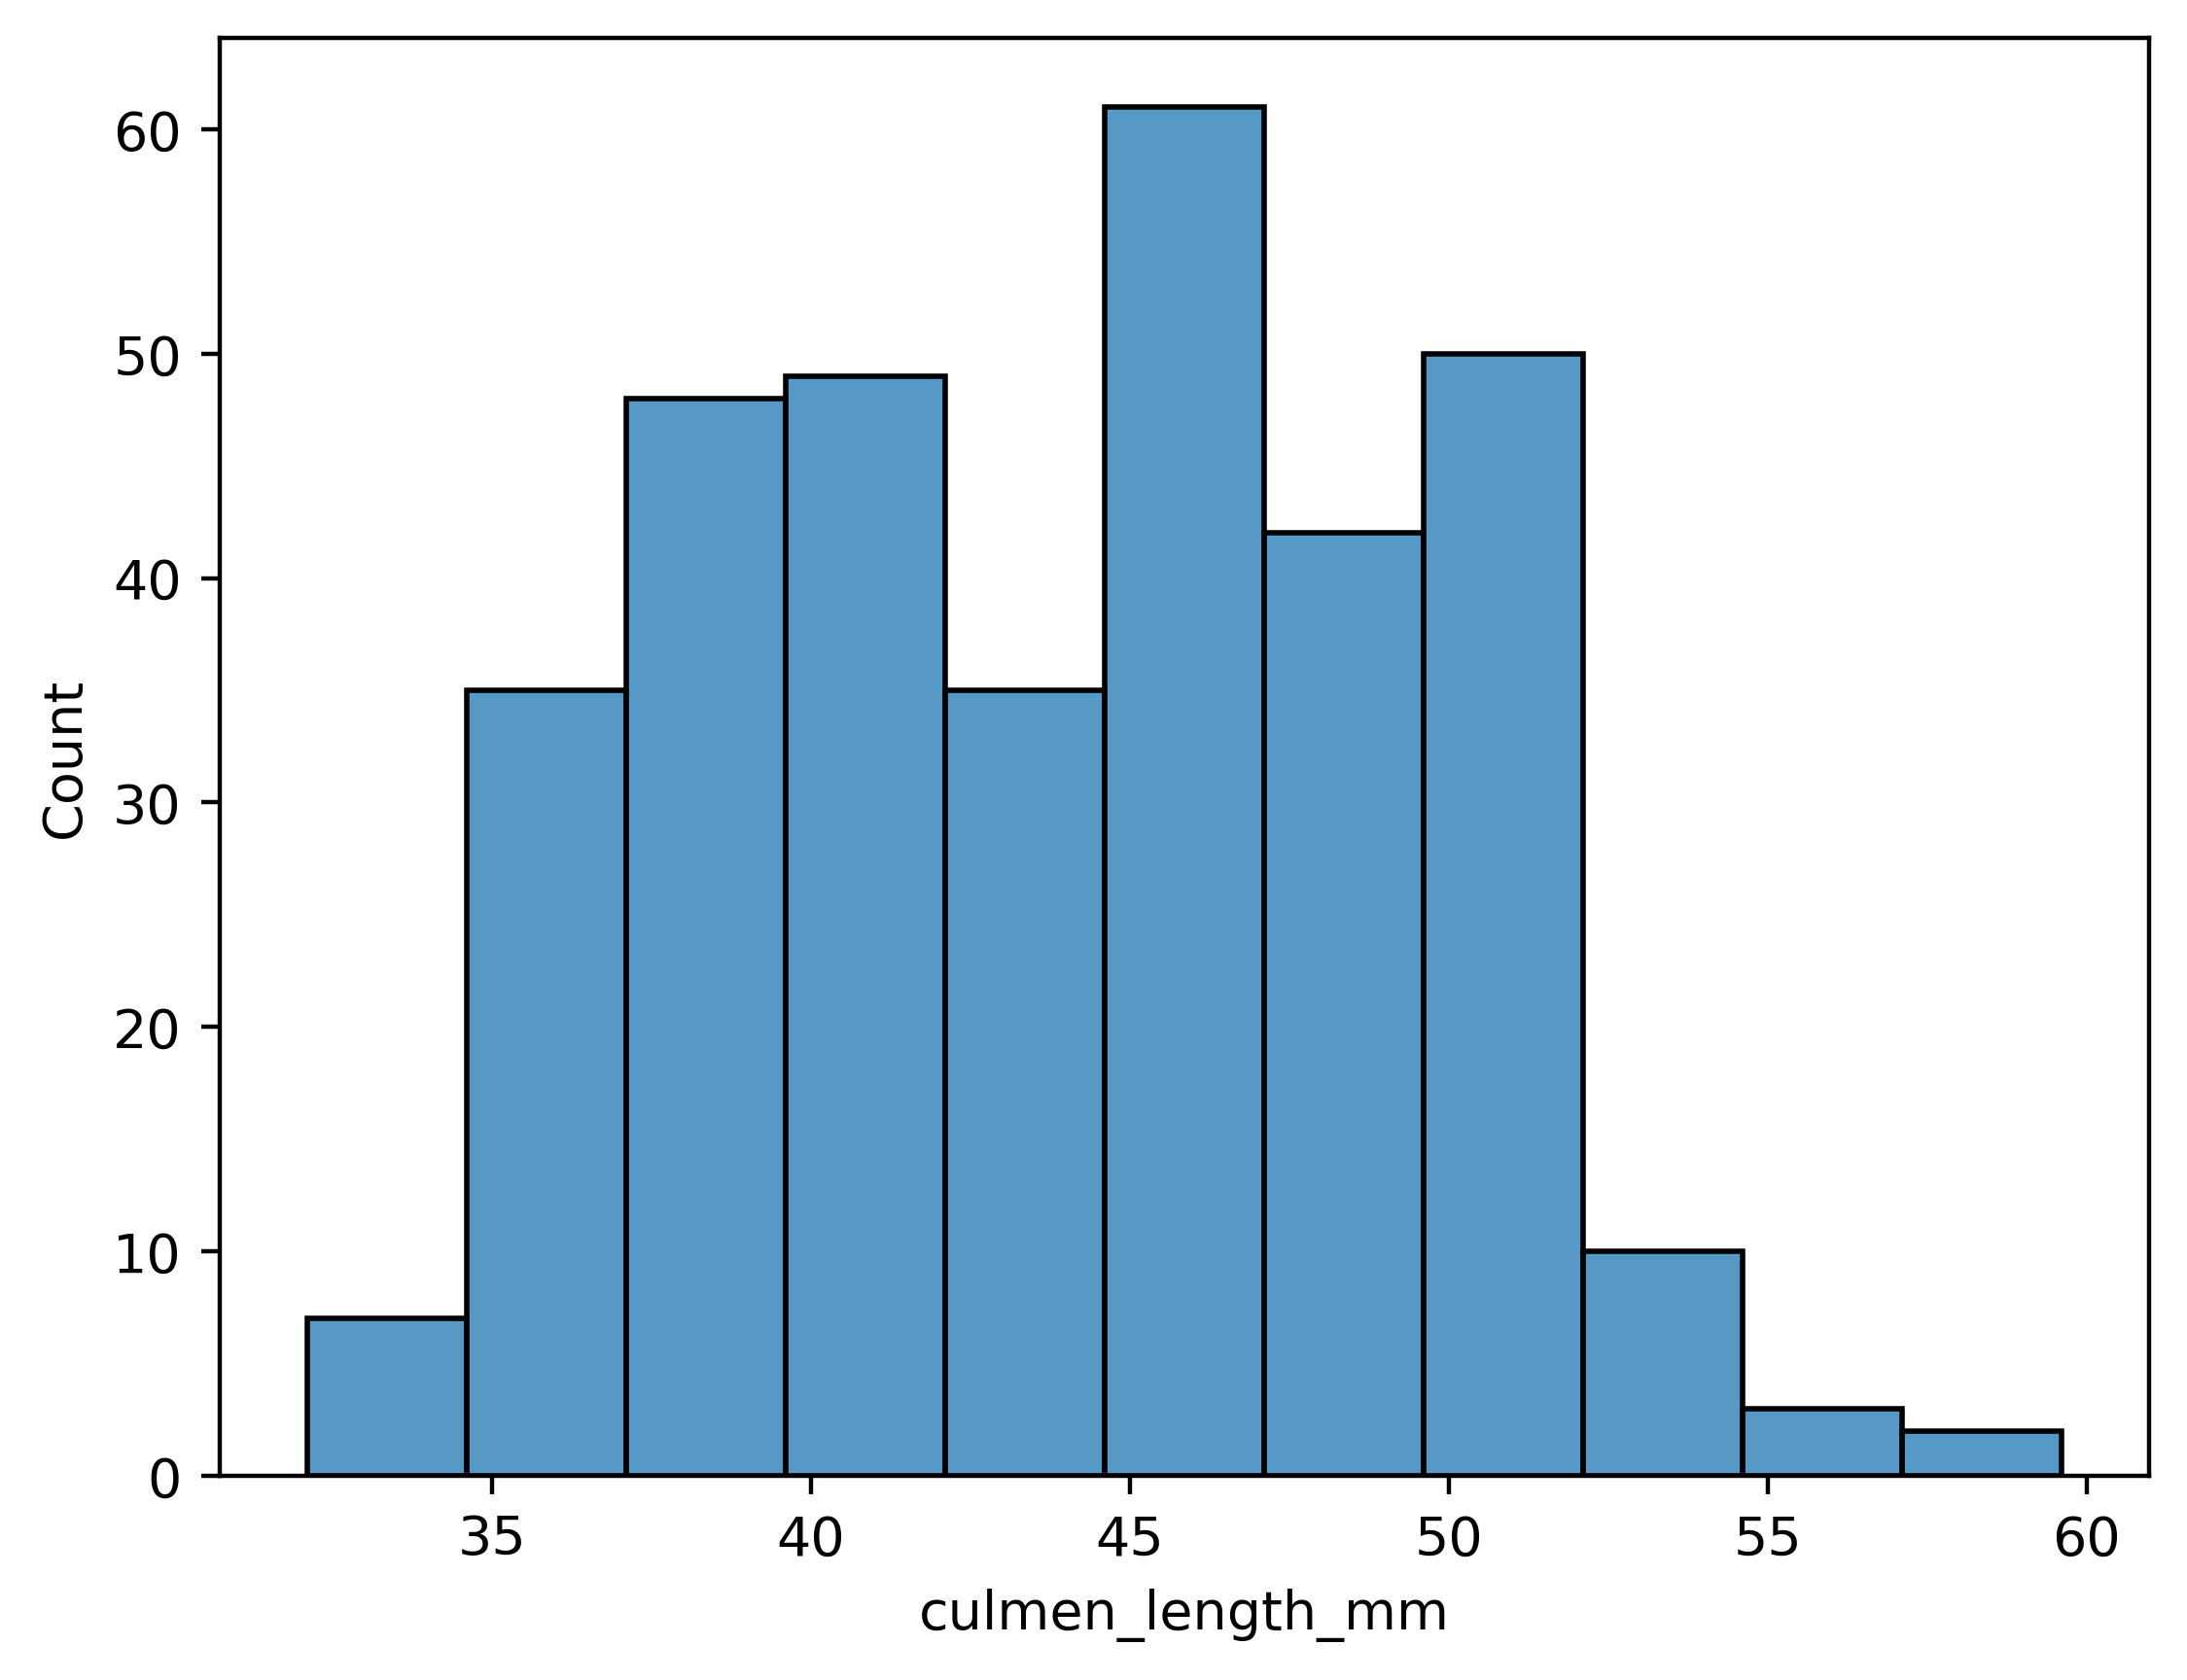

In [18]:
# Phân tích đơn biến bằng Histogram
# case 1: basic
sns.histplot(data = penguins_data, x= penguins_data["culmen_length_mm"])

Text(0.5, 1.0, 'Univariate analysis of Culmen Length')

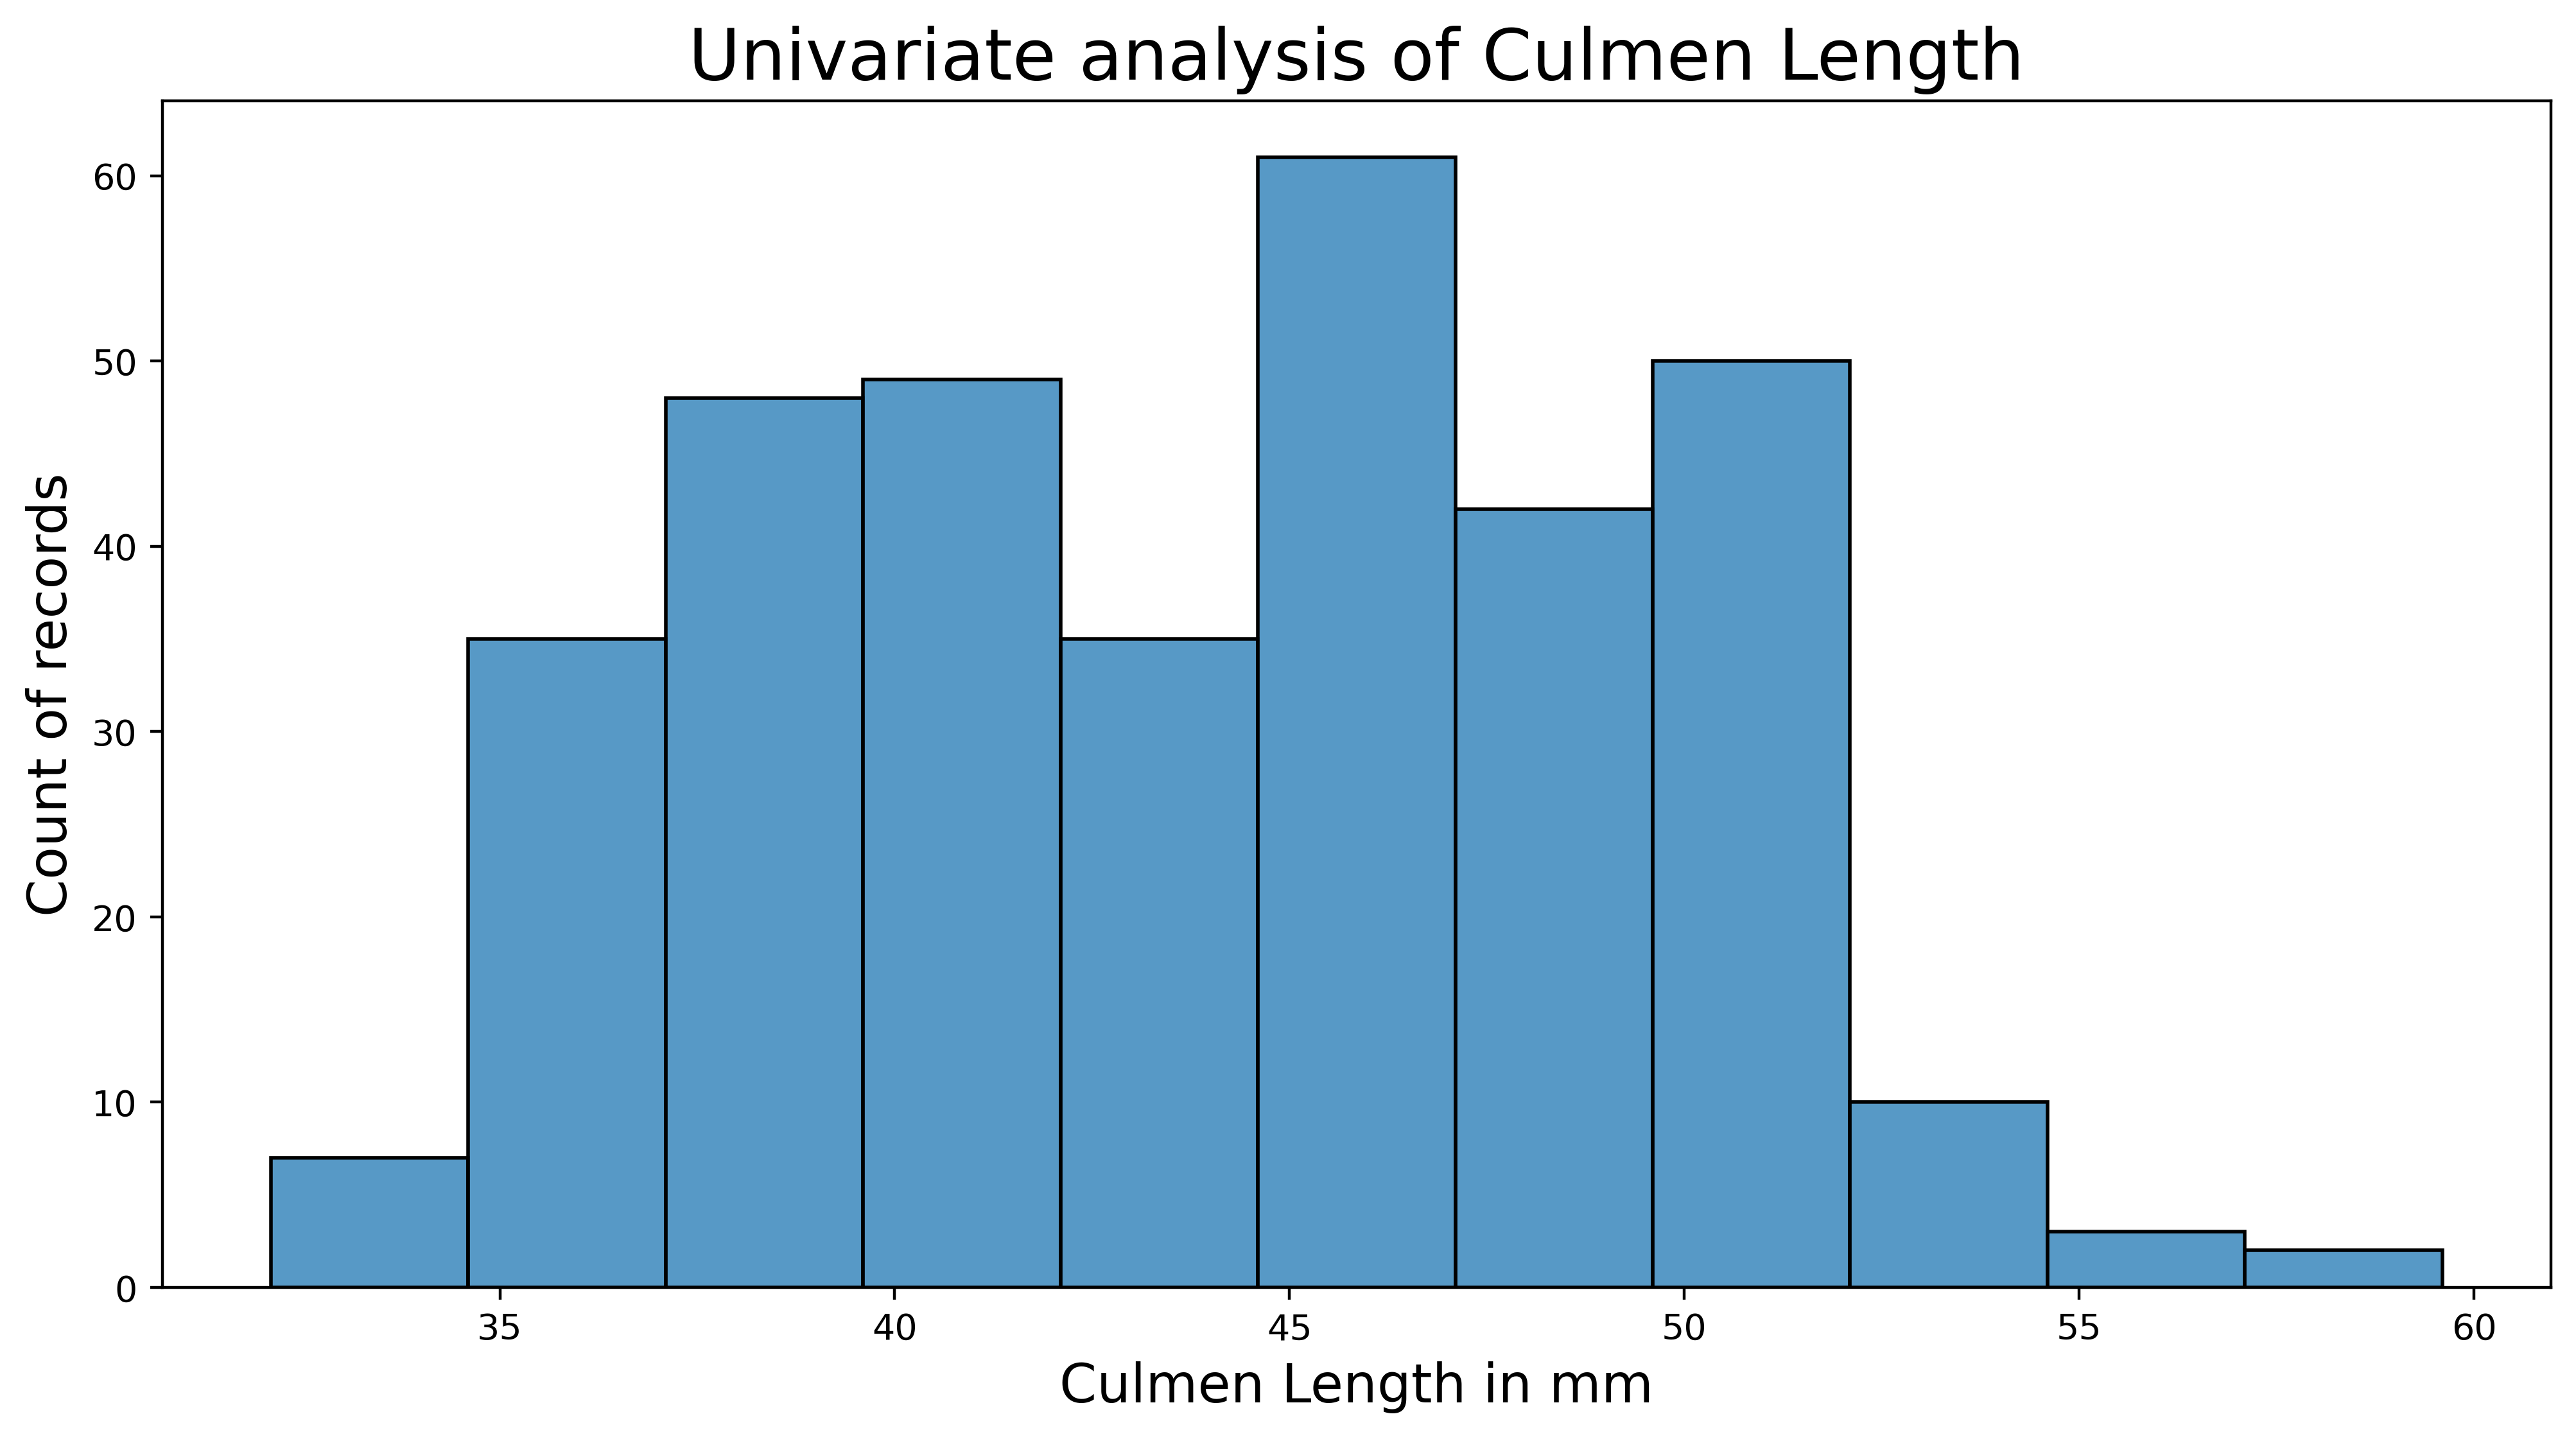

In [20]:
# case 2: advanced
plt.figure(figsize= (12,6)) 
ax = sns.histplot(data = penguins_data, x= penguins_data["culmen_length_mm"])
ax.set_xlabel('Culmen Length in mm',fontsize = 15)
ax.set_ylabel('Count of records', fontsize = 15)
ax.set_title('Univariate analysis of Culmen Length',fontsize= 20)

<Axes: xlabel='species', ylabel='count'>

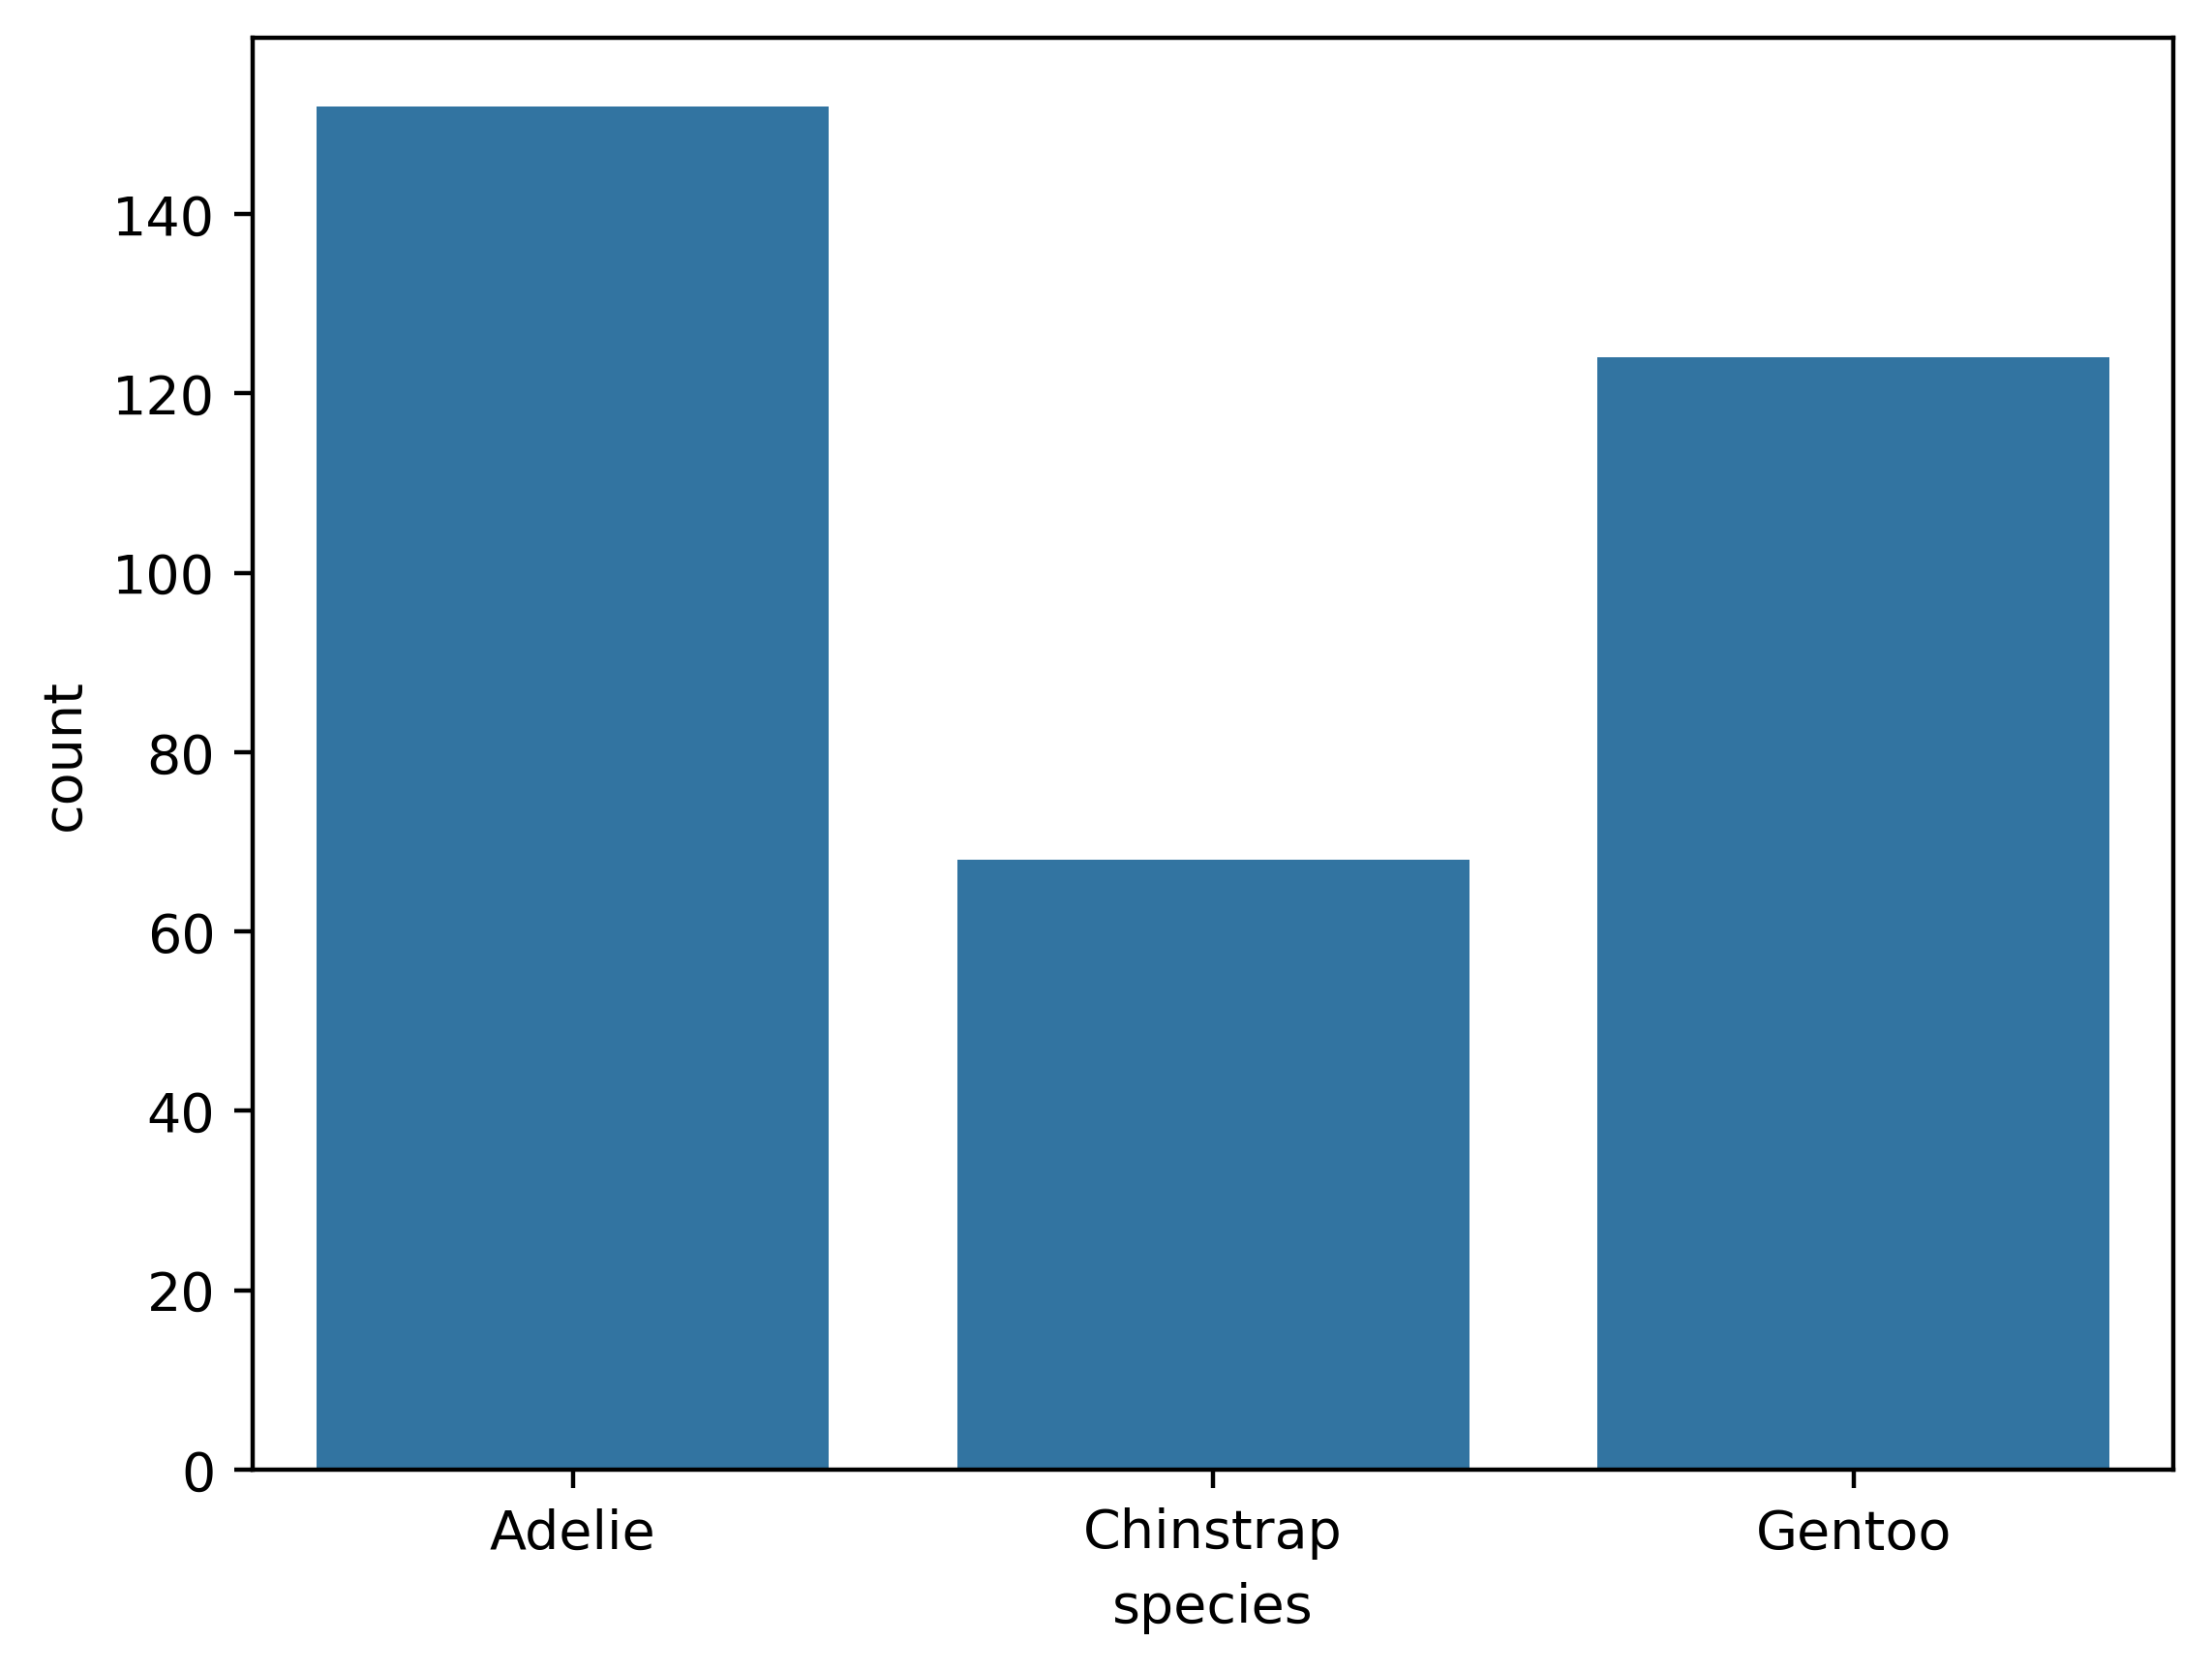

In [21]:
# Phân tích đơn biến bằng bar chart
# case 1: basic
sns.countplot(data = penguins_data, x= penguins_data['species'])

Text(0.5, 1.0, 'Univariate analysis of Culmen Length')

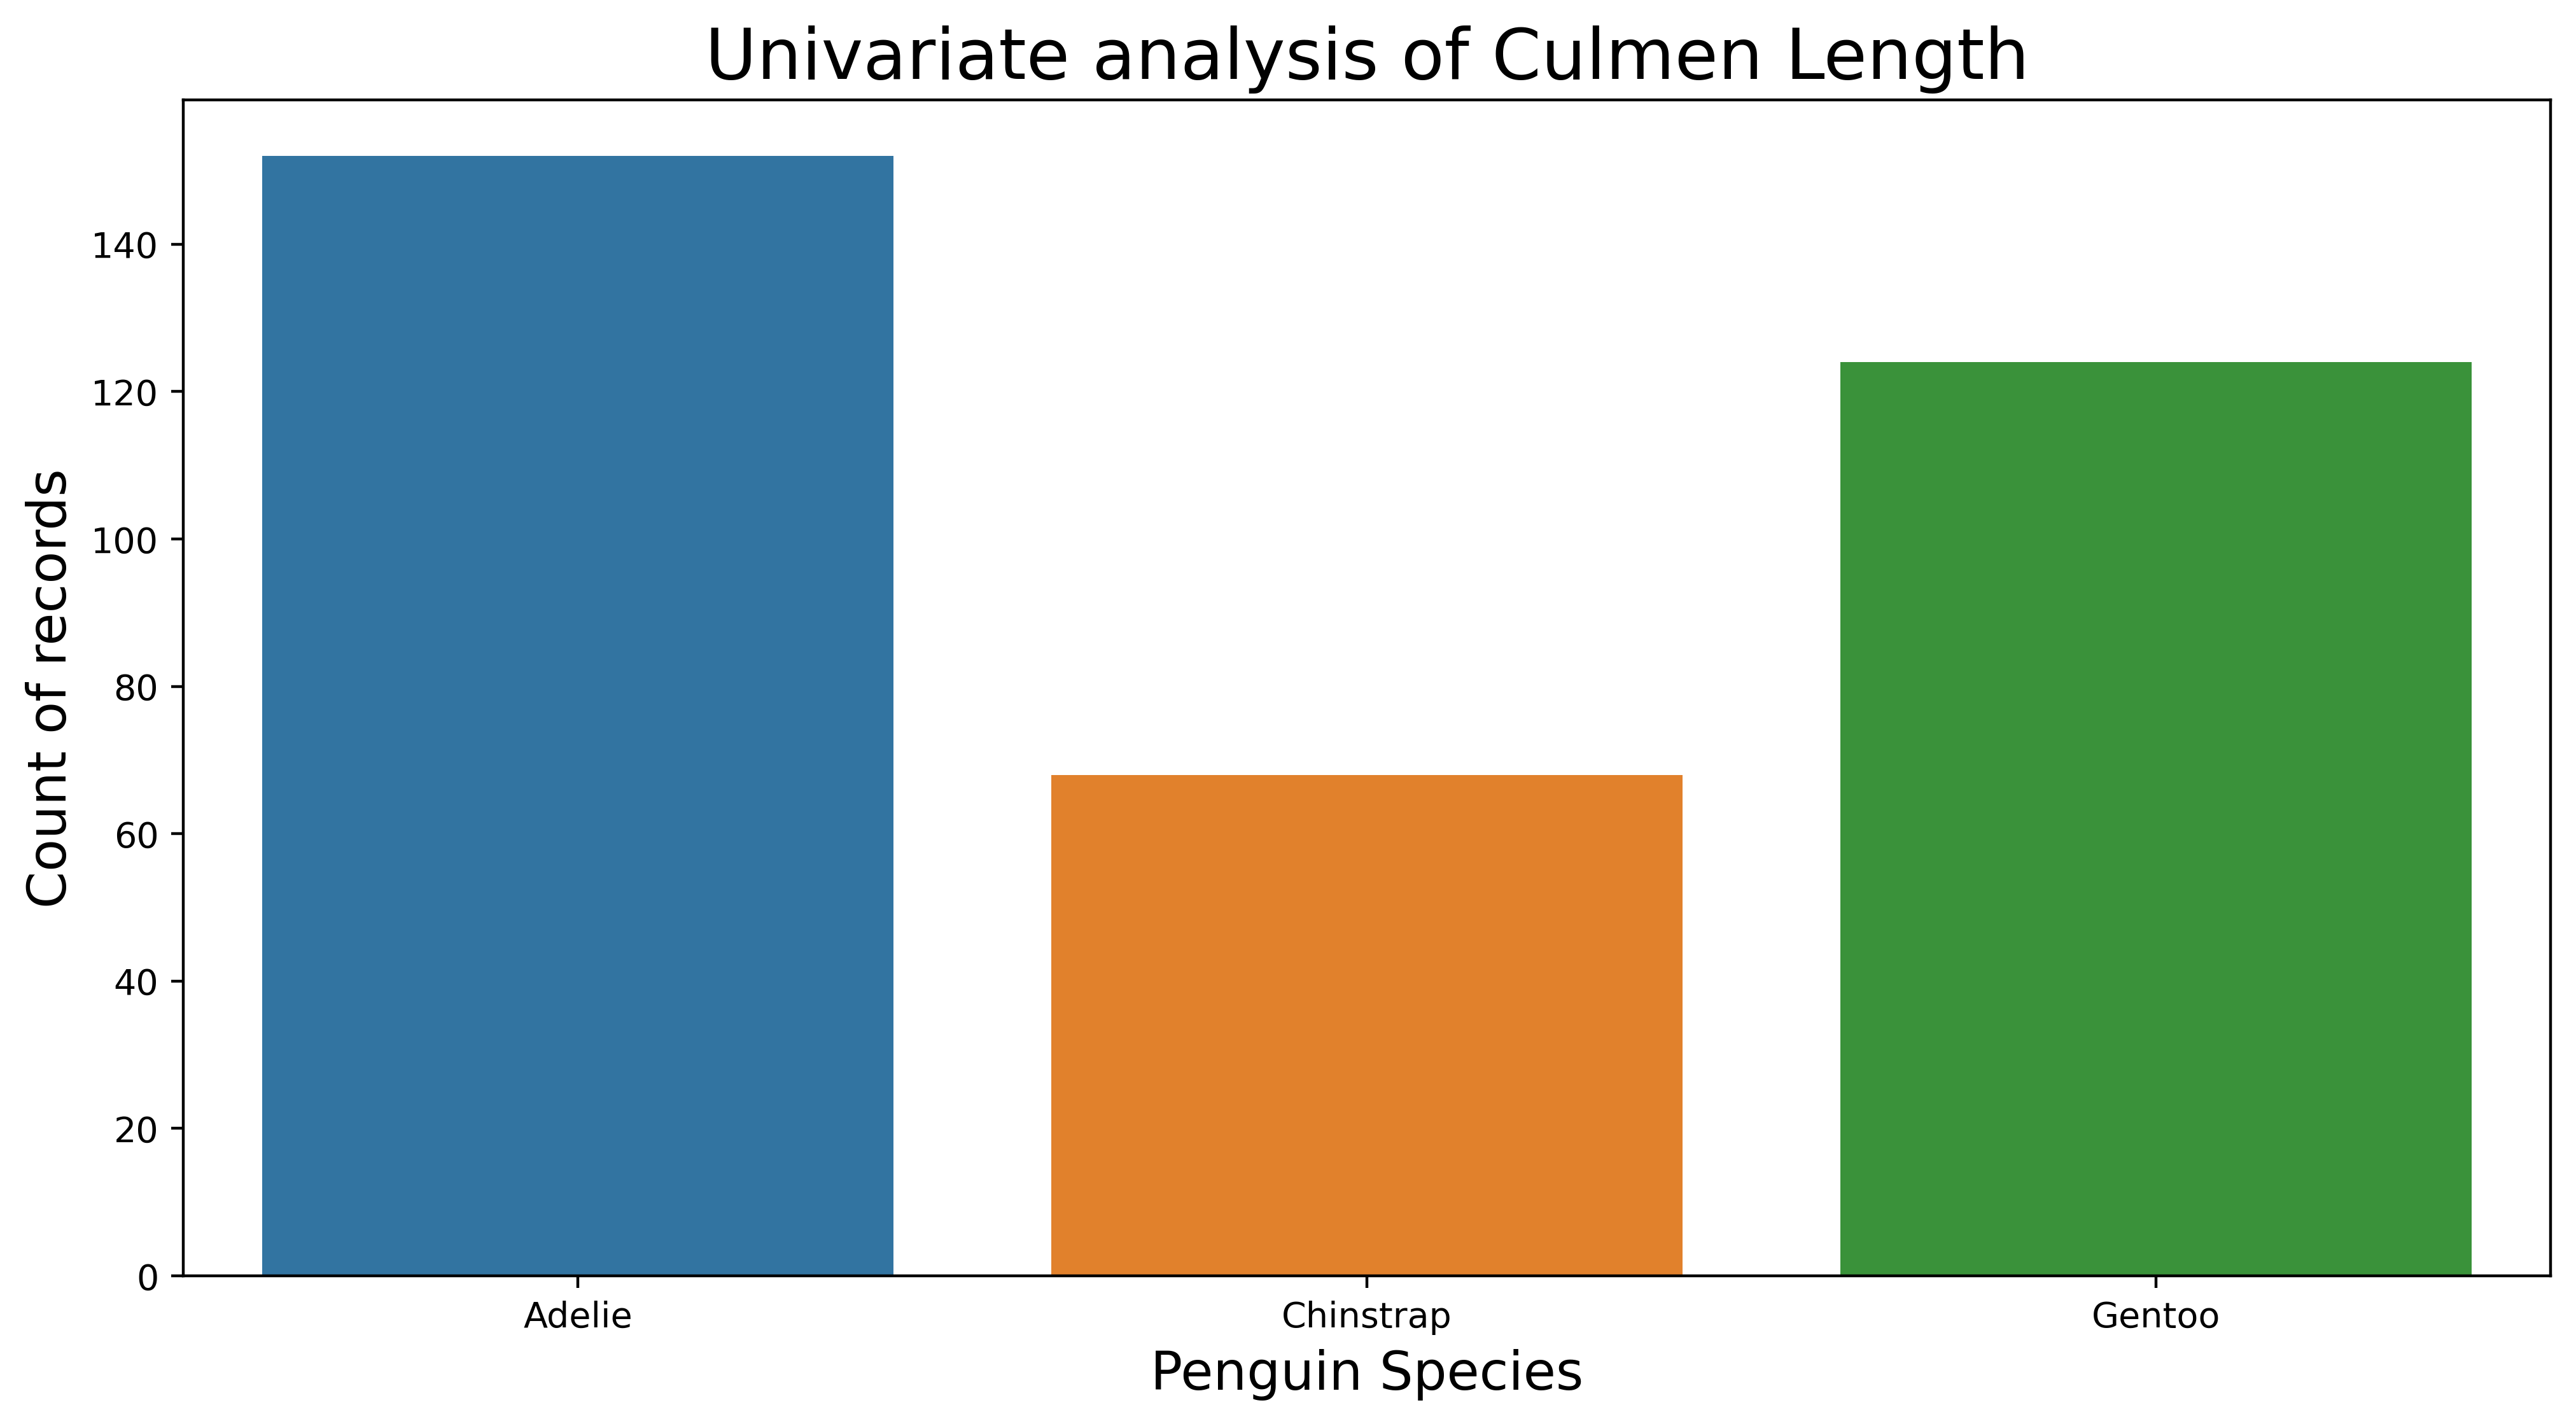

In [23]:
# case 2: advanced
plt.figure(figsize= (12,6))
ax = sns.countplot(data = penguins_data, x= penguins_data['species'], hue='species')
ax.set_xlabel('Penguin Species',fontsize = 15)
ax.set_ylabel('Count of records',fontsize = 15)
ax.set_title('Univariate analysis of Penguin Species', fontsize= 20)
ax.set_title('Univariate analysis of Culmen Length', fontsize= 20)

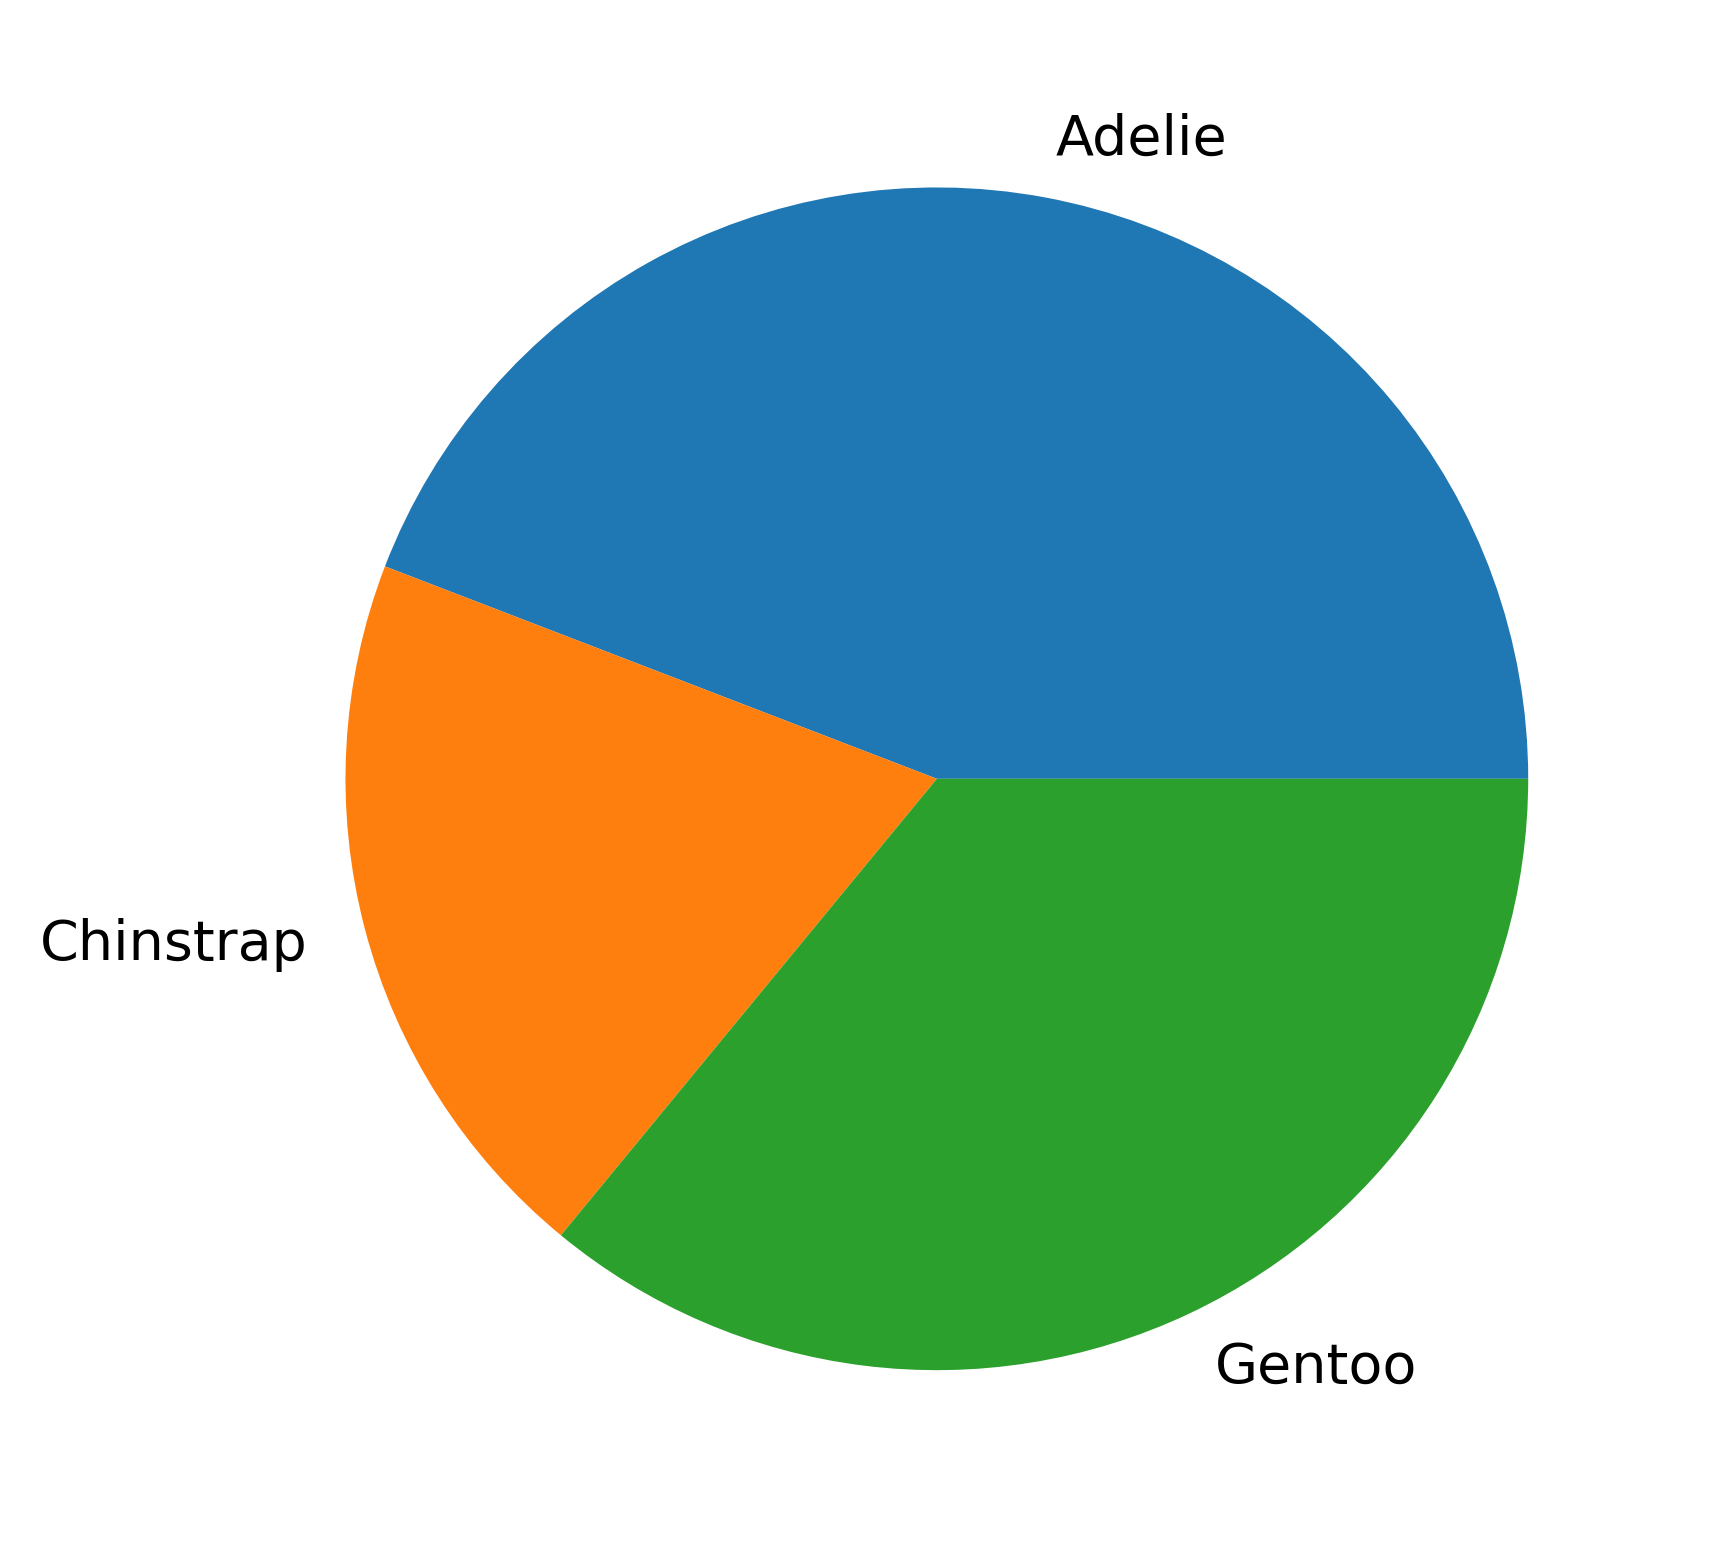

In [24]:
# Phân tích đơn biến bằng biểu đồ tròn (Pie-chart)
penguins_group = penguins_data.groupby('species').count()
penguins_group = penguins_group.reset_index()
# case 1: basic
plt.pie(penguins_group["culmen_length_mm"], labels = penguins_group['species'])
plt.show()

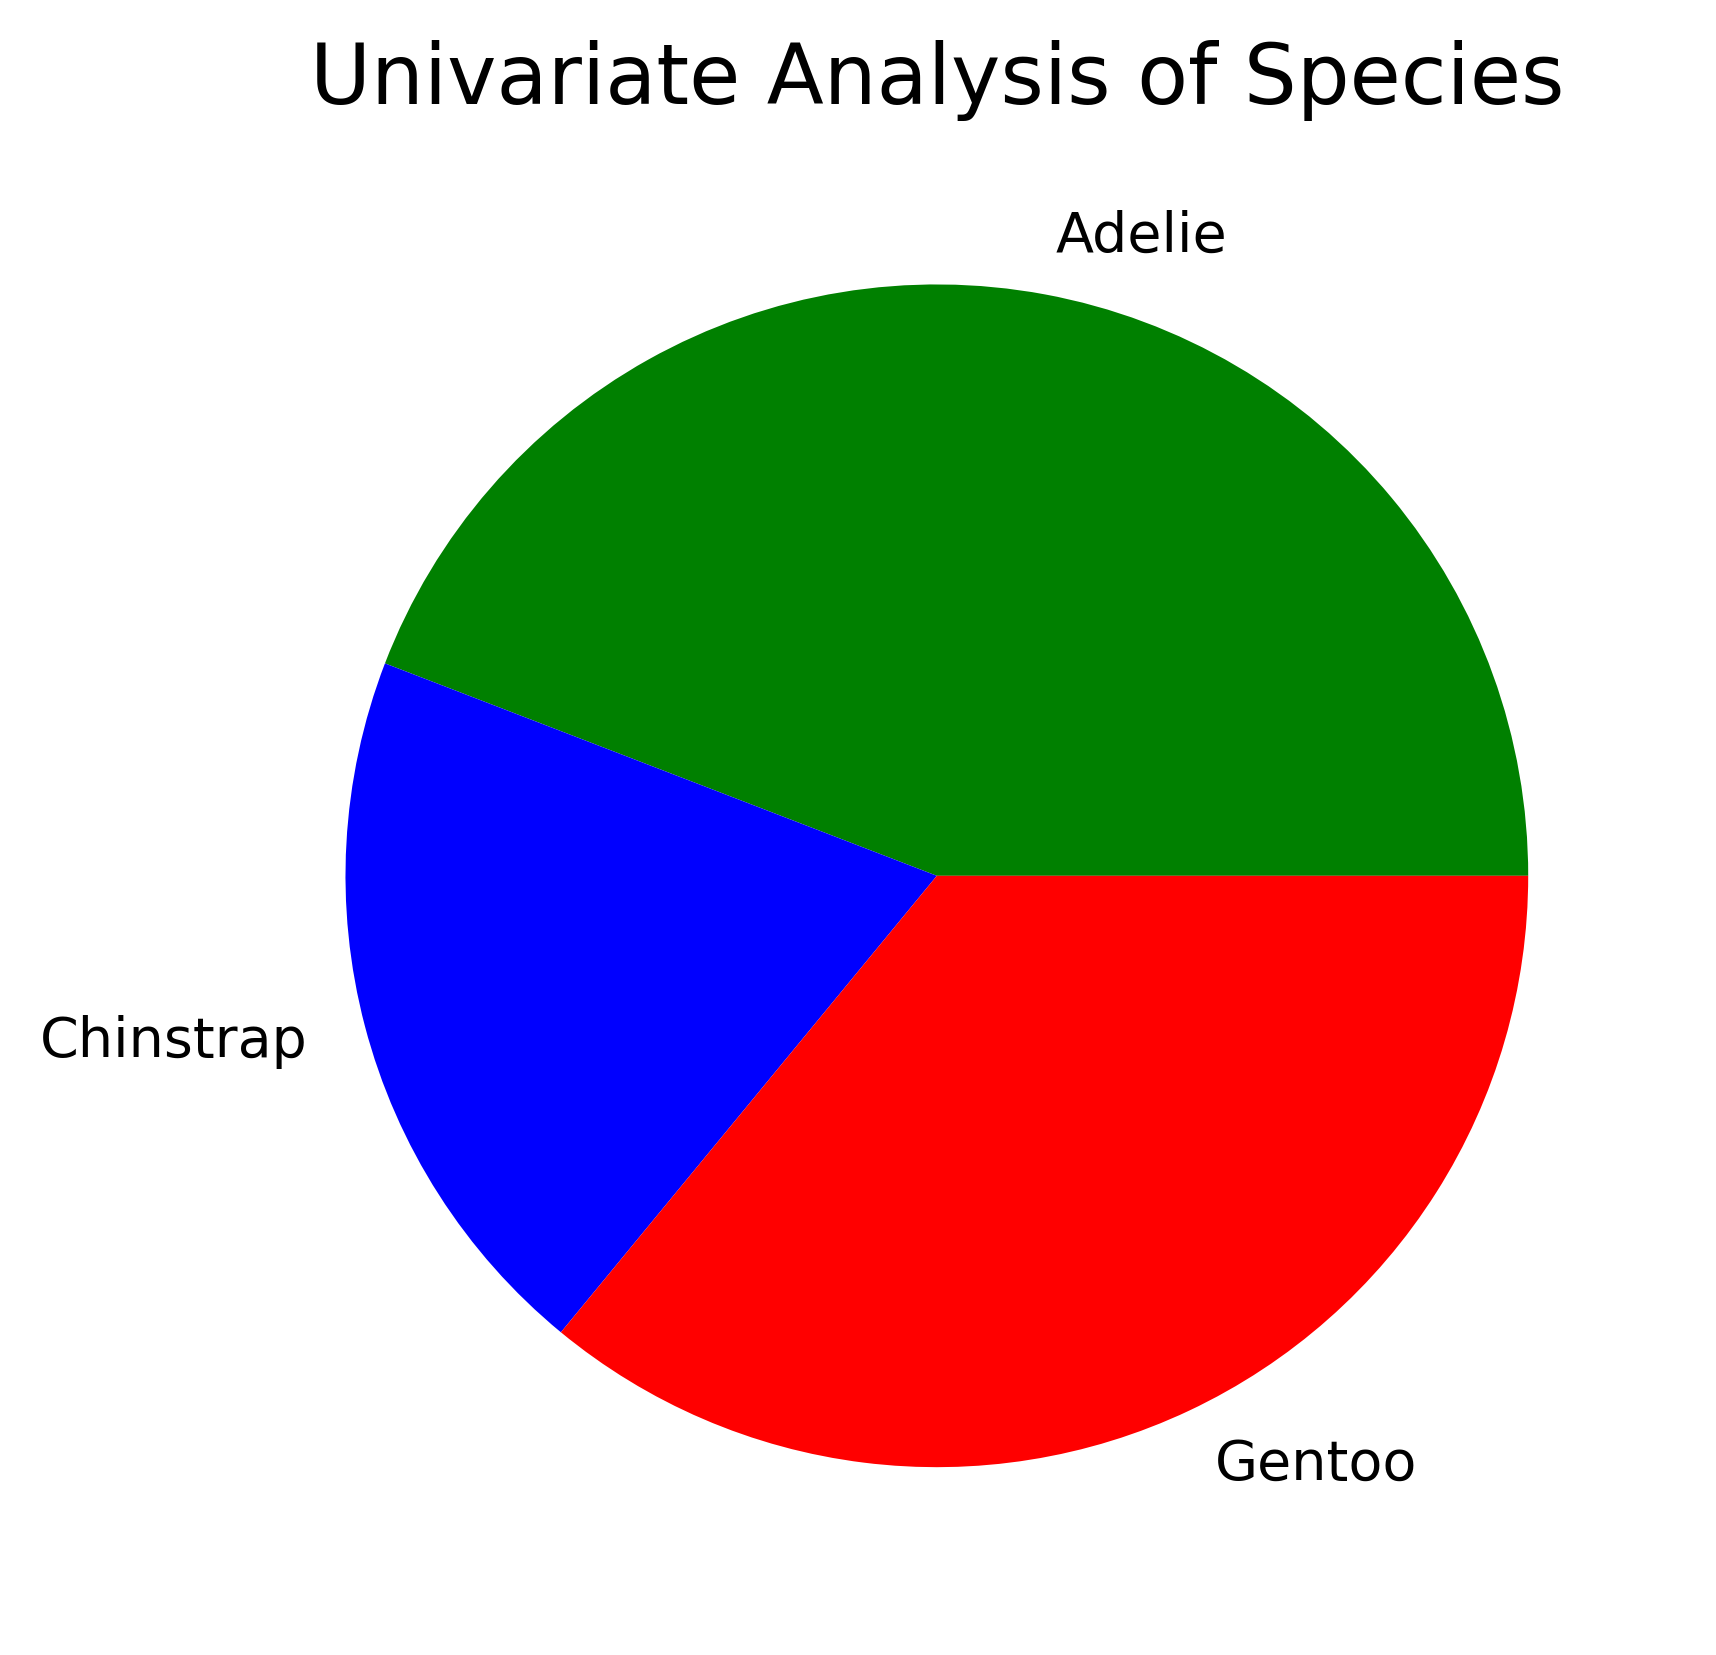

In [25]:
# case 2: advanced
cols = ['g', 'b', 'r']
plt.pie(penguins_group["culmen_length_mm"], labels = penguins_group['species'],colors = cols)
plt.title('Univariate Analysis of Species', fontsize=15)
plt.show()

#### Nhiệm vụ 2: Phân tích dữ liệu đơn biến trên dữ liệu giá nhà

In [26]:
# Import thư viện, nạp dữ liệu giá nhà và phân tích đơn biến dựa vào boxplot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
houseprices_data = pd.read_csv("Data/HousingPrices-Amsterdam-August-2021.csv")
houseprices_data = houseprices_data[['Zip','Price','Area','Room']]

<Axes: xlabel='Price'>

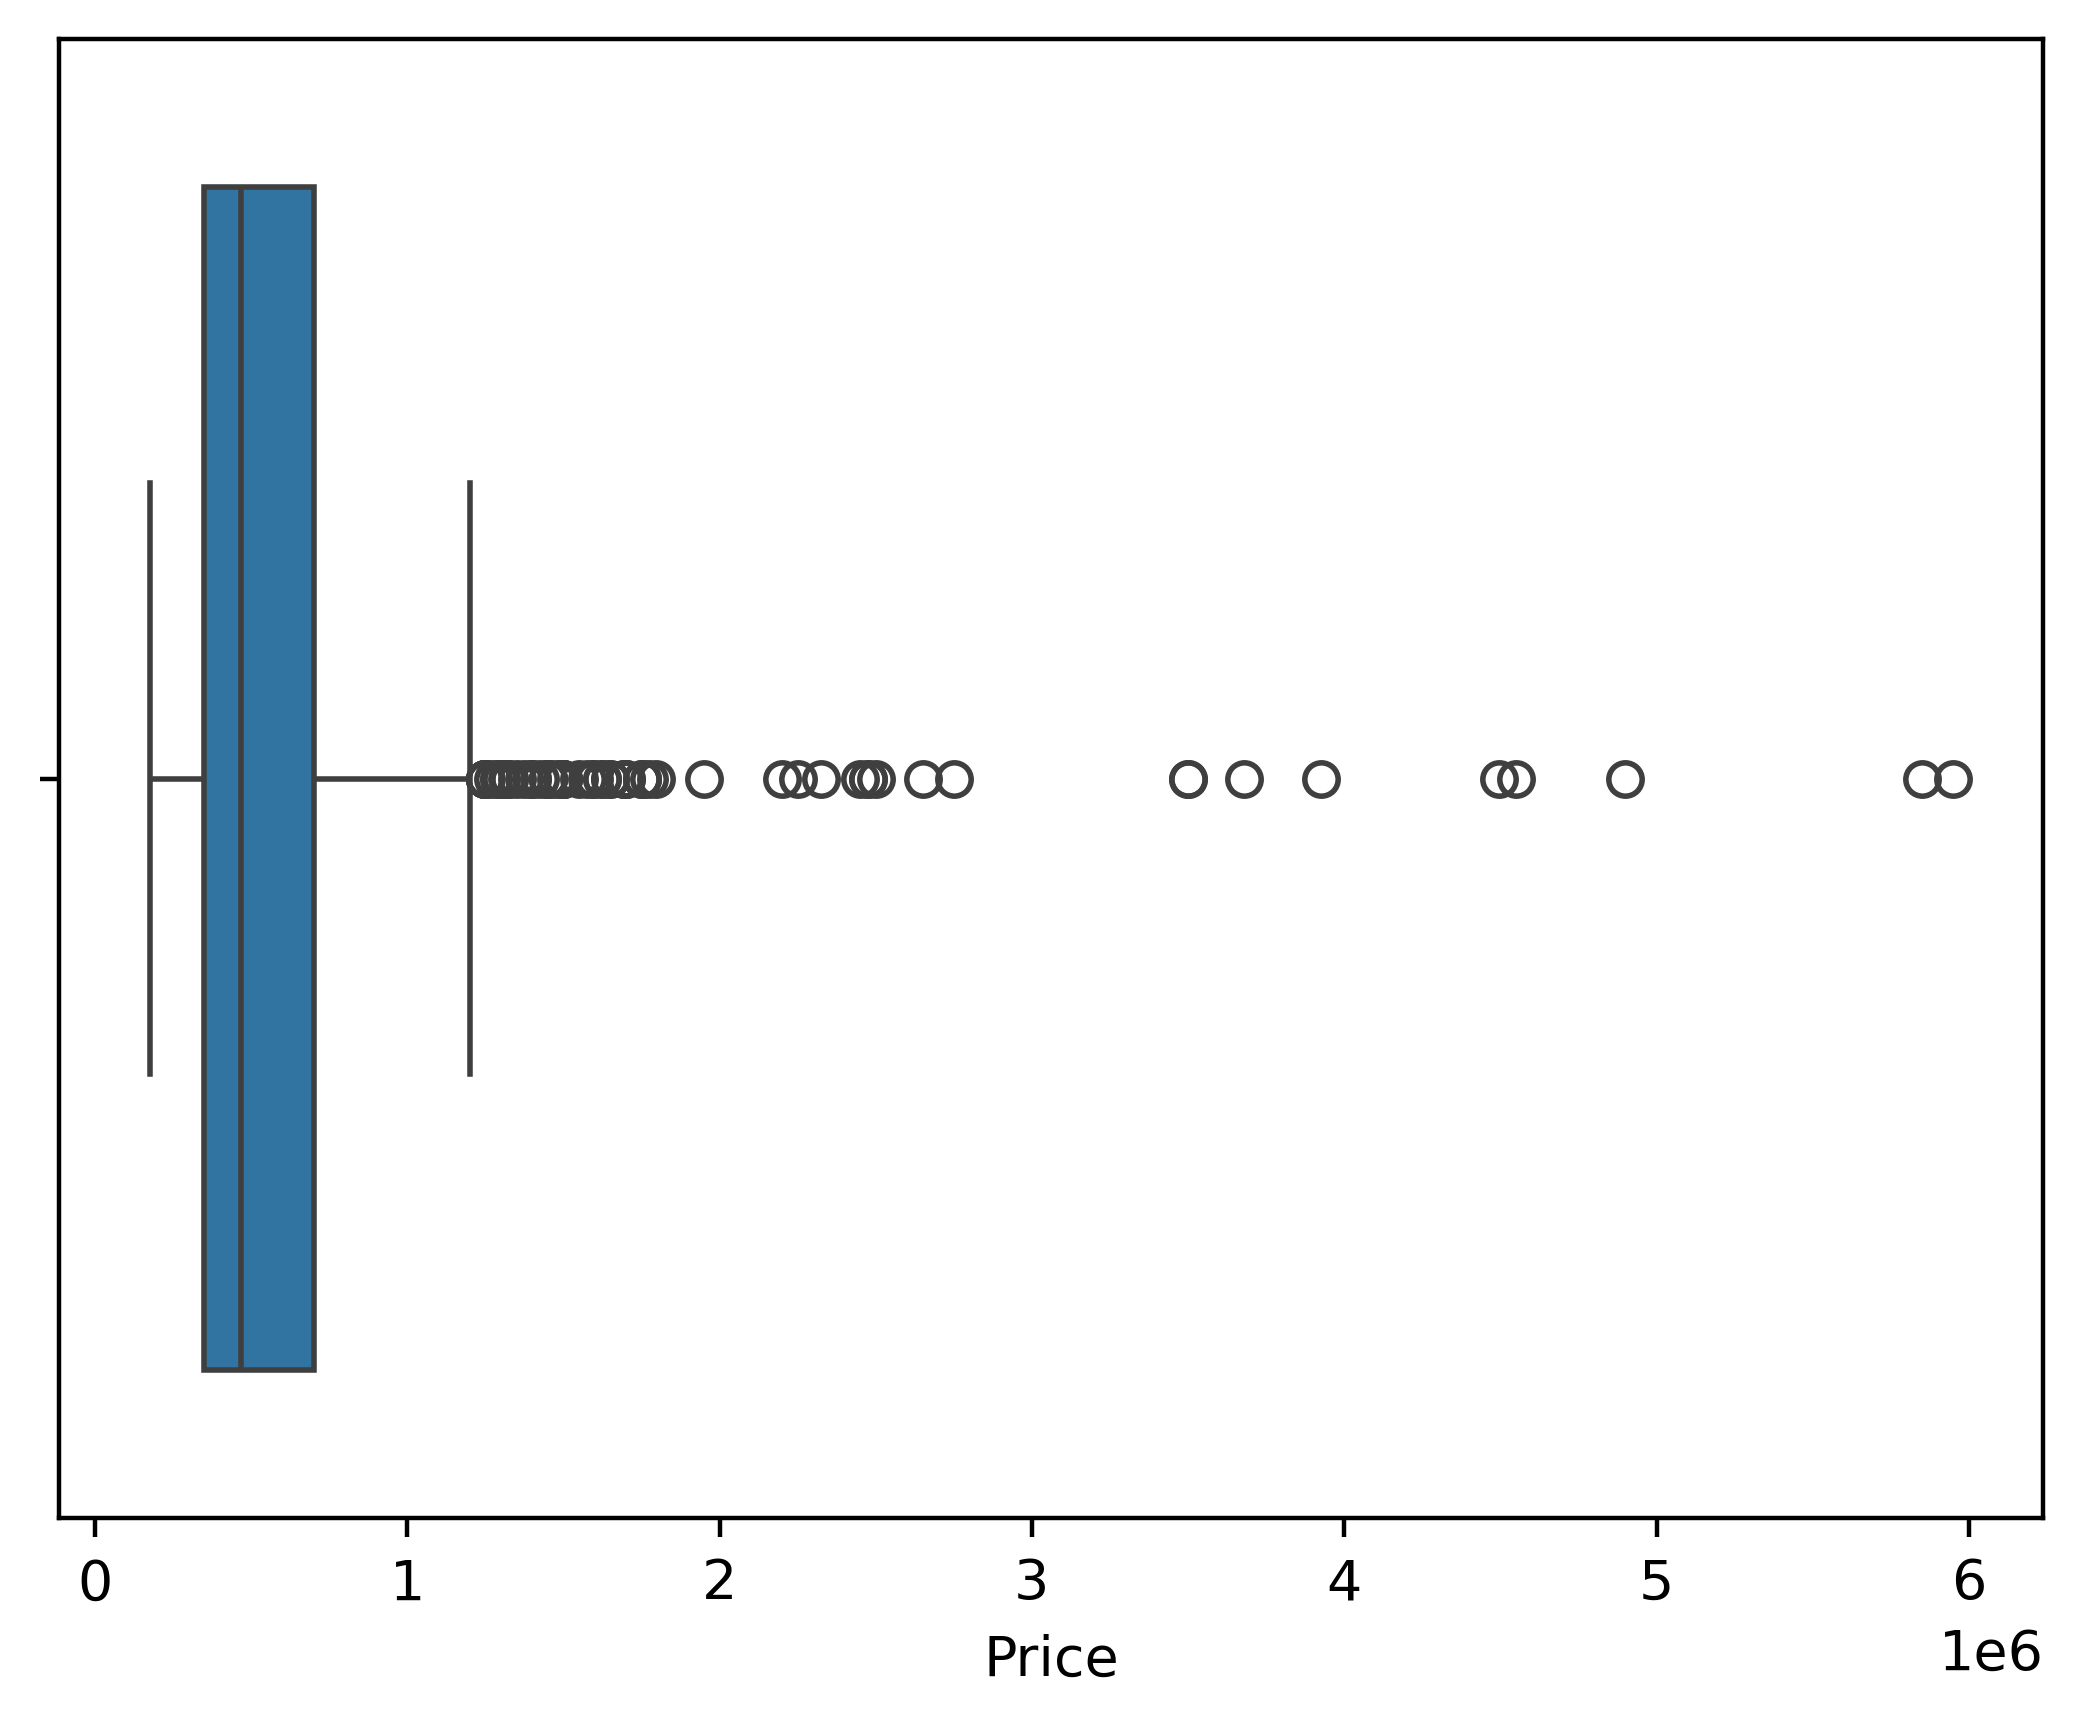

In [27]:
# case 1: Create a boxplot using the boxplot method
sns.boxplot(data = houseprices_data, x= houseprices_data["Price"])

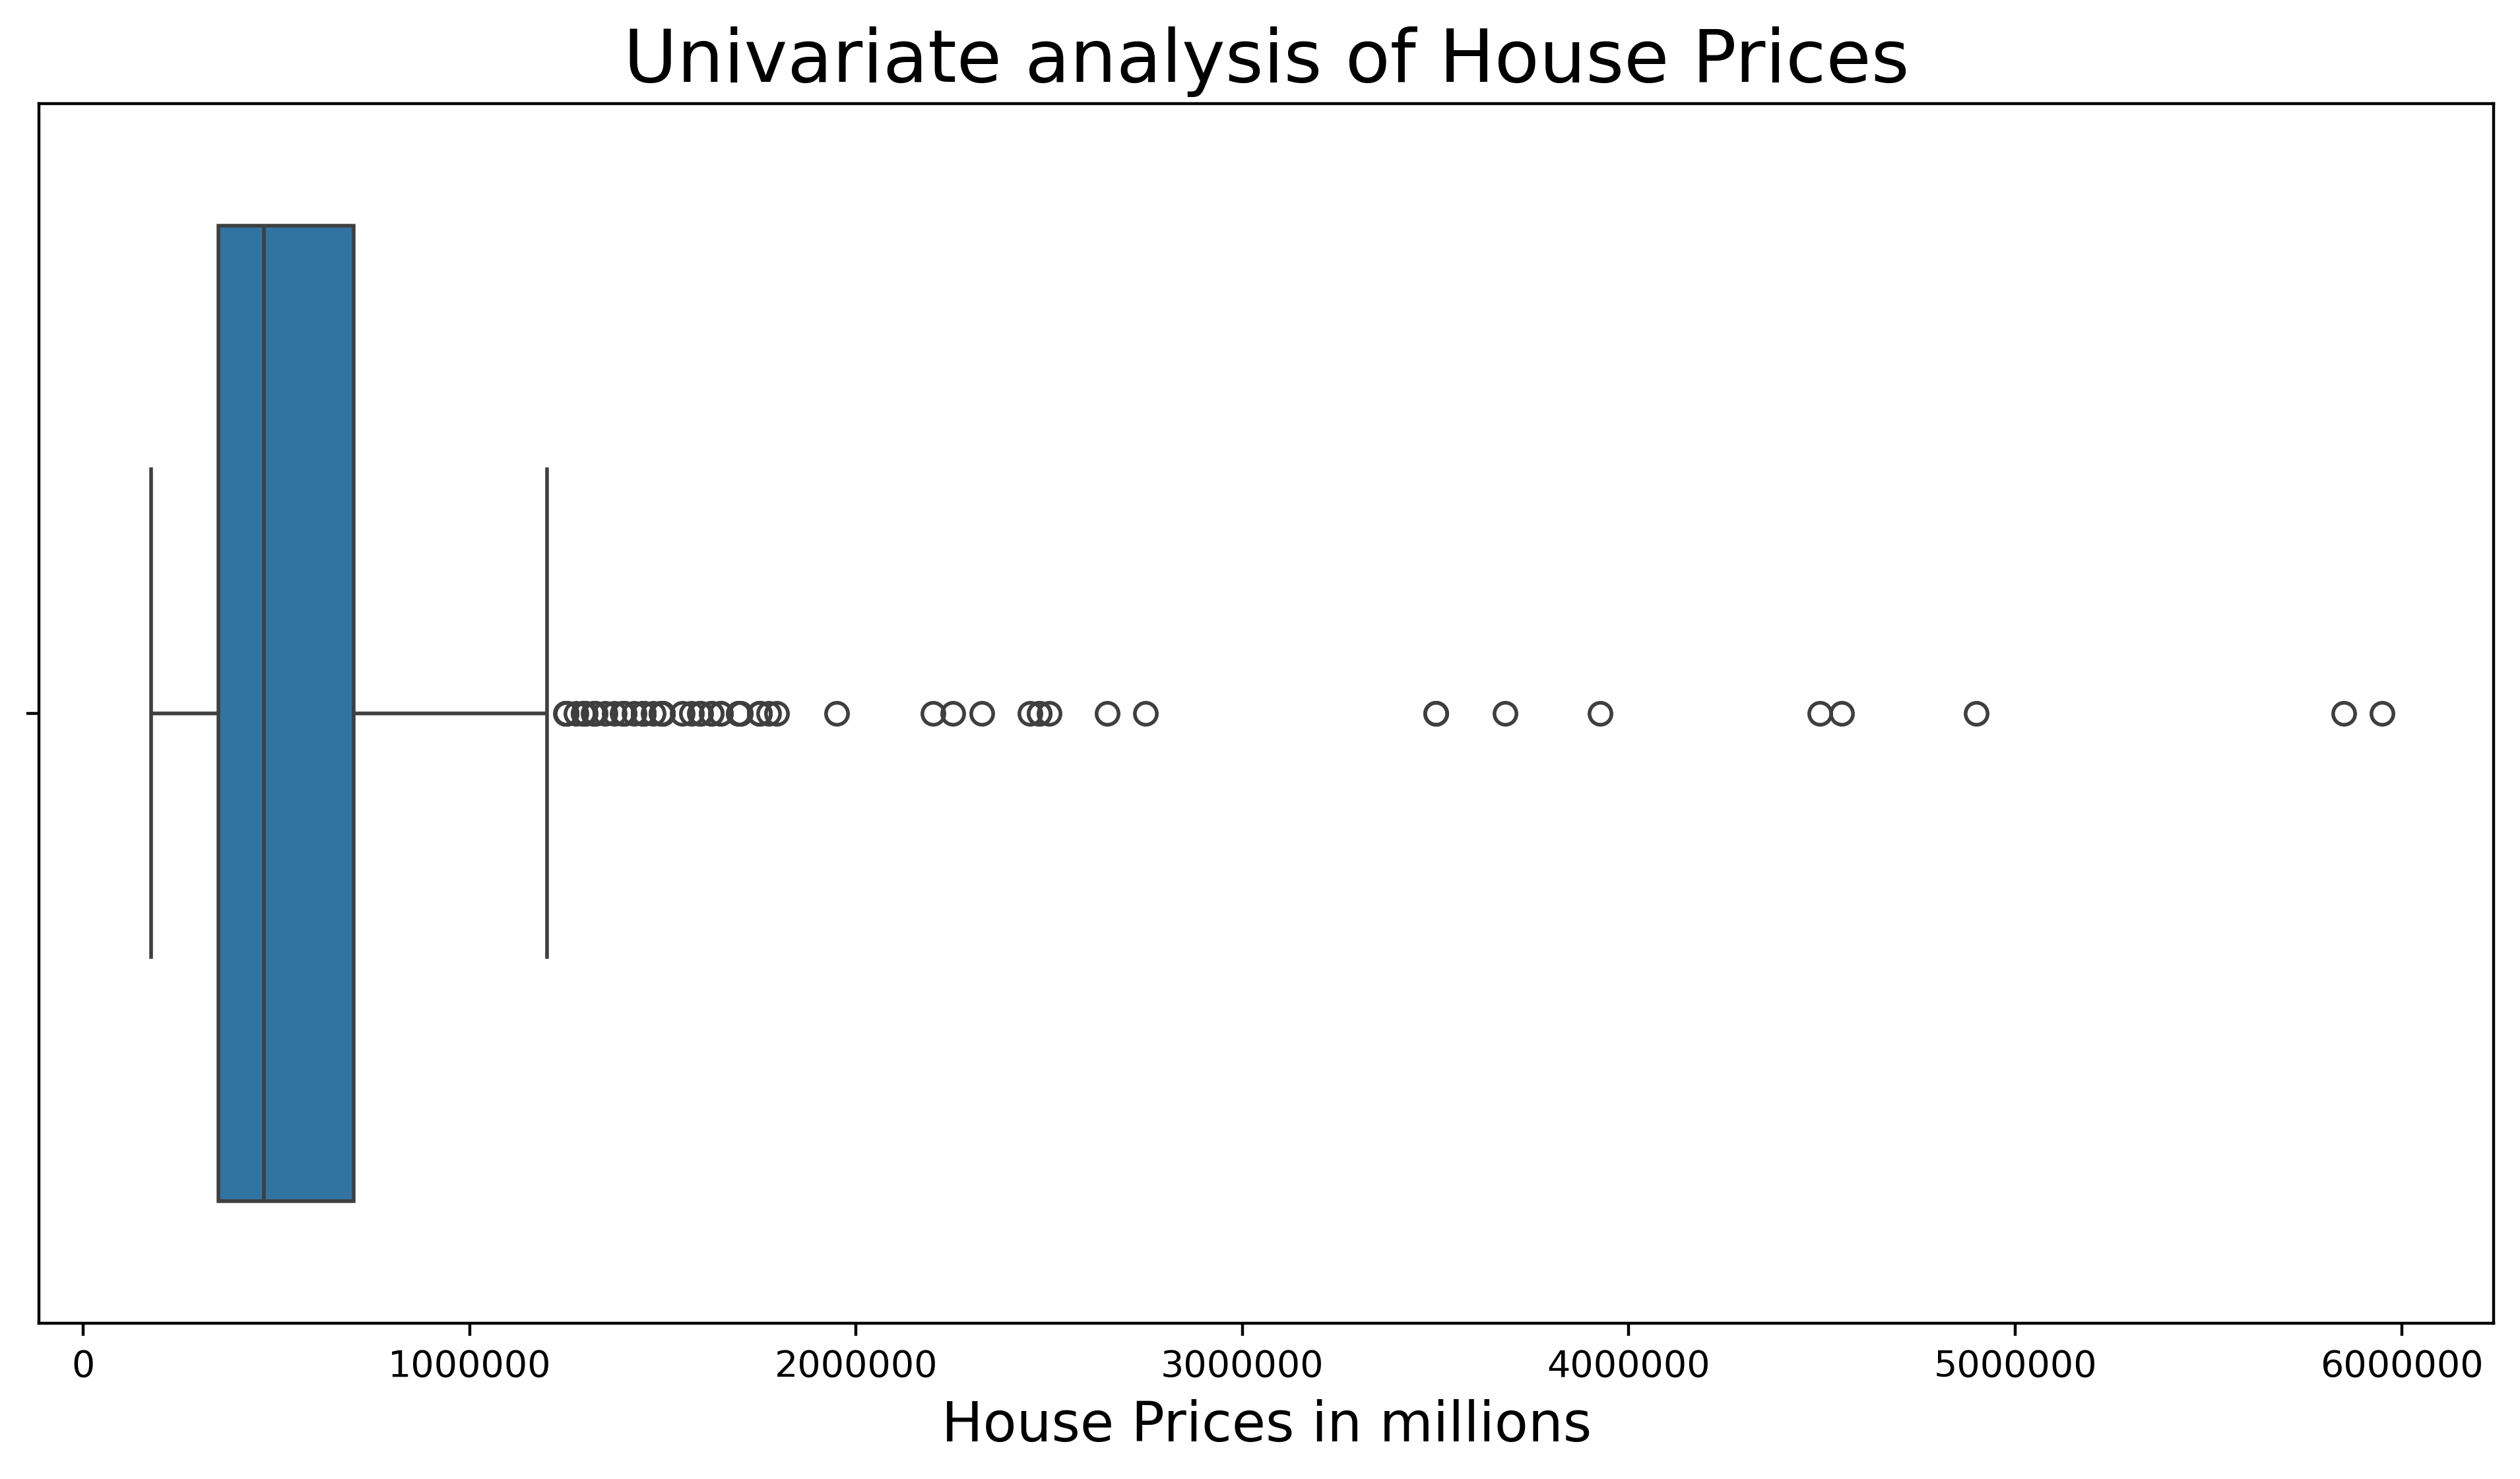

In [28]:
# case 2: advanced
plt.figure(figsize= (12,6))
ax = sns.boxplot(data = houseprices_data, x= houseprices_data["Price"])
ax.set_xlabel('House Prices in millions',fontsize = 15)
ax.set_title('Univariate analysis of House Prices', fontsize= 20)
plt.ticklabel_format(style='plain', axis='x')

<Axes: xlabel='Price'>

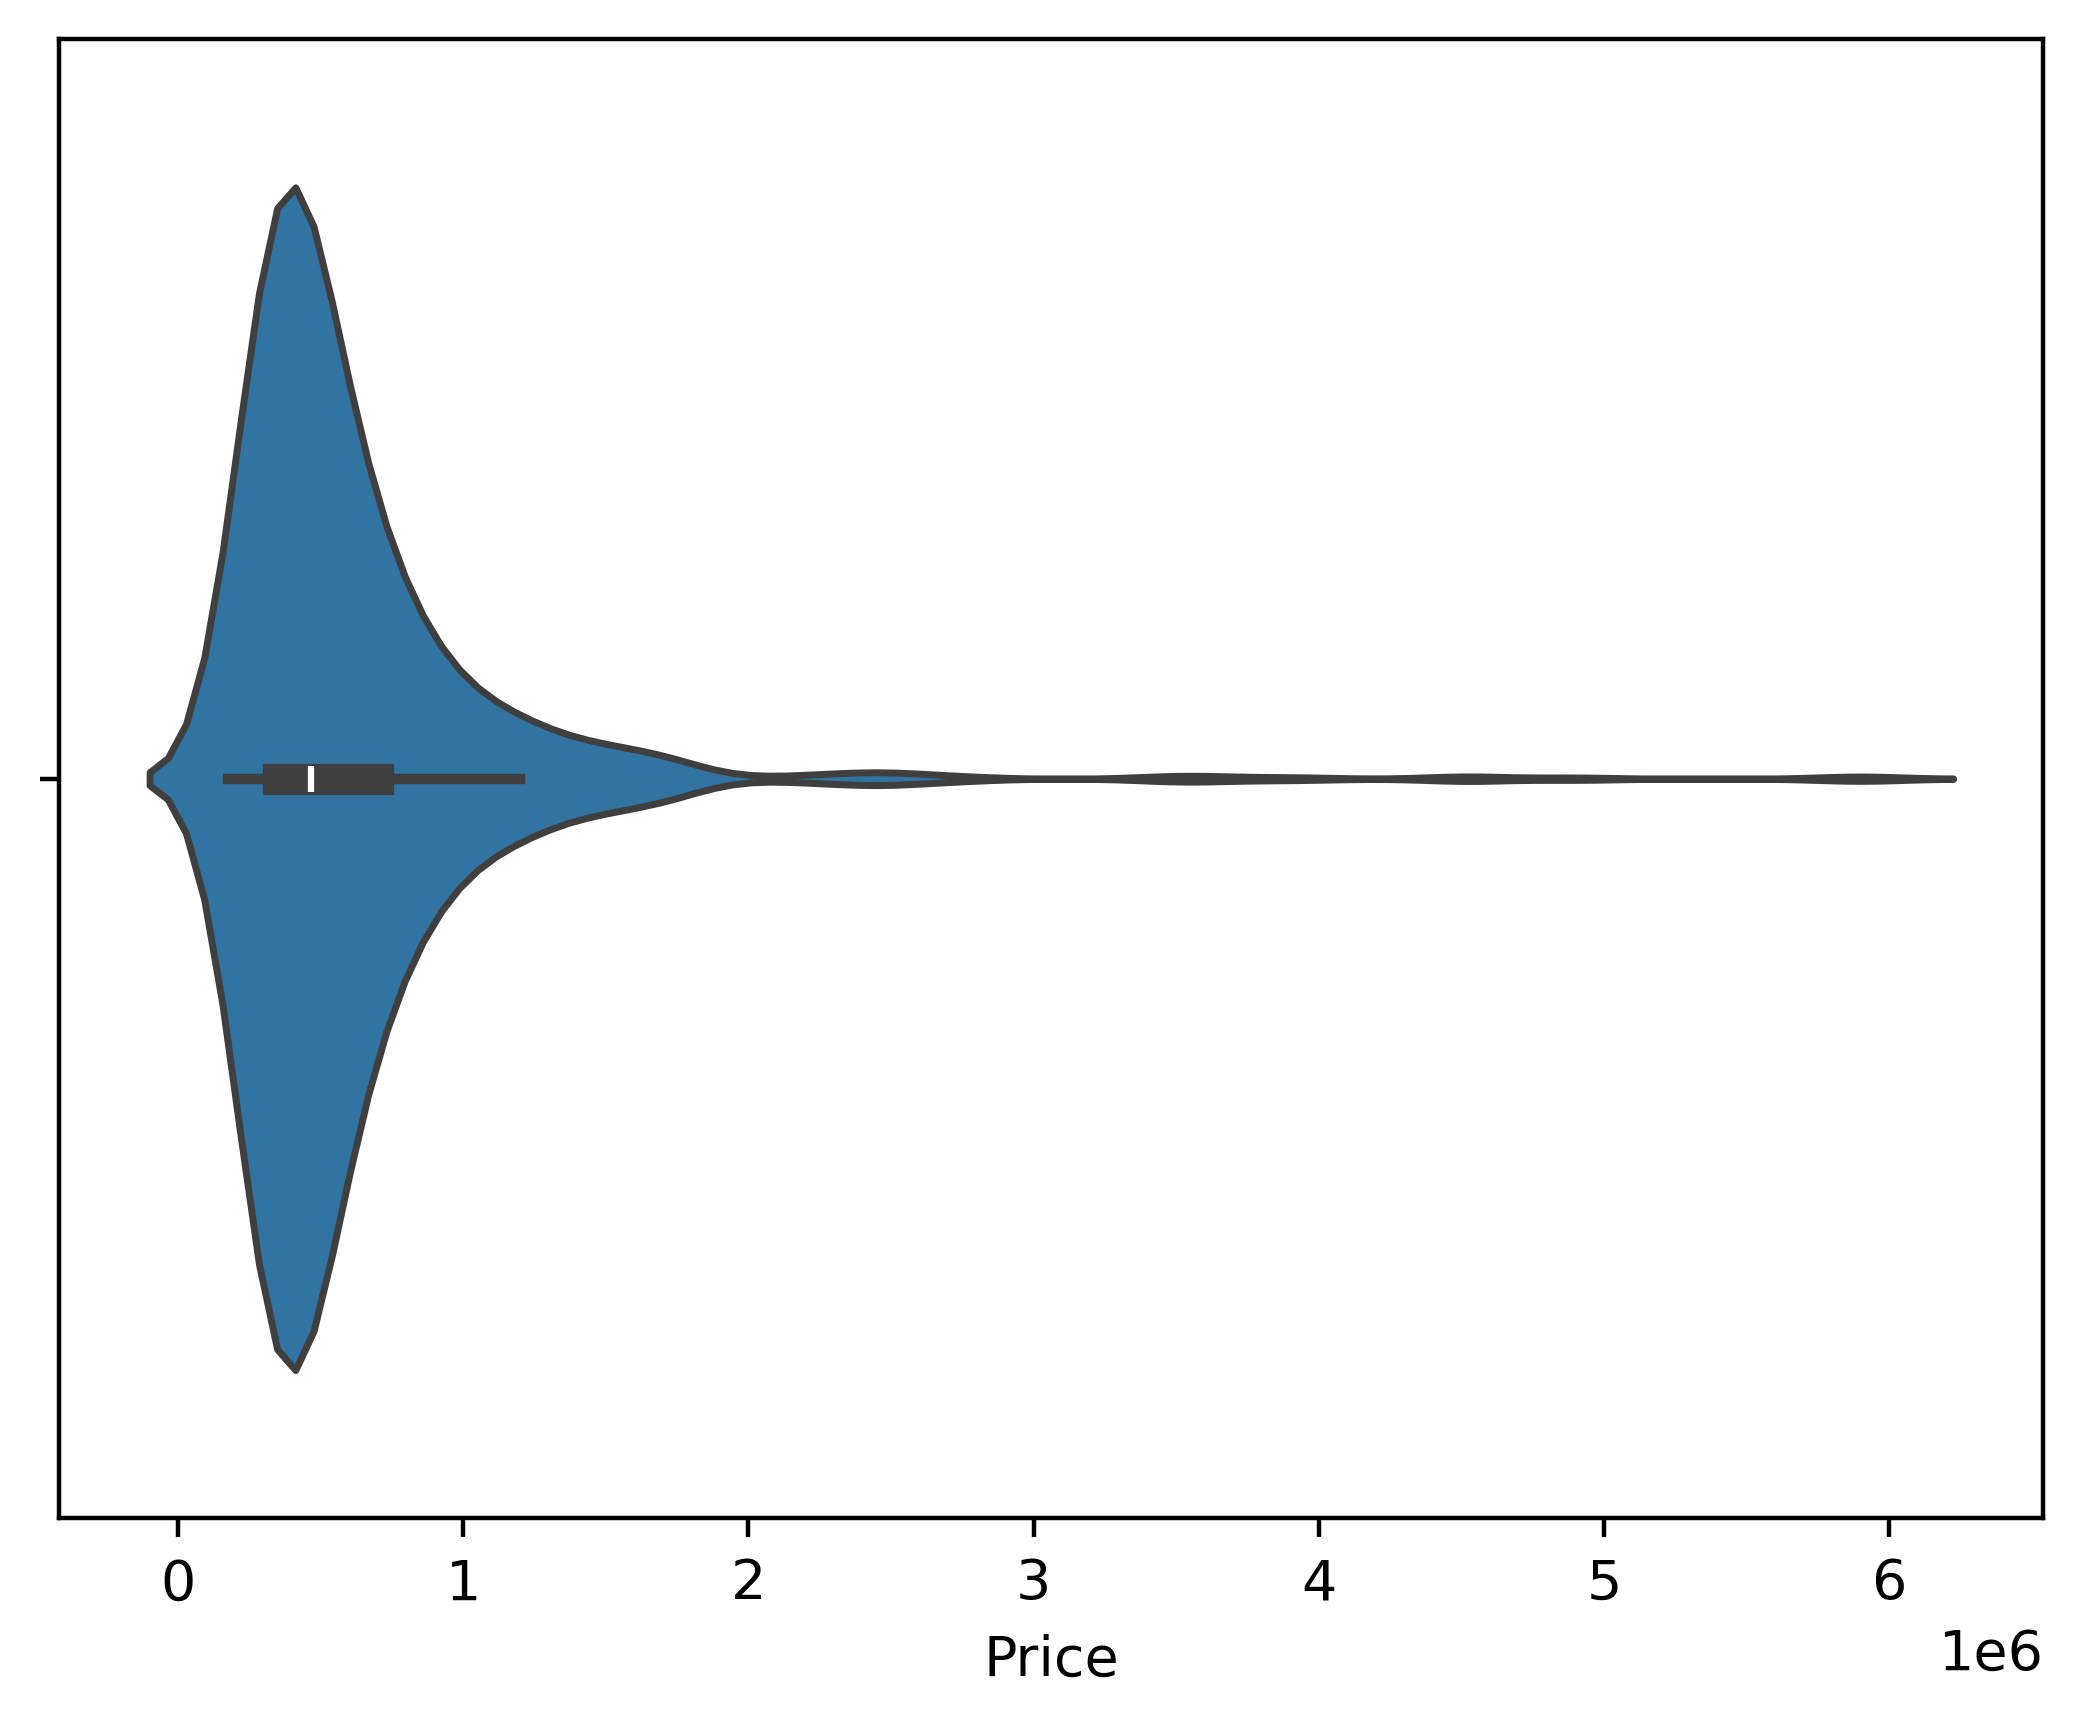

In [29]:
# Phân tích dữ liệu đơn biến dựa vào violin plot
# case 1: basic
sns.violinplot(data = houseprices_data, x= houseprices_data["Price"])

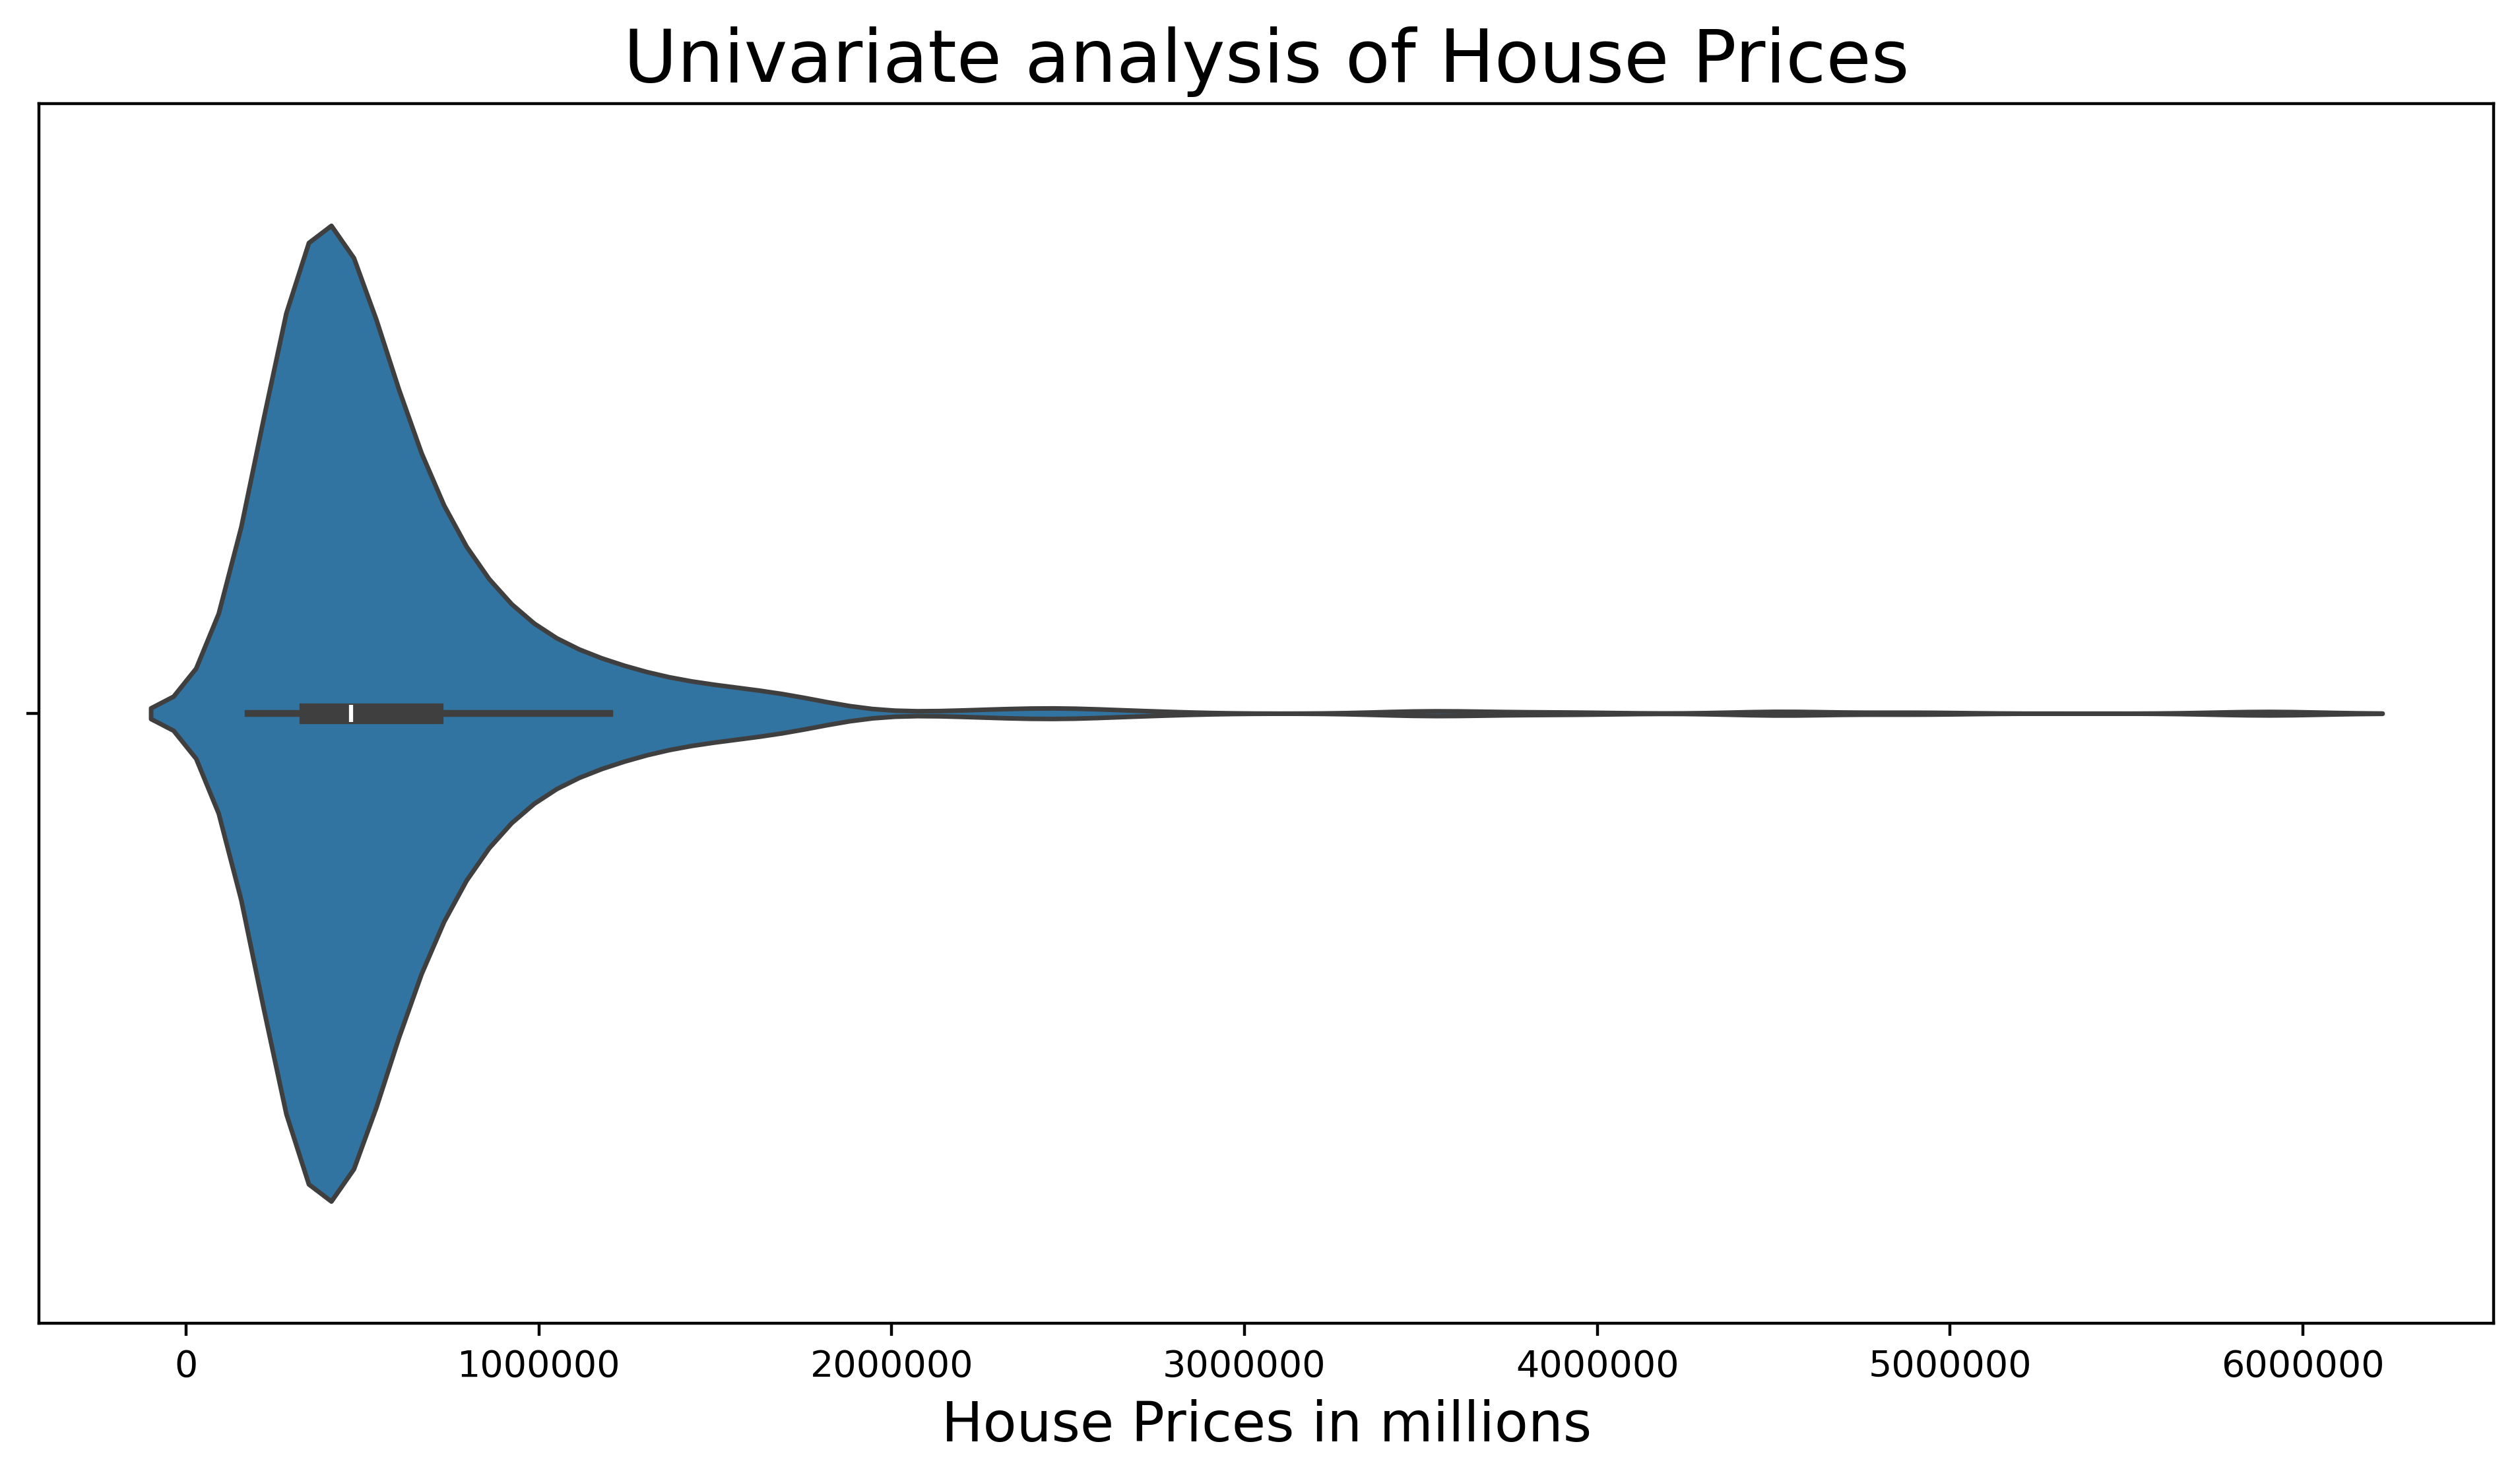

In [30]:
# case 2: advanced
plt.figure(figsize= (12,6))
ax = sns.violinplot(data = houseprices_data, x=houseprices_data["Price"])
ax.set_xlabel('House Prices in millions',fontsize = 15)
ax.set_title('Univariate analysis of House Prices', fontsize= 20)
plt.ticklabel_format(style='plain', axis='x')

In [31]:
# Phân tích dữ liệu đơn biến dựa vào bản tóm tắt dữ liệu
houseprices_data.describe()

,Price,Area,Room
count,9.200000e+02,924.000000,924.000000
mean,6.220654e+05,95.952381,3.571429
std,5.389942e+05,57.447436,1.592332
min,1.750000e+05,21.000000,1.000000
25%,3.500000e+05,60.750000,3.000000
50%,4.670000e+05,83.000000,3.000000
75%,7.000000e+05,113.000000,4.000000
max,5.950000e+06,623.000000,14.000000


### Bài toán 2

#### Nhiệm vụ 1: phân tích dữ liệu hai biến trên dữ liệu về chim cánh cụt

In [44]:
# Import thư viện và chuẩn bị dữ liệu phân tích
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
penguins_data = pd.read_csv("Data/penguins_size.csv")
penguins_data = penguins_data[['species','culmen_length_mm','body_mass_g','sex']]

<Axes: xlabel='culmen_length_mm', ylabel='body_mass_g'>

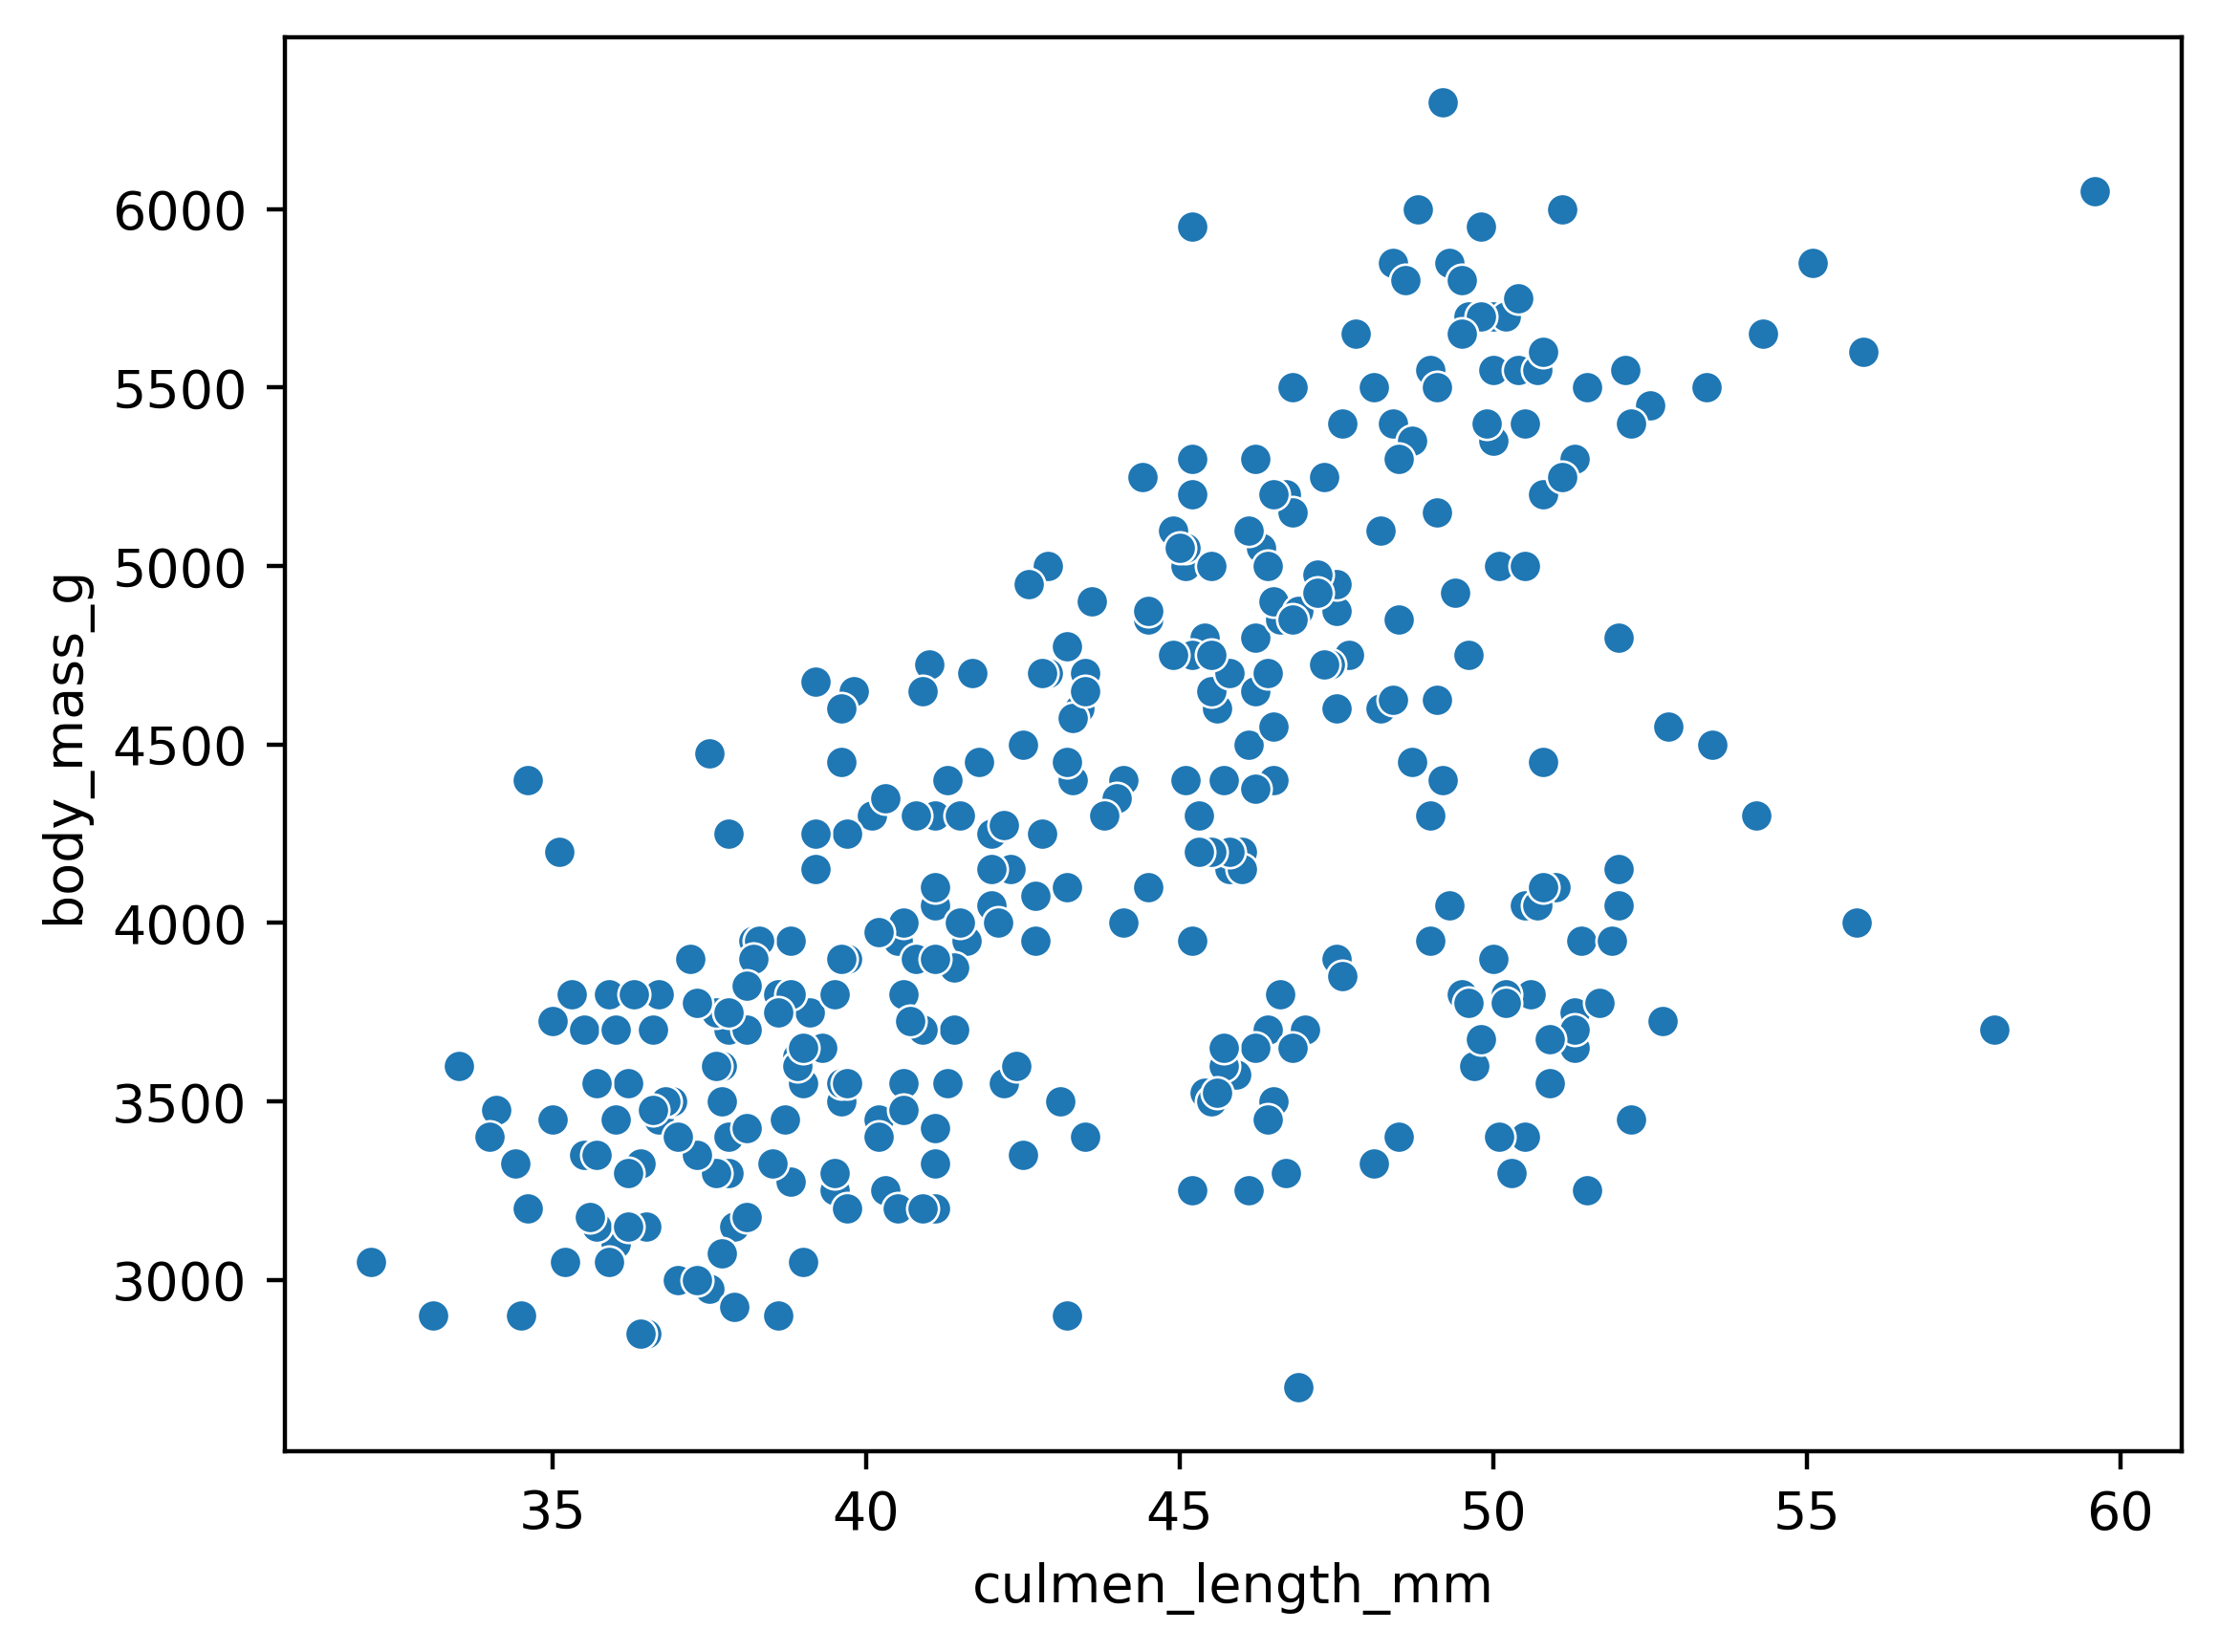

In [45]:
# Phân tích dữ liệu 2 biến dựa vào phương pháp scatterplot
# case 1: basic
sns.scatterplot(data = penguins_data, x= penguins_data["culmen_length_mm"], y= penguins_data['body_mass_g'])

Text(0.5, 1.0, 'Bivariate analysis of Culmen Length and body mass')

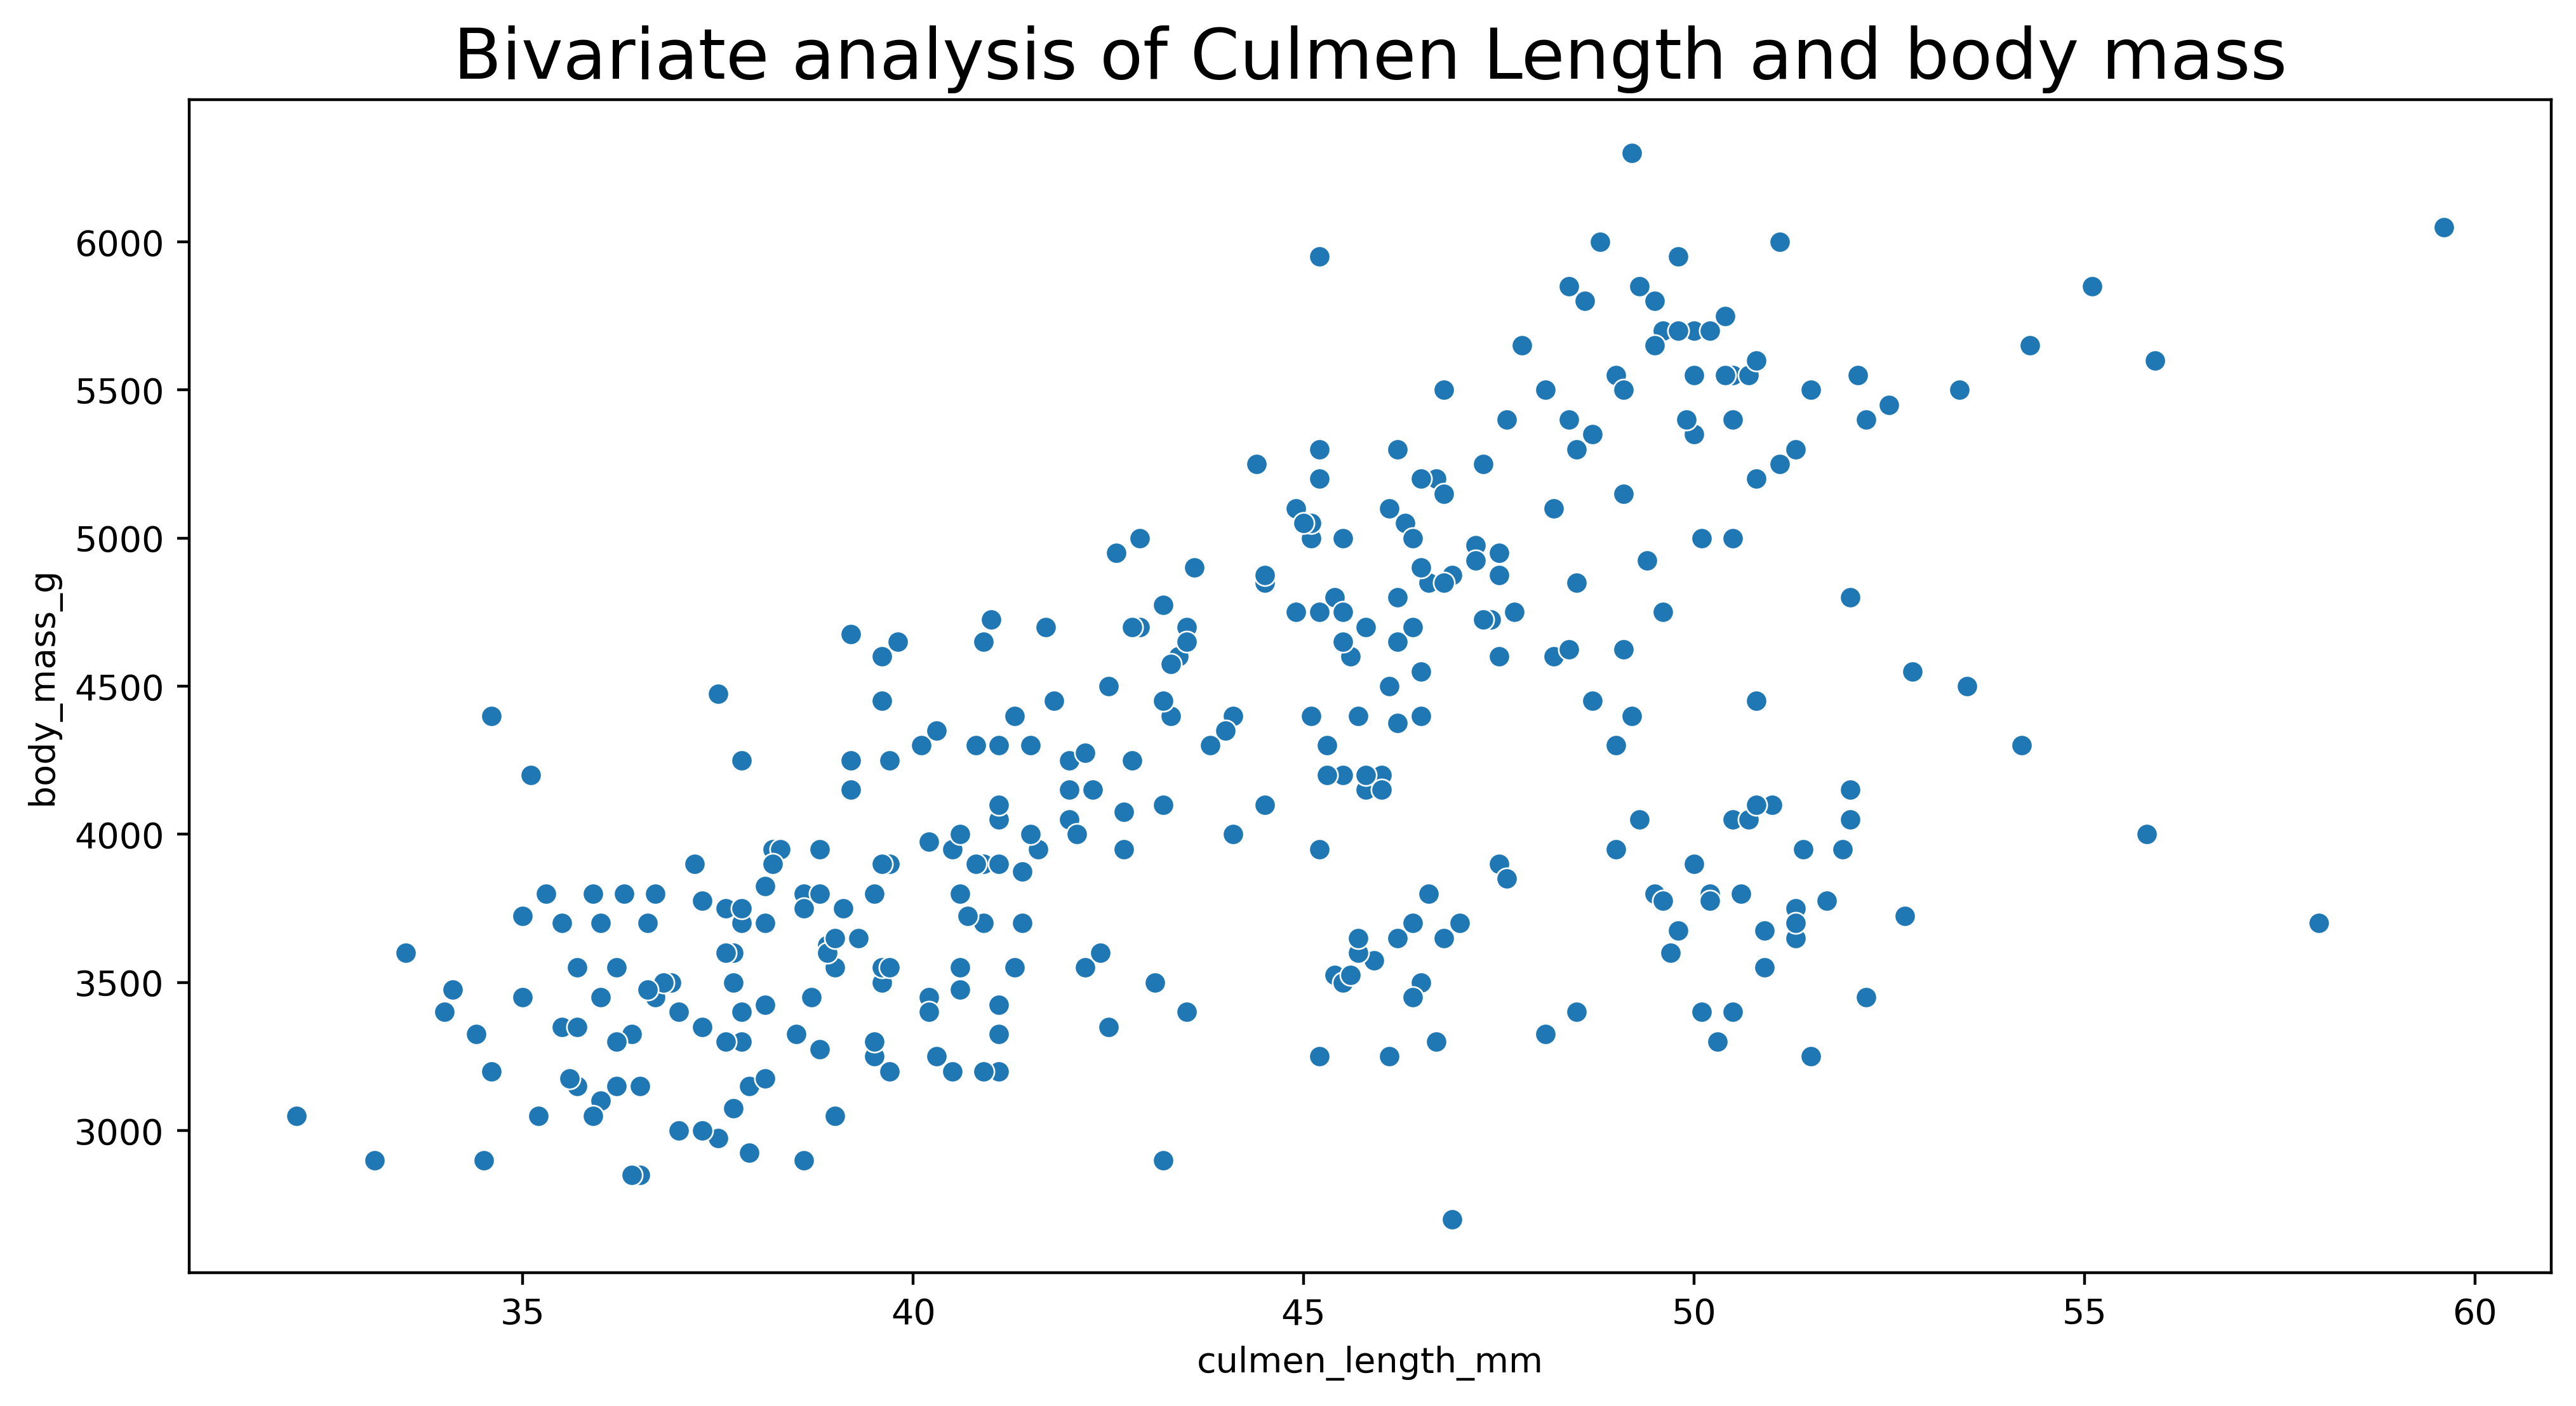

In [48]:
# case 2: advanced
plt.figure(figsize= (12,6))
ax = sns.scatterplot(data = penguins_data, x= penguins_data["culmen_length_mm"], y= penguins_data['body_mass_g'])
ax.set_title('Bivariate analysis of Culmen Length and body mass', fontsize=20)

In [43]:
# Phân tích 2 biến dựa vào bảng crosstab/two-way
pd.crosstab(index= penguins_data['species'], columns= penguins_data['sex'])

sex,.,FEMALE,MALE
species,,,
Adelie,0,73,73
Chinstrap,0,34,34
Gentoo,1,58,61


In [46]:
# Phân tích 2 biến sử dụng pivot_table
pd.pivot_table(penguins_data, values='culmen_length_mm', index='species', aggfunc=np.mean)

,culmen_length_mm
species,
Adelie,38.791391
Chinstrap,48.833824
Gentoo,47.504878


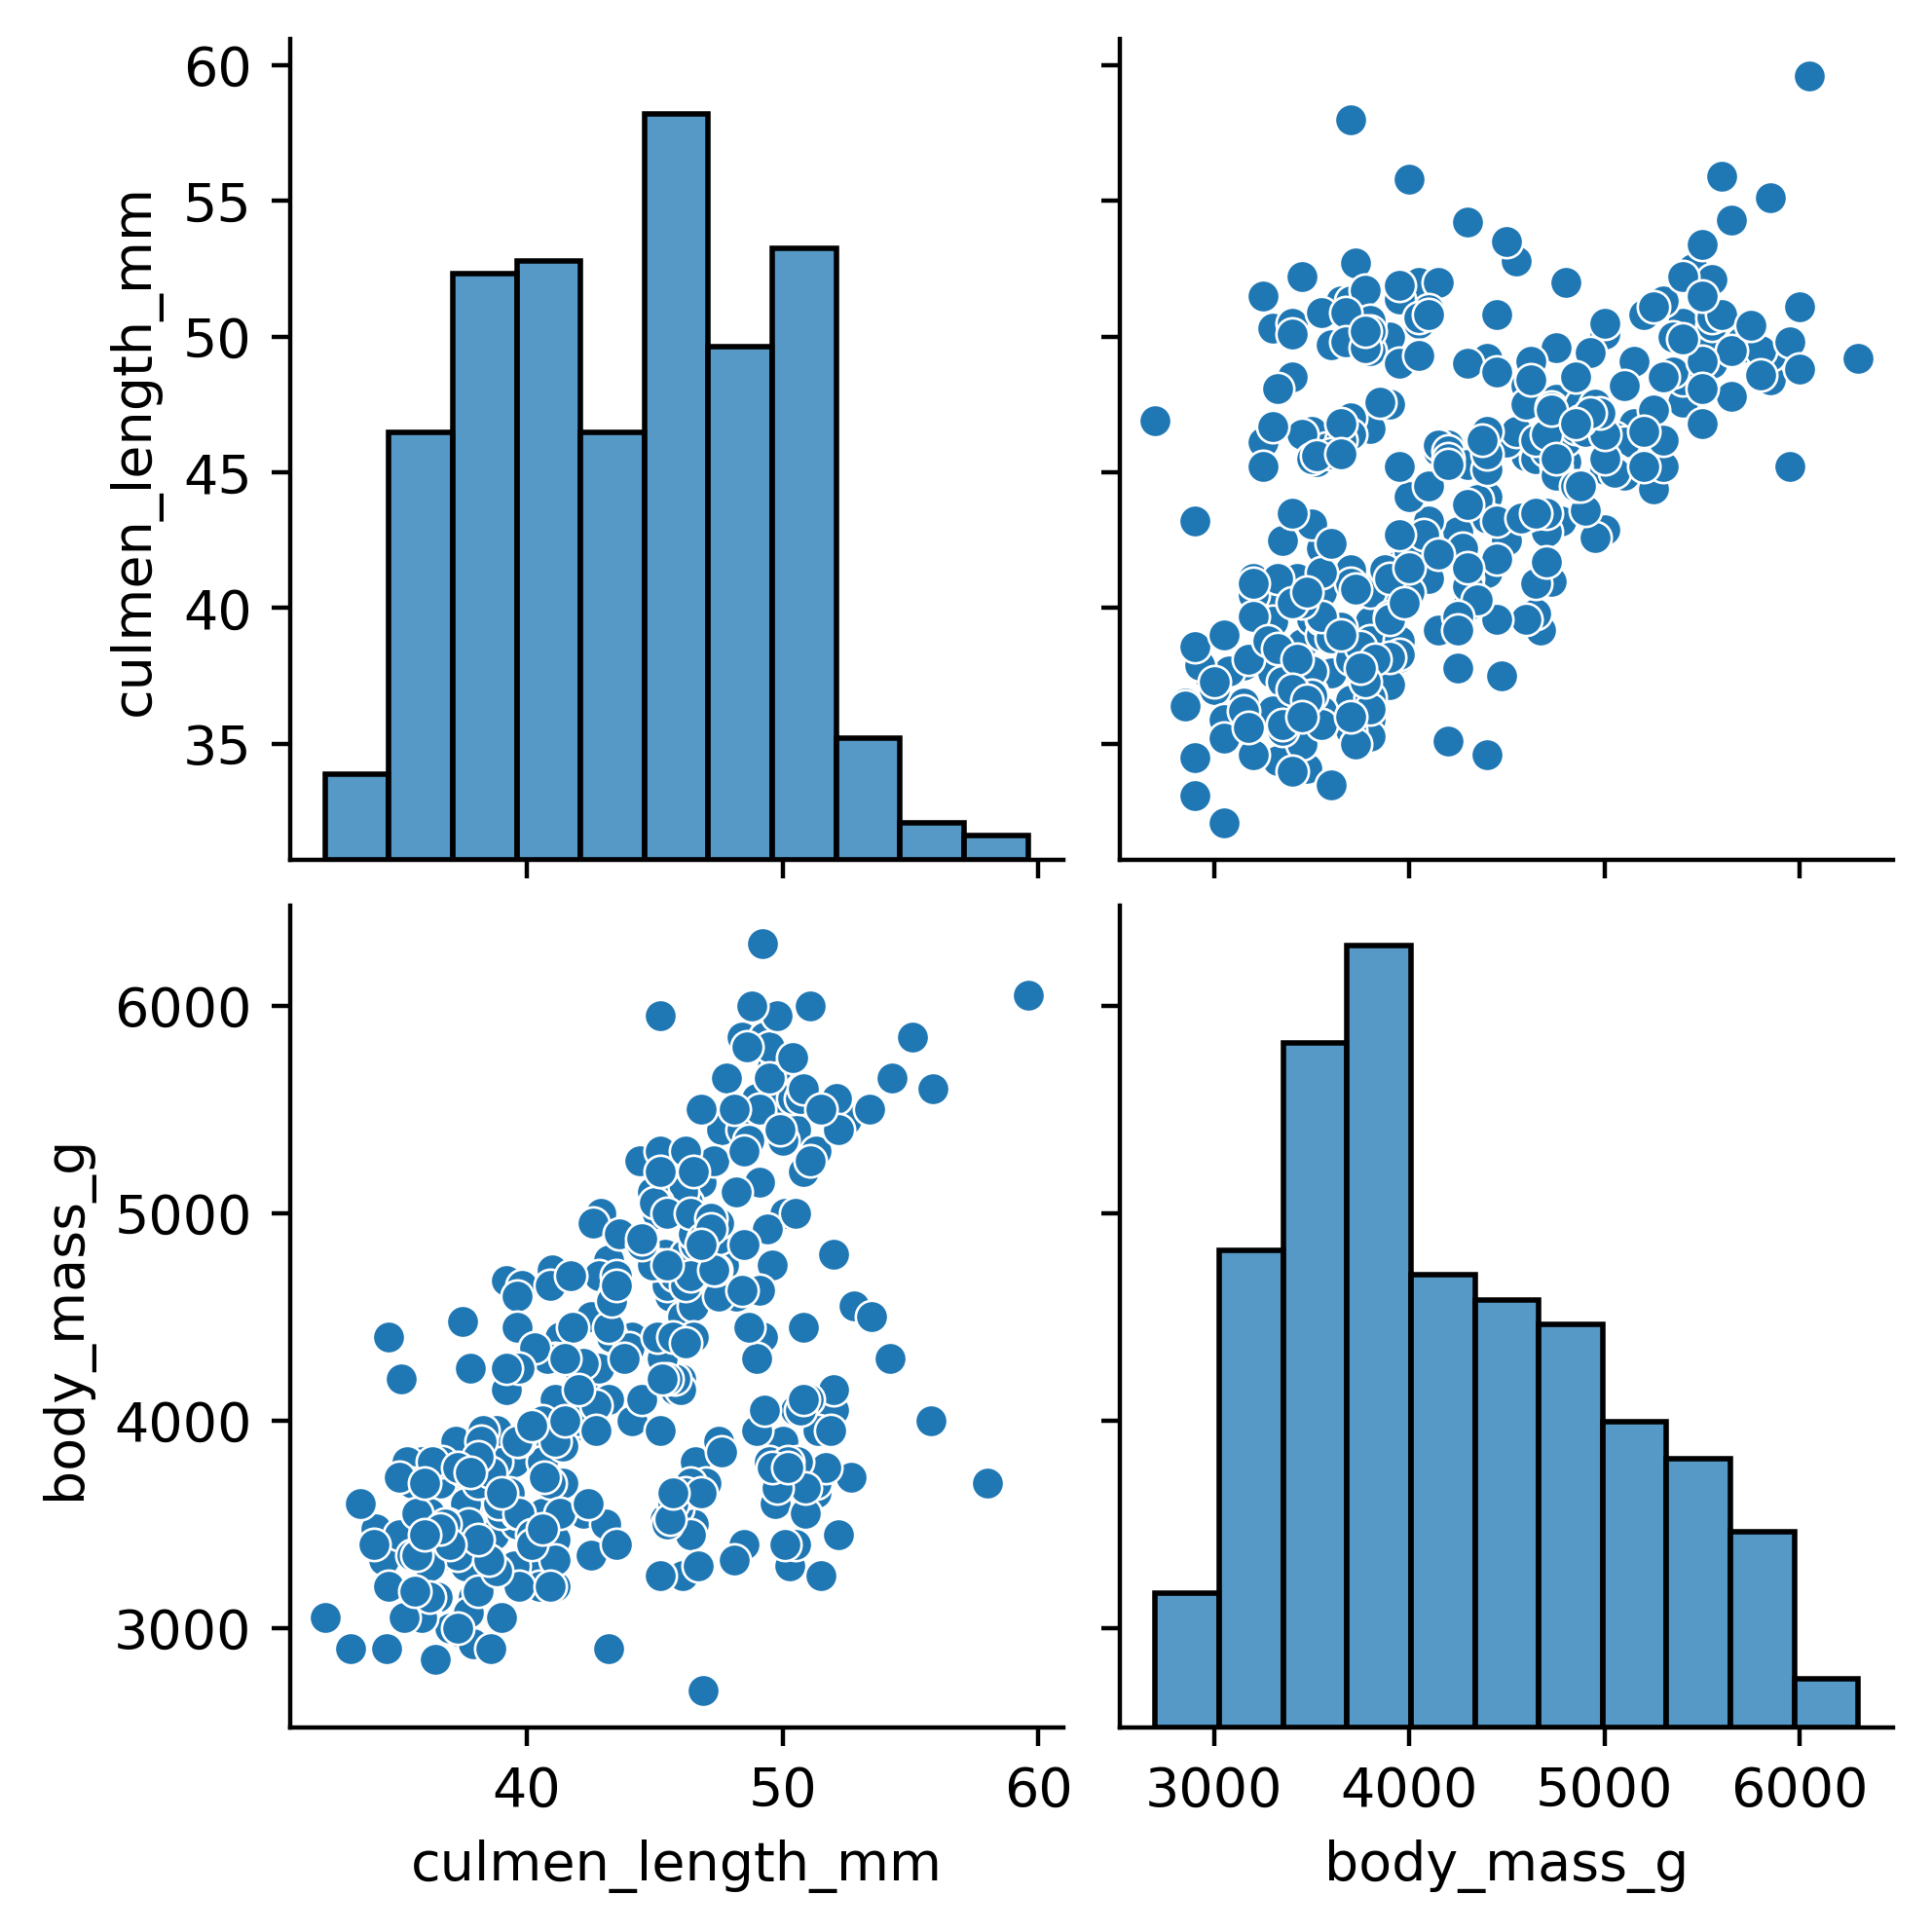

In [47]:
# Phân tích 2 biến sử dụng pairplot
import seaborn as sns
sns.pairplot(data = penguins_data)

### Bài toán 3

#### Nhiệm vụ 1: Sử dụng pandas profiling trên dữ liệu Customer Personality Analysis

In [ ]:
# Cài đặt thư viện ydata-profiling
# !pip install ydata-profiling

In [2]:
import pandas as pd
from ydata_profiling import ProfileReport
marketing_data = pd.read_csv("Data/marketing_campaign.csv", sep='\t')
# Create an Automated EDA report using the ProfileReport class in the ydata_profiling library.
# Use the to_file method to output the report to an HTML file
profile = ProfileReport(marketing_data)
profile.to_file("Reports/profile_output.html")
# Sau khi hoàn thành ta có thể mở file "profile_output.html" để thực hiện EDA

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 29/29 [00:00<00:00, 519.82it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#### Nhiệm vụ 2: Sử dụng dtale trên dữ liệu Marketing Campaign

In [8]:
# Cài đặt thư viện dtale
# !pip install dtale

# Import thư viện cần thiết
import pandas as pd
import dtale

# Đọc file dữ liệu
marketing_data = pd.read_csv("Data/marketing_campaign.csv", sep='\t')

# Mở giao diện D-Tale trực tiếp trong Jupyter Lab
dtale.show(marketing_data)

### Bài tập thực hành 1

In [6]:
# Cài đặt thư viện SweetViz 
# !pip install sweetviz

import os
import pandas as pd
import sweetviz as sv #Bản sweetviz được sử dụng là sweetviz-cb tạo ra từ bản gốc để tương thích các phiên bản numpy/python mới hơn

# Đọc dữ liệu
df = pd.read_csv("Data/marketing_campaign.csv", sep='\t')

# Data không có biến target, dùng mặc định
report = sv.analyze(df)

# Xuất báo cáo ra HTML
report.show_html("Reports/sweetviz_report.html")

                                             |                                             | [  0%]   00:00 ->…

Report Reports/sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.



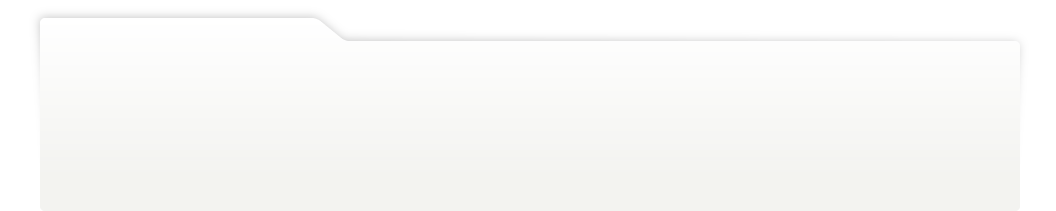
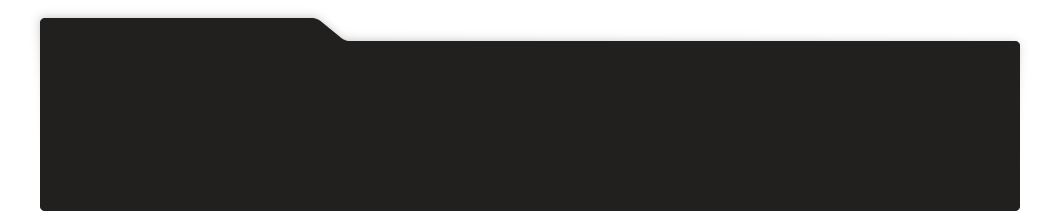
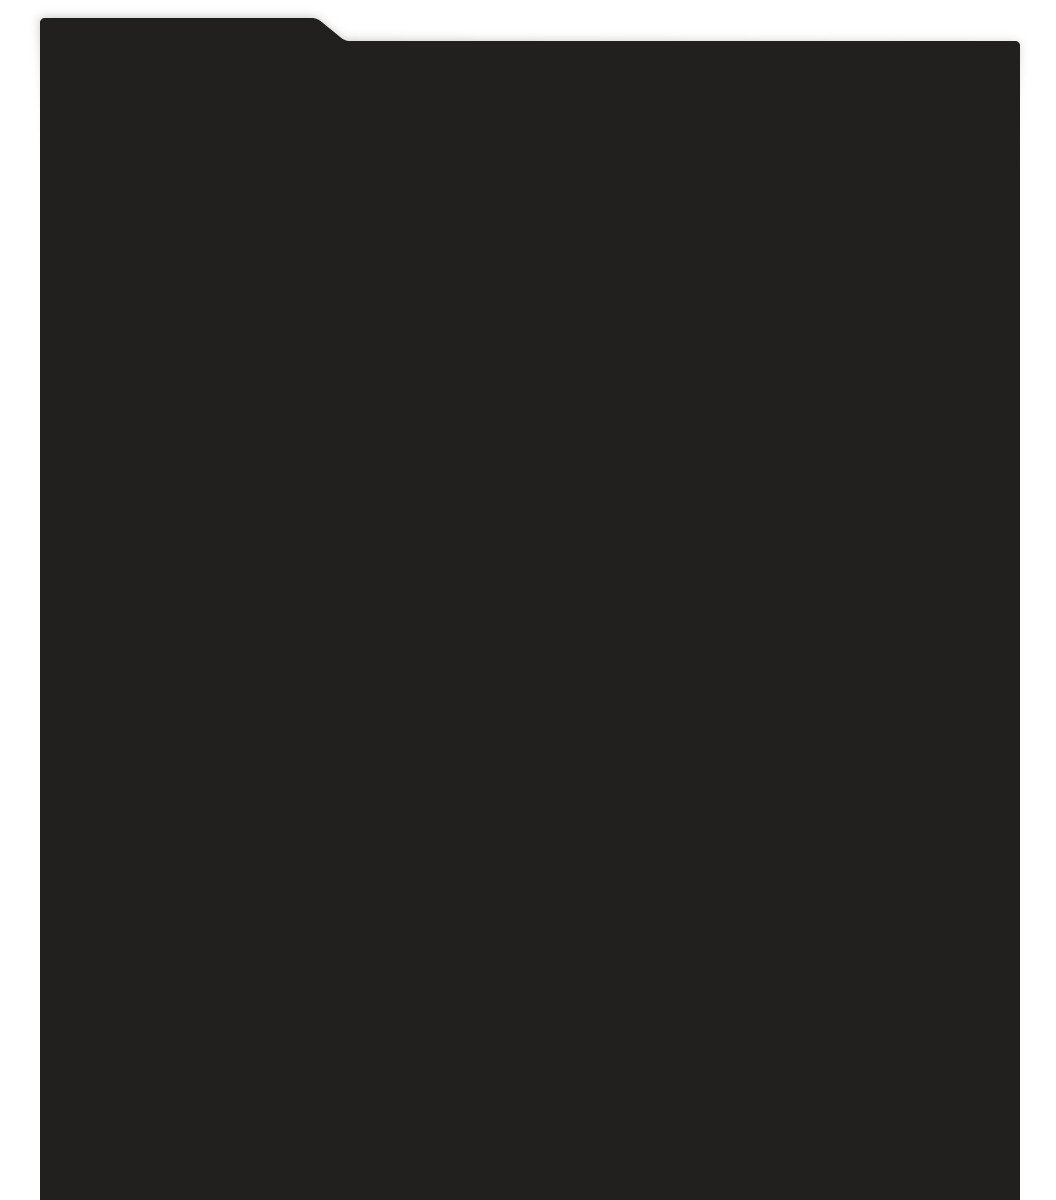
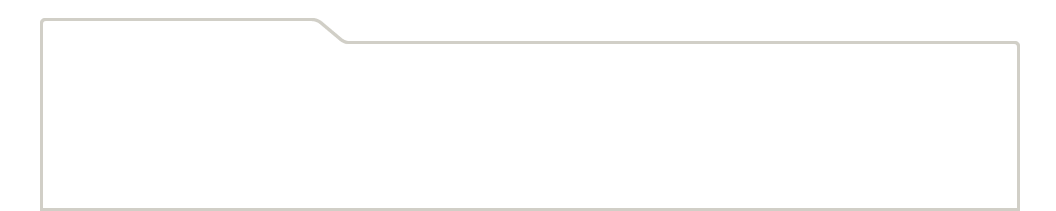
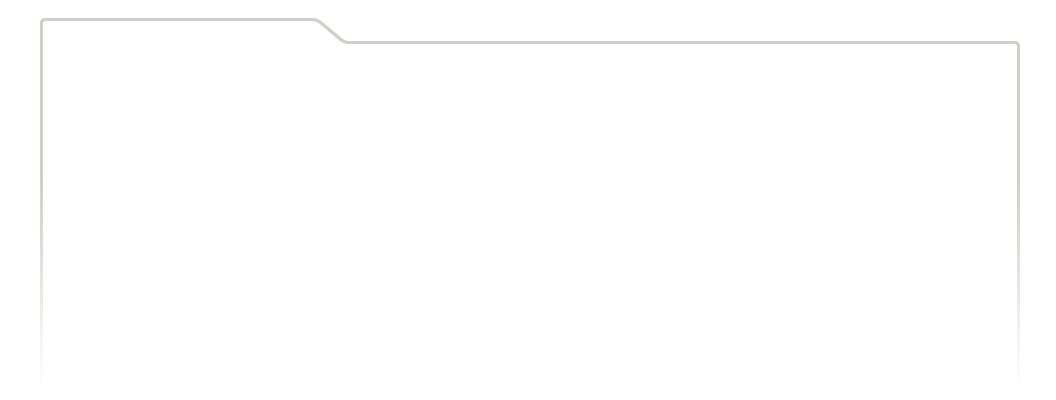
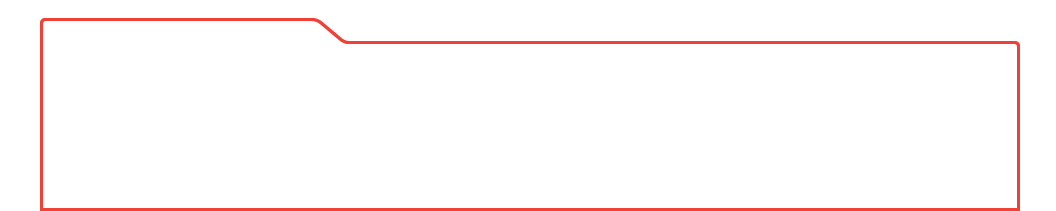
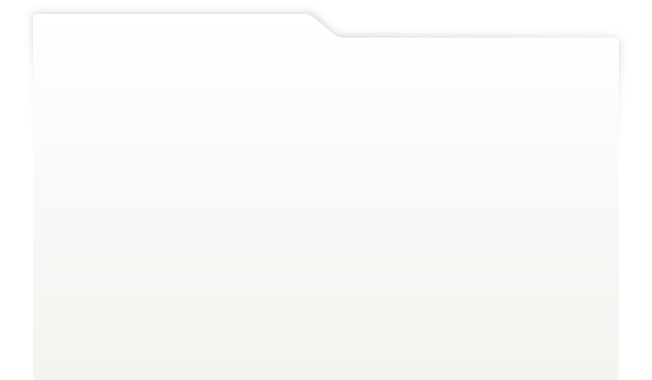
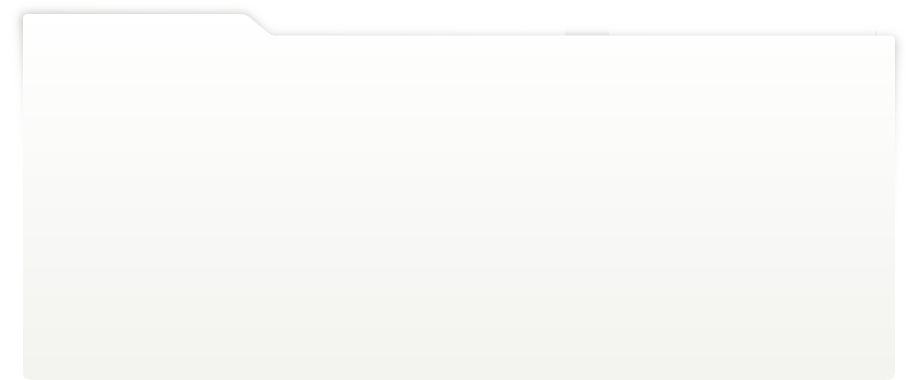
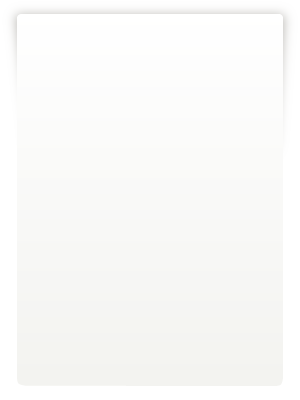
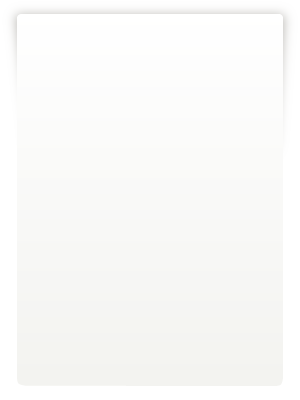
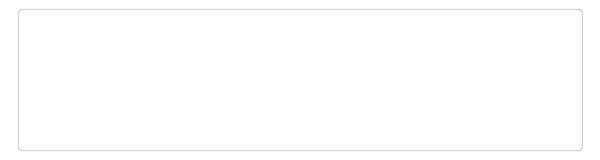
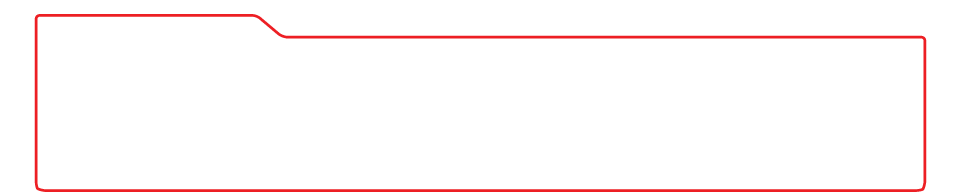
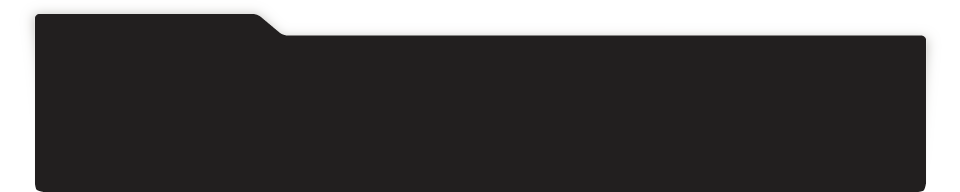
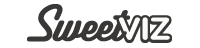
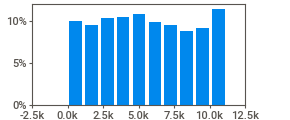
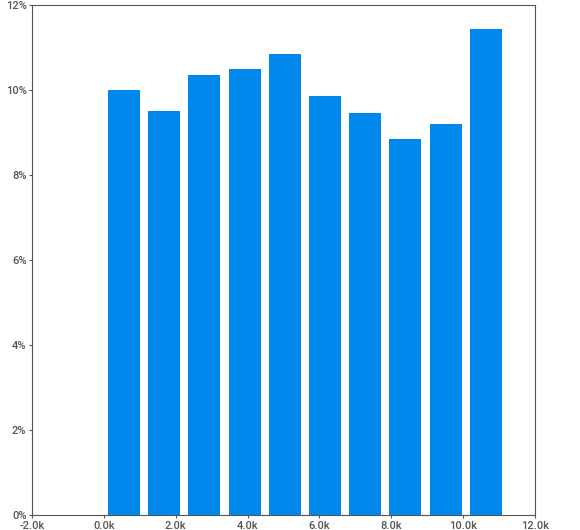
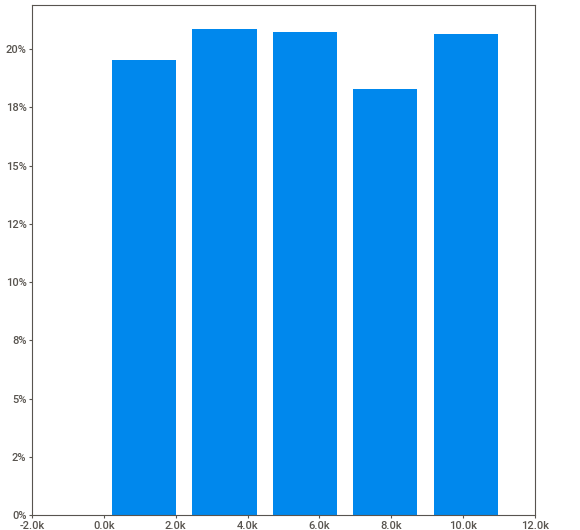
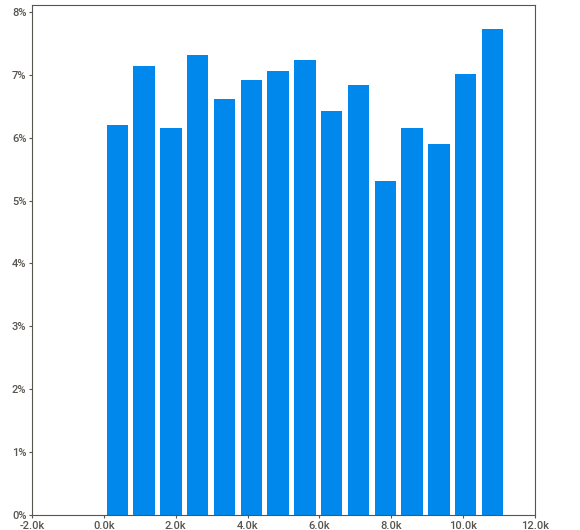
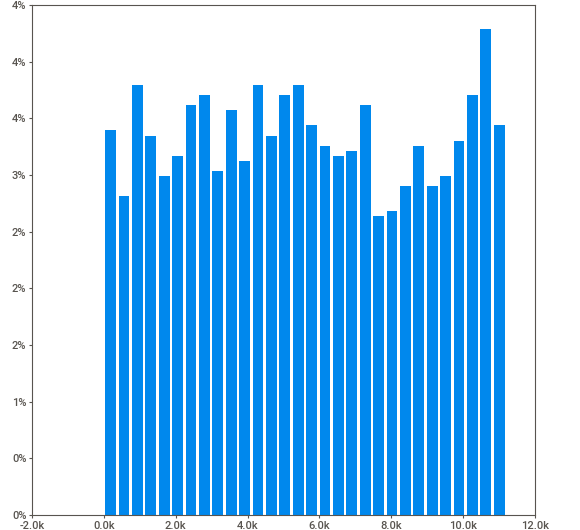
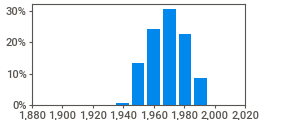
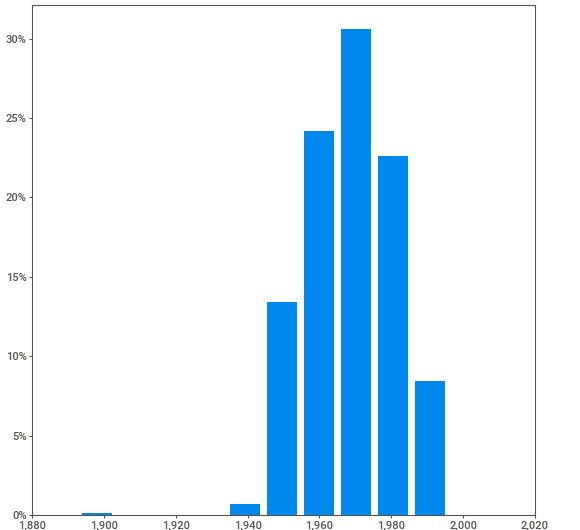
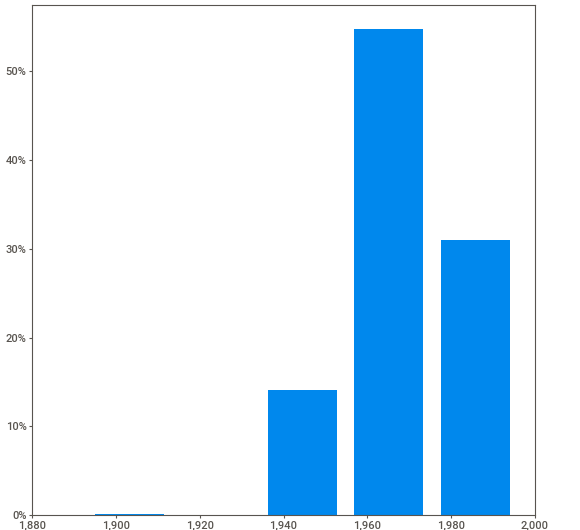
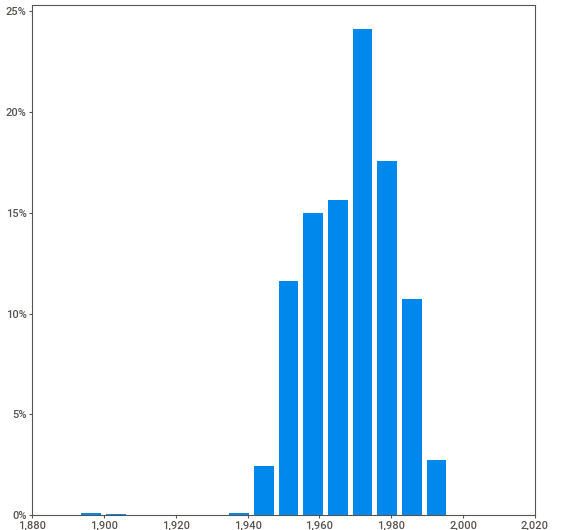
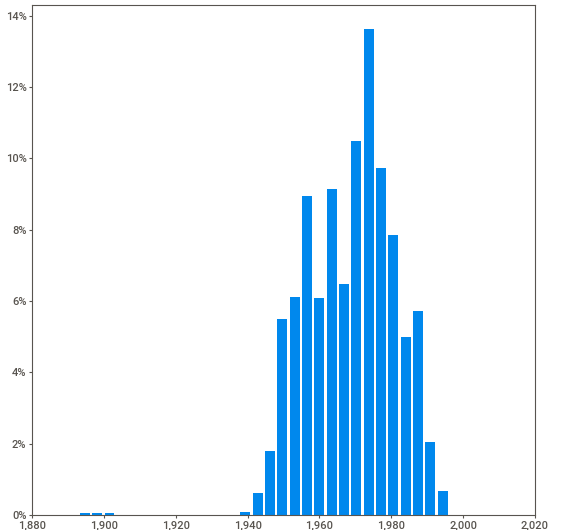
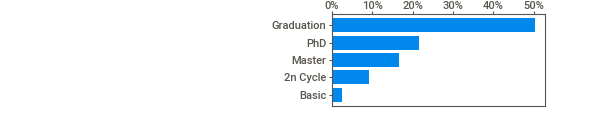
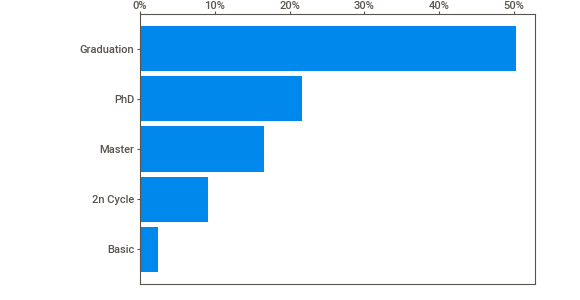
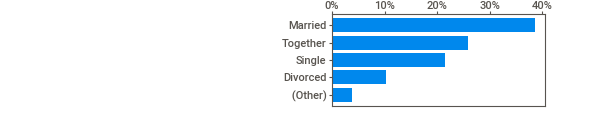
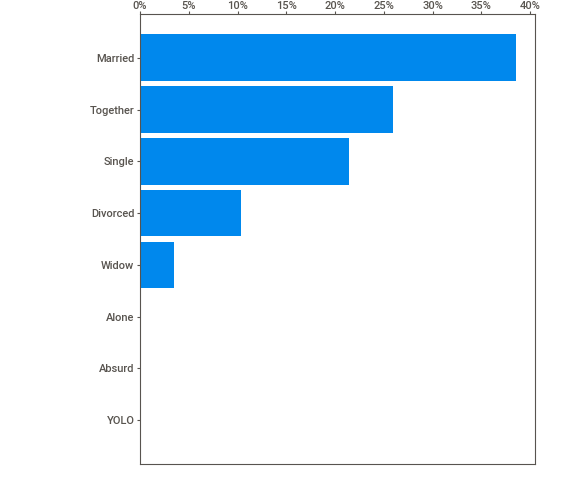
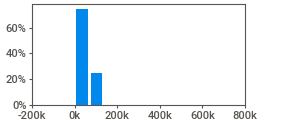
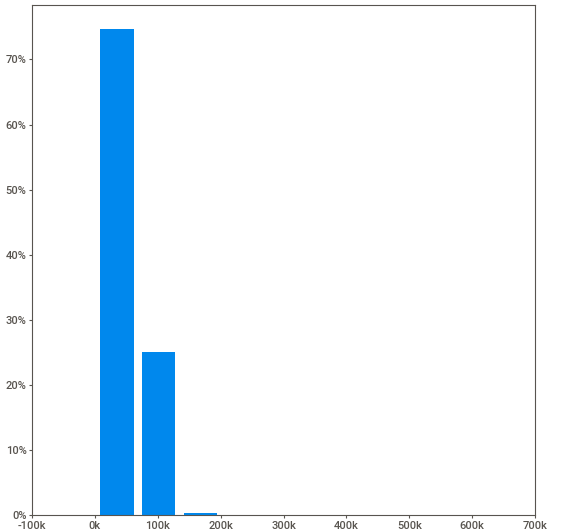
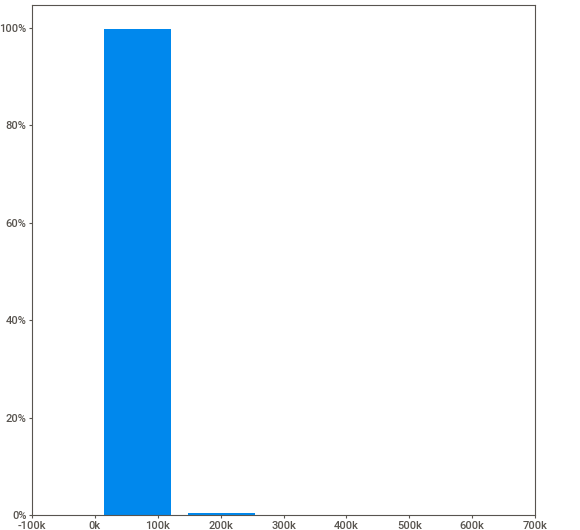
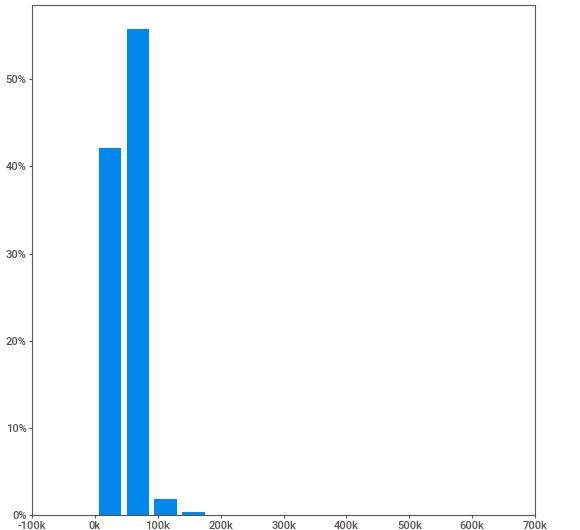
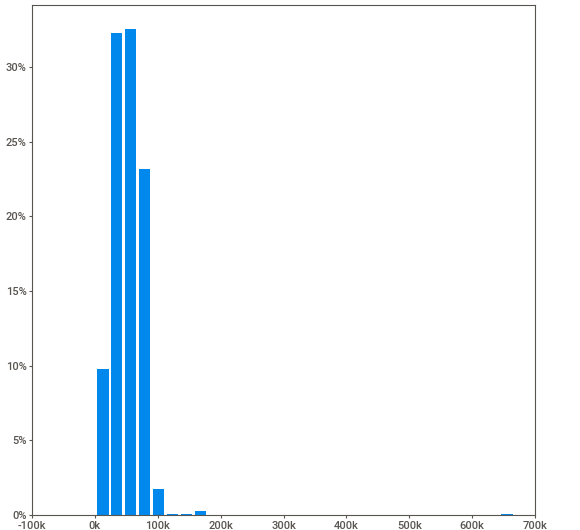
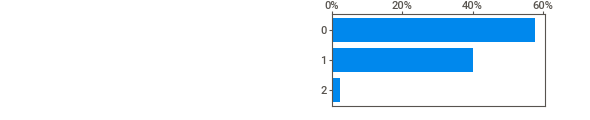
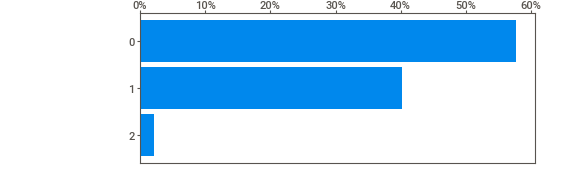
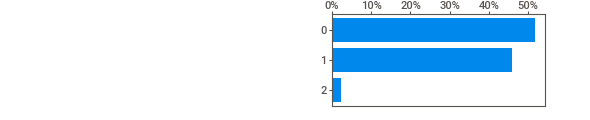
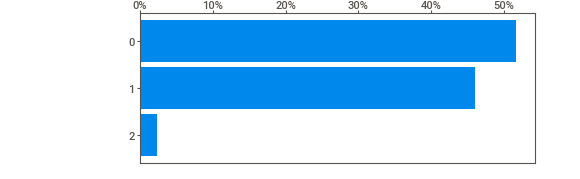
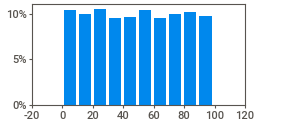
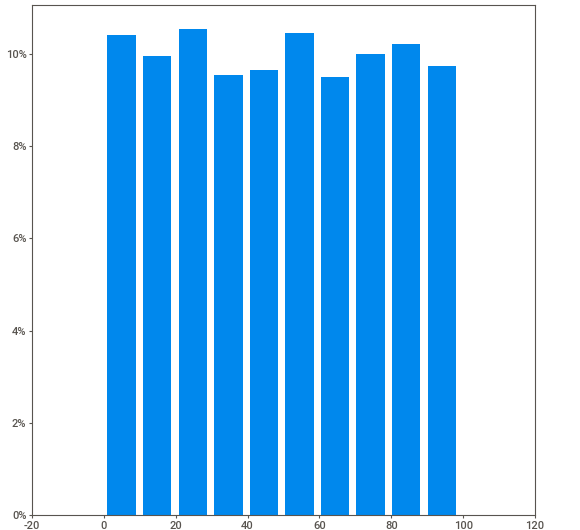
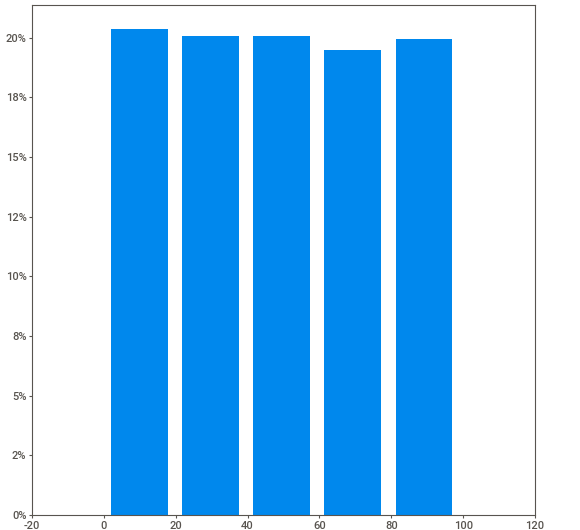
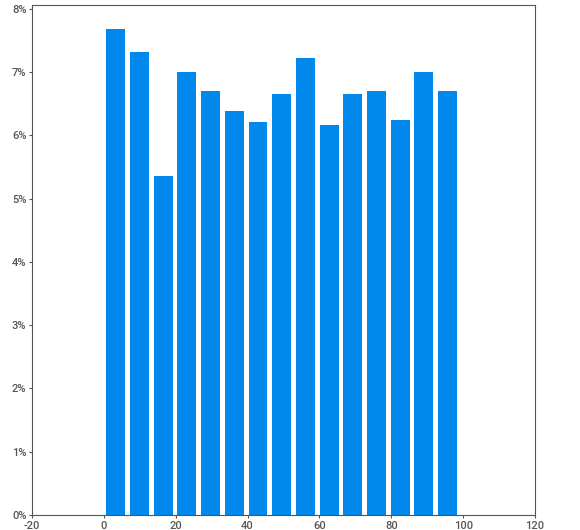
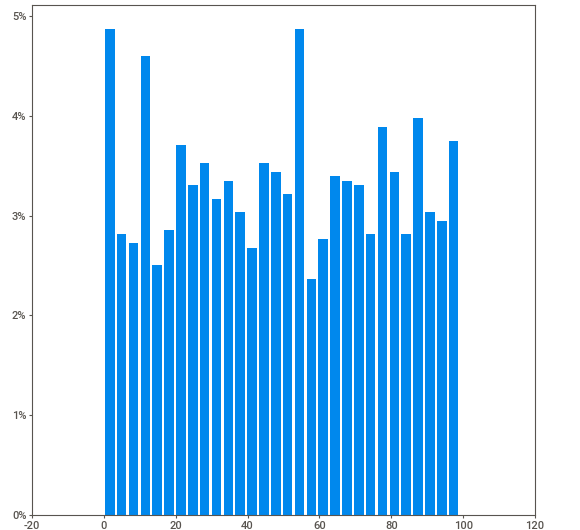
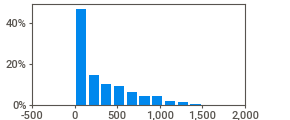
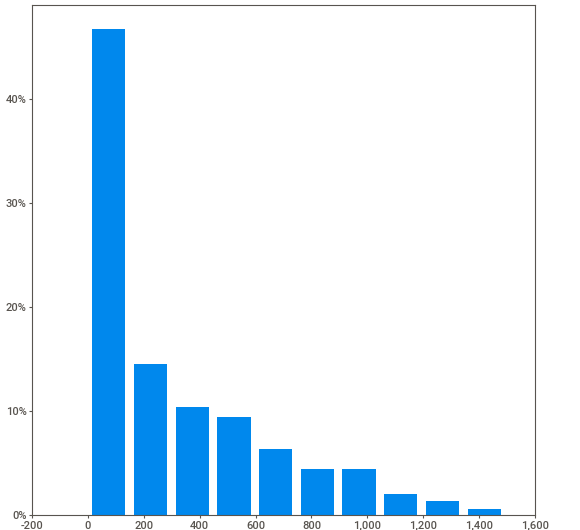
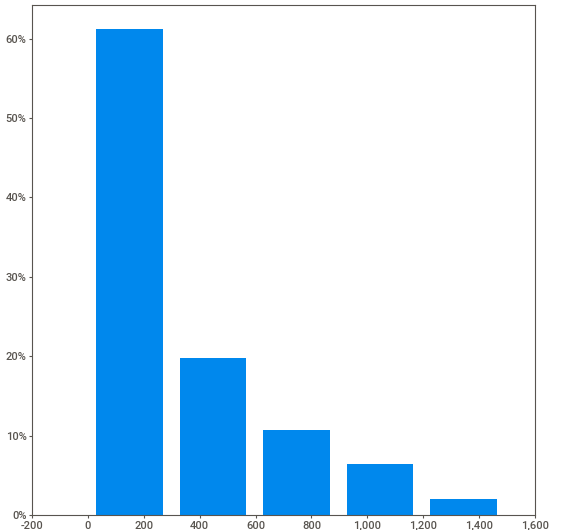
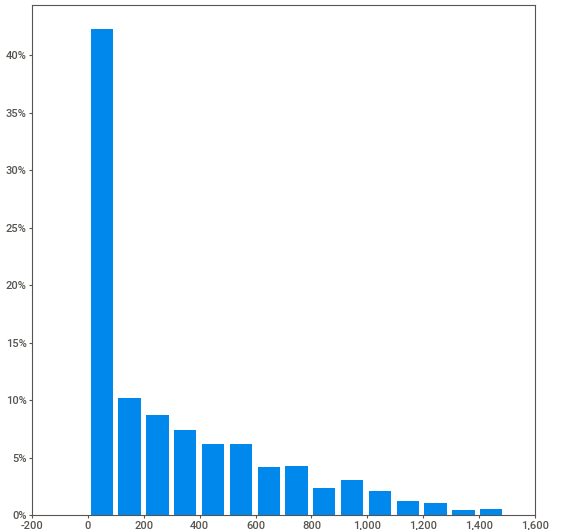
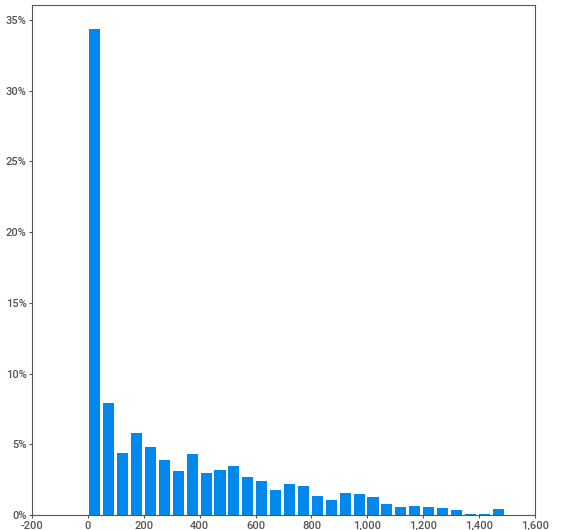
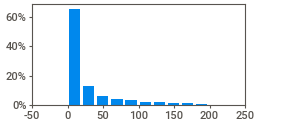
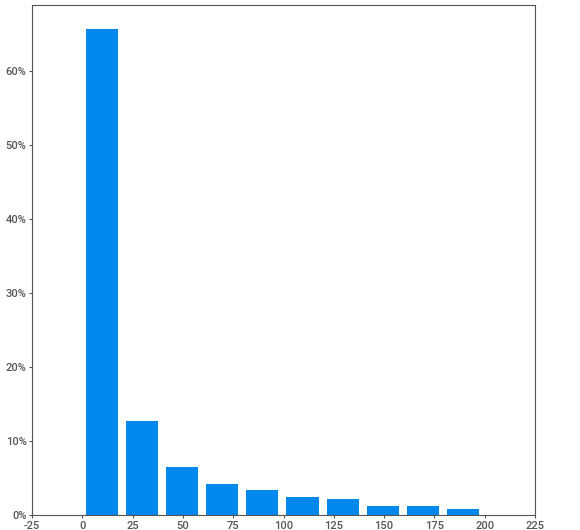
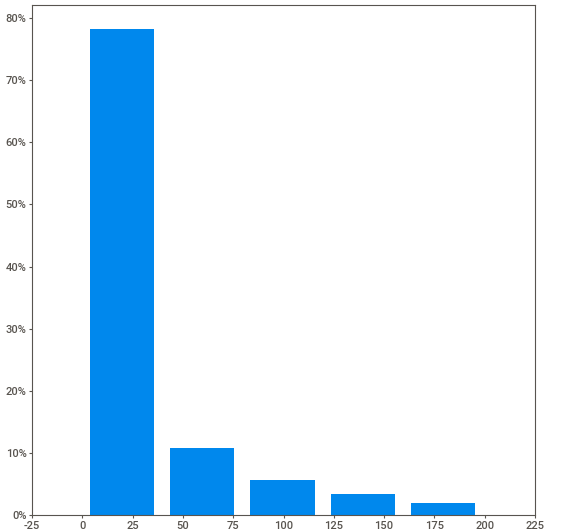
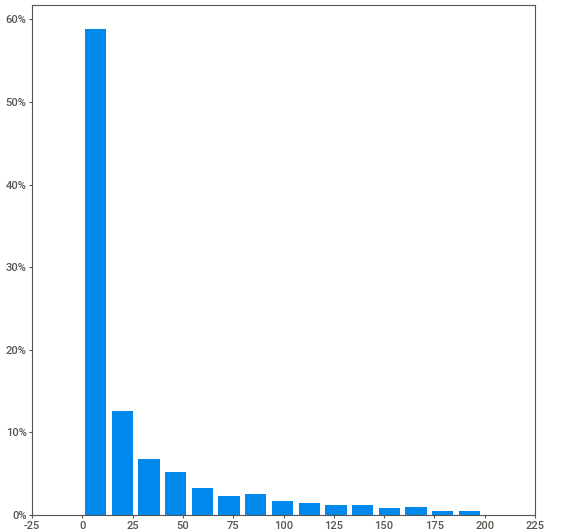
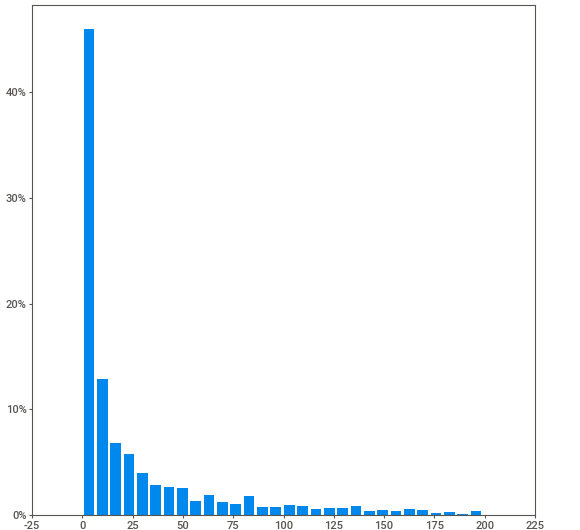
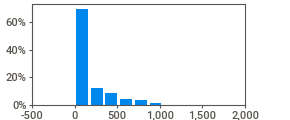
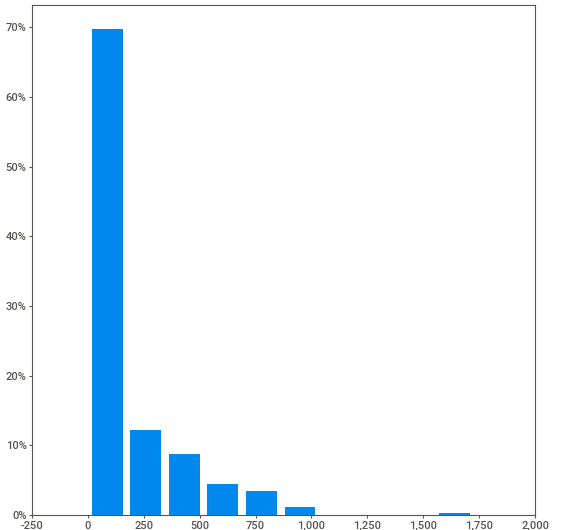
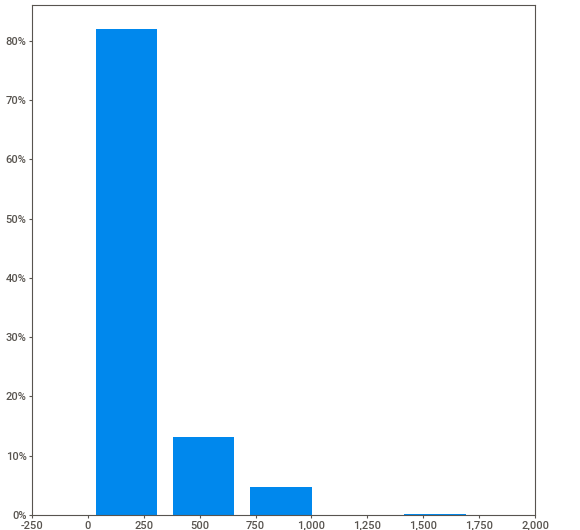
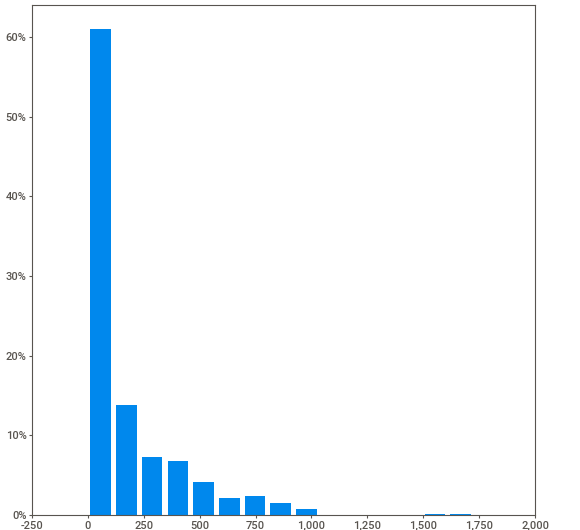
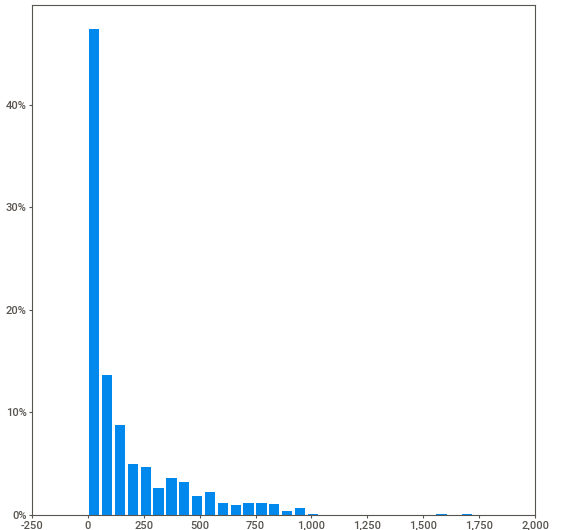
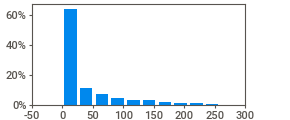
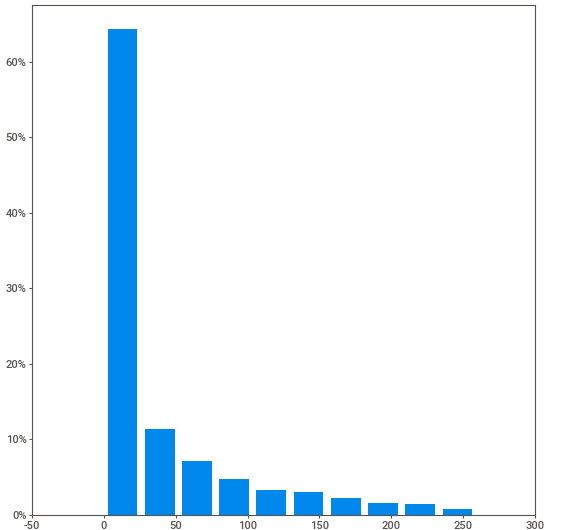
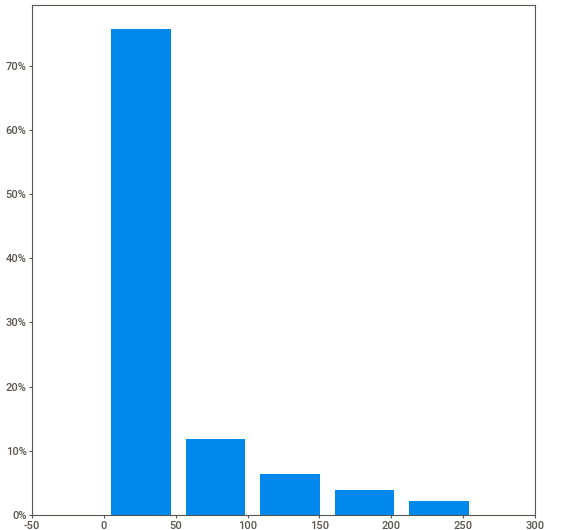
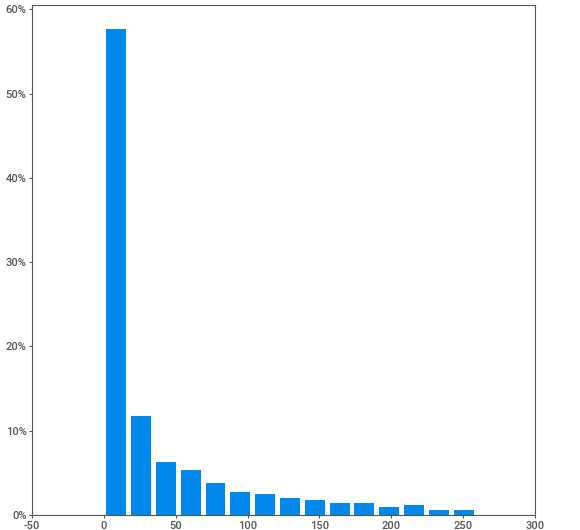
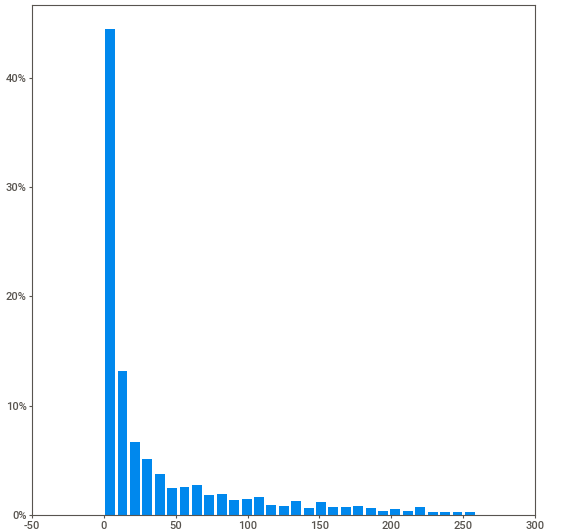
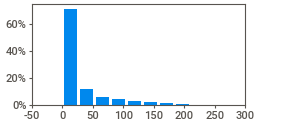
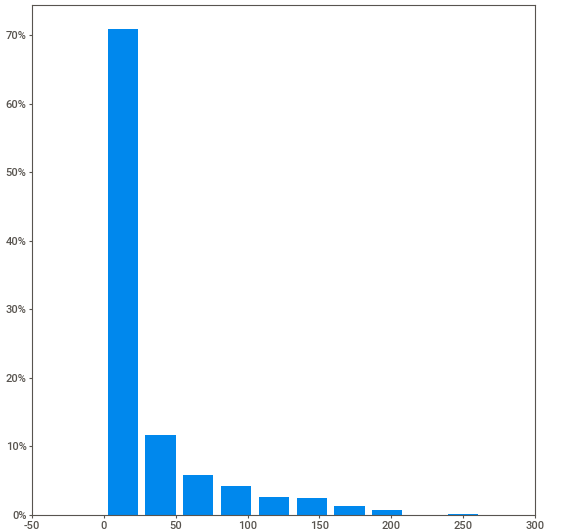
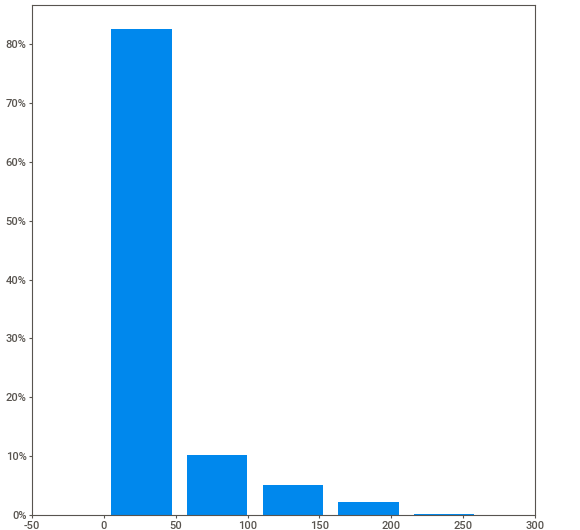
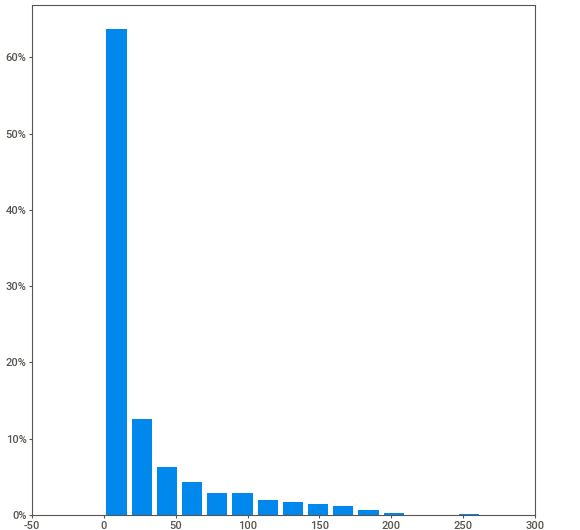
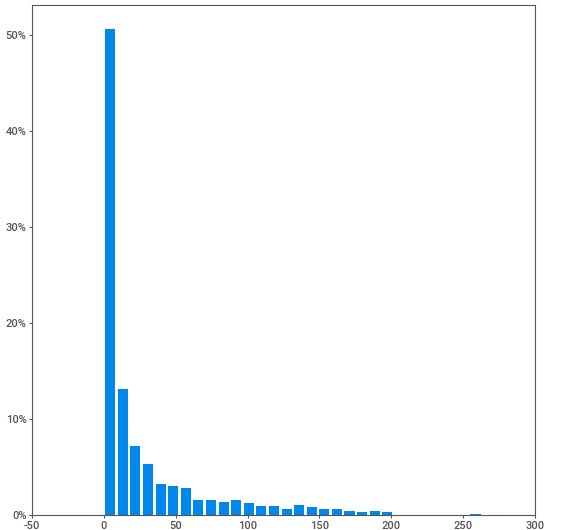
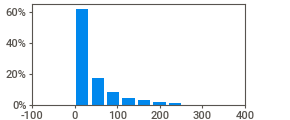
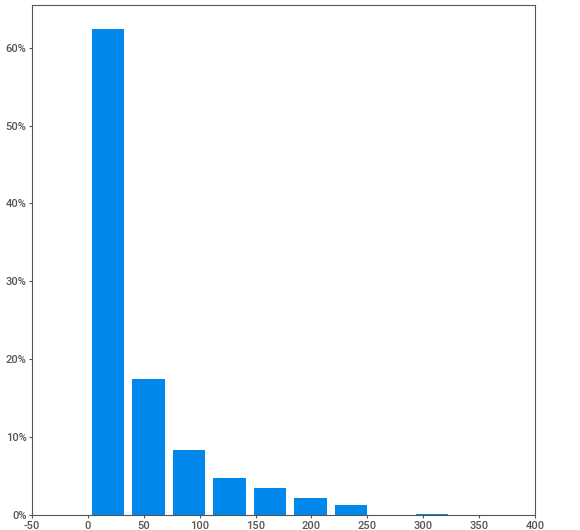
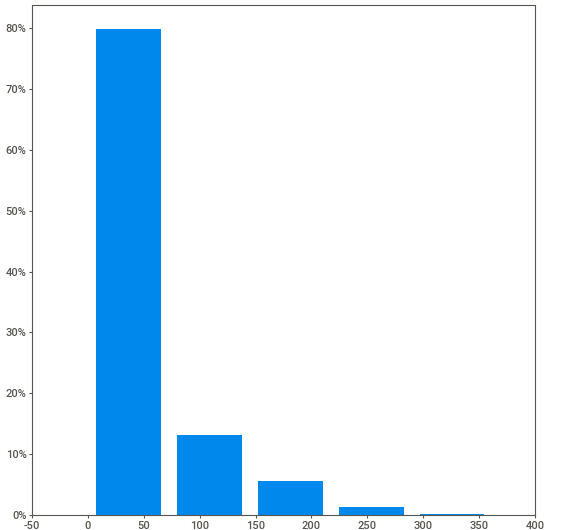
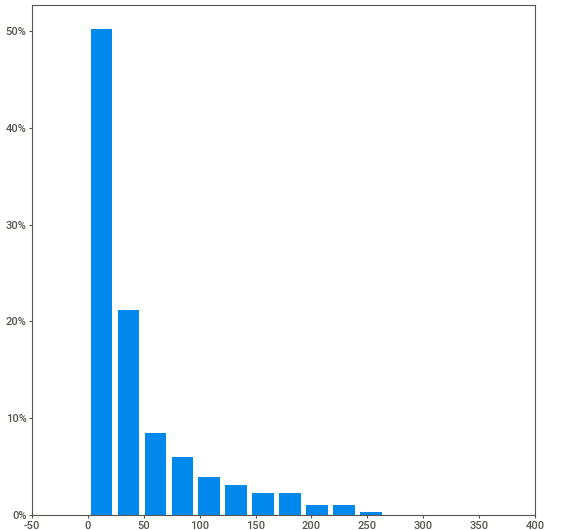
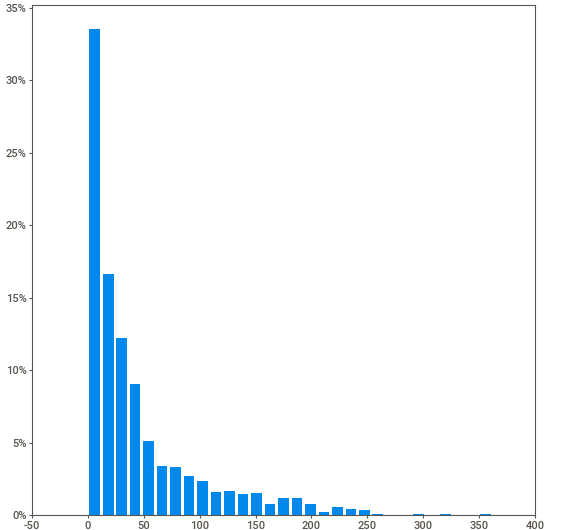
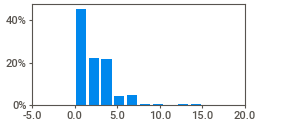
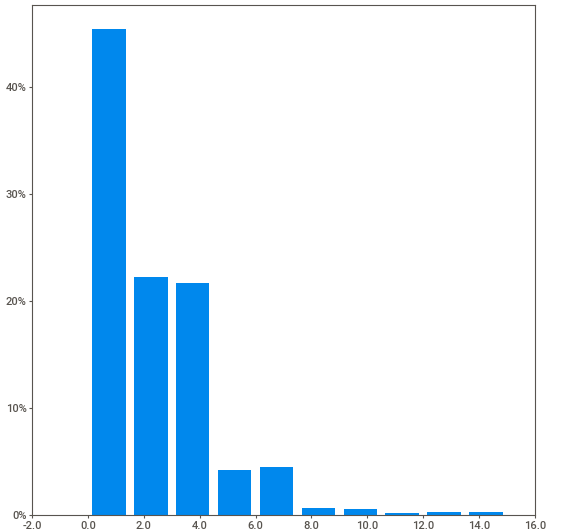
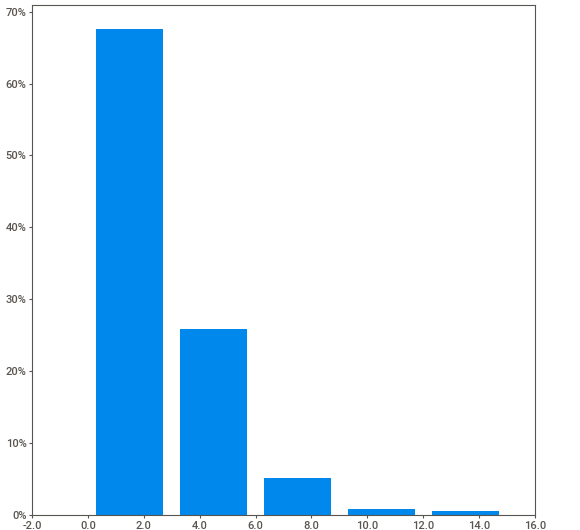
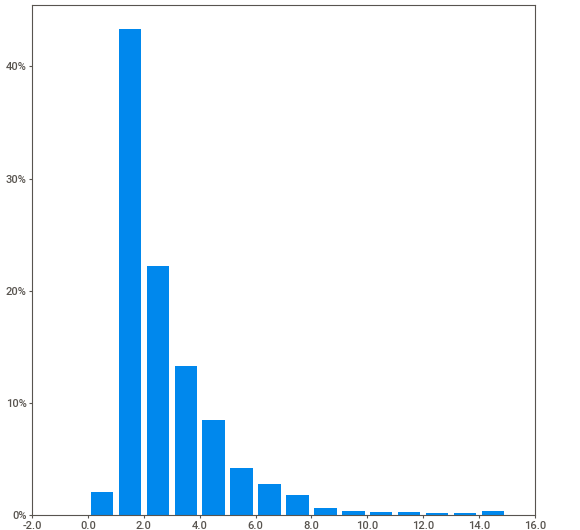
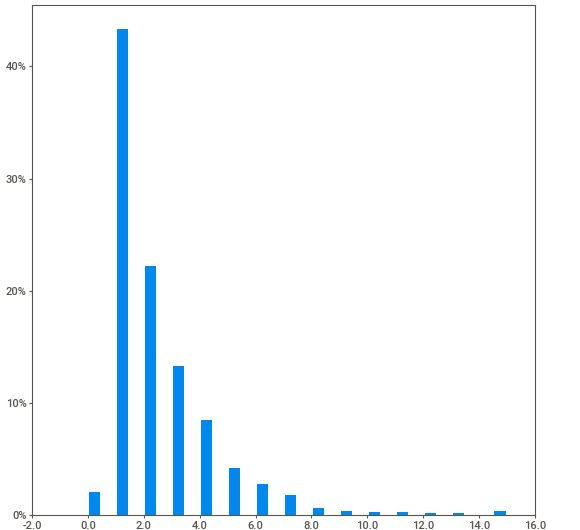
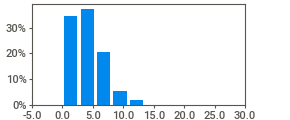
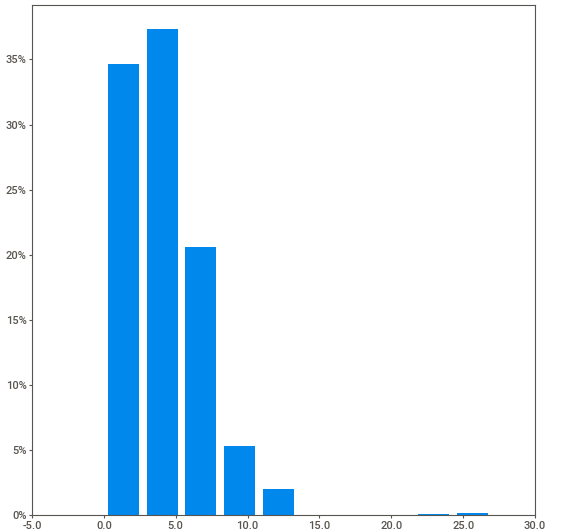
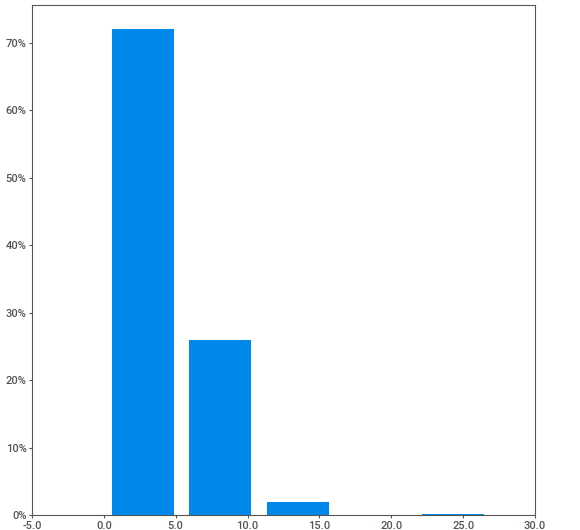
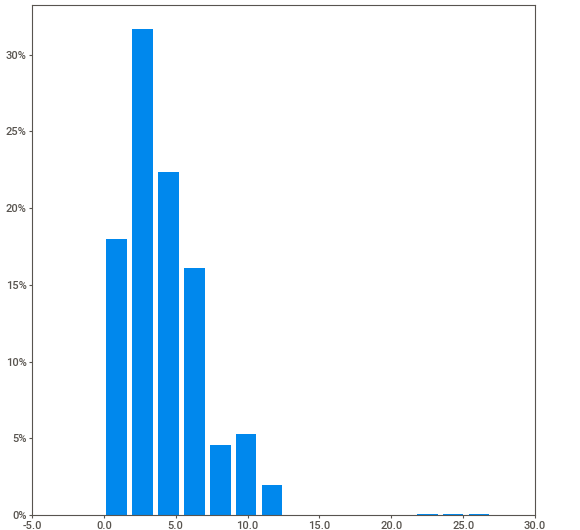
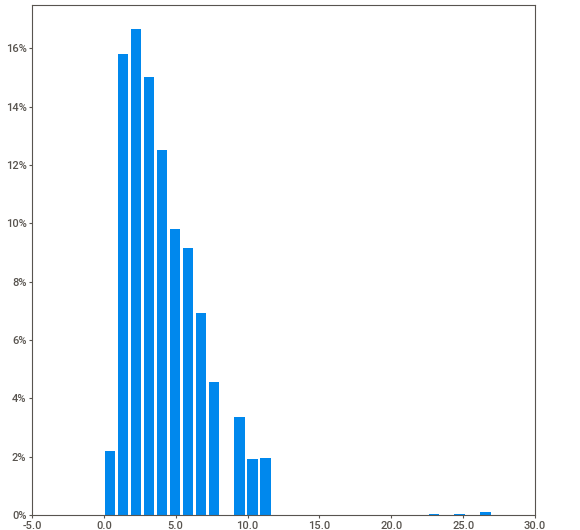
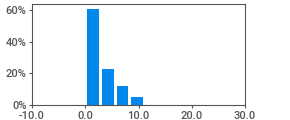
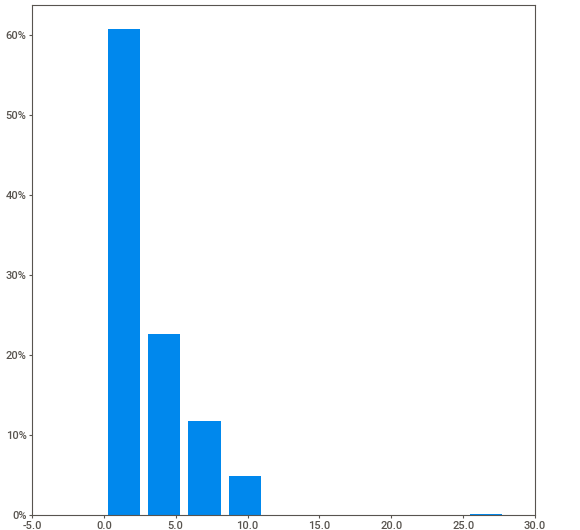
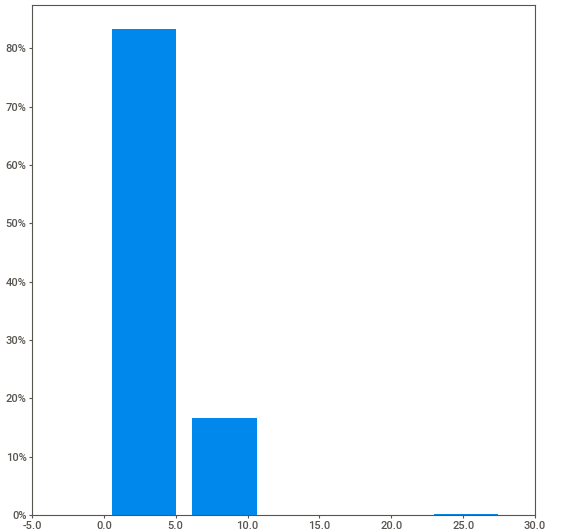
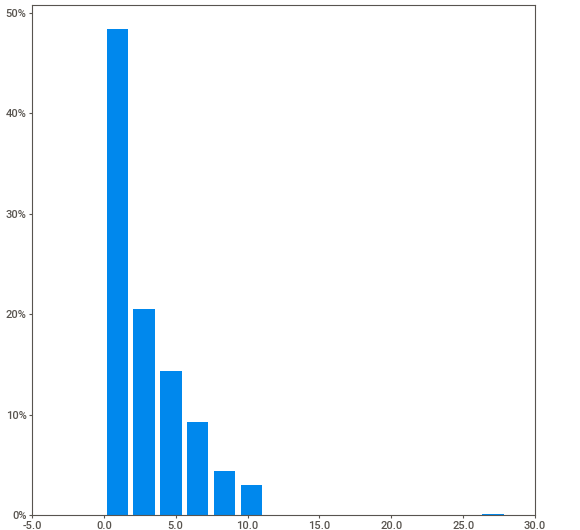
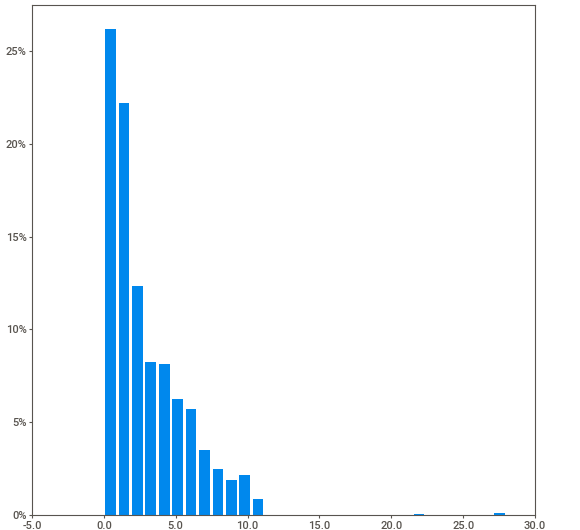
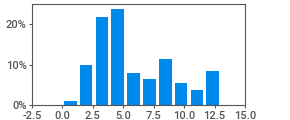
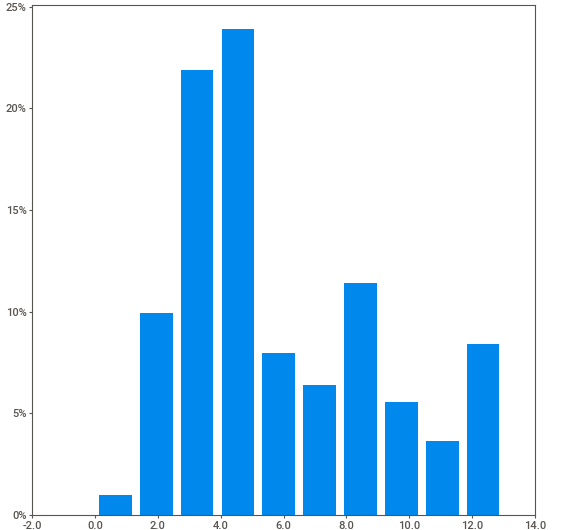
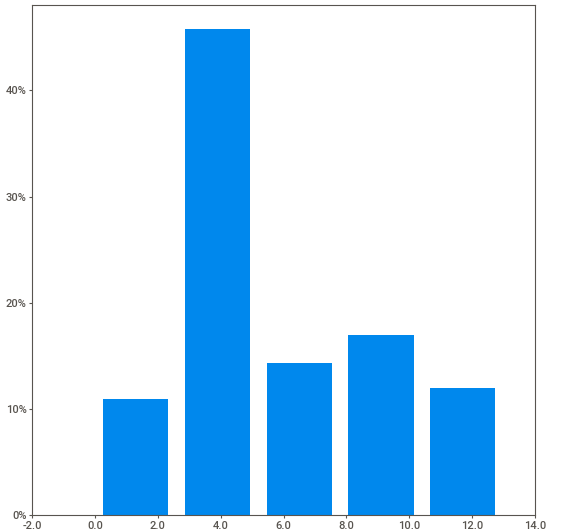
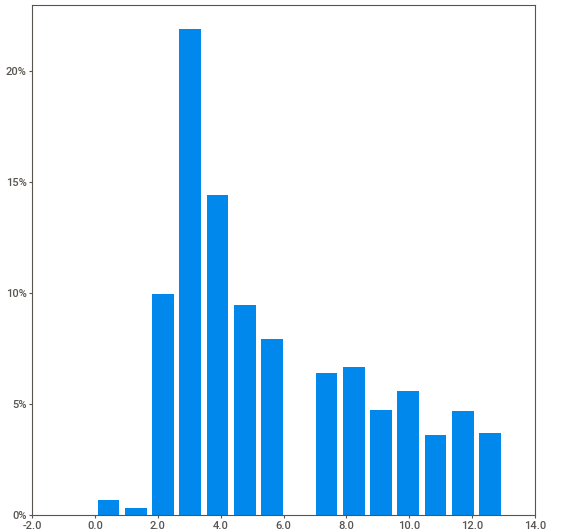
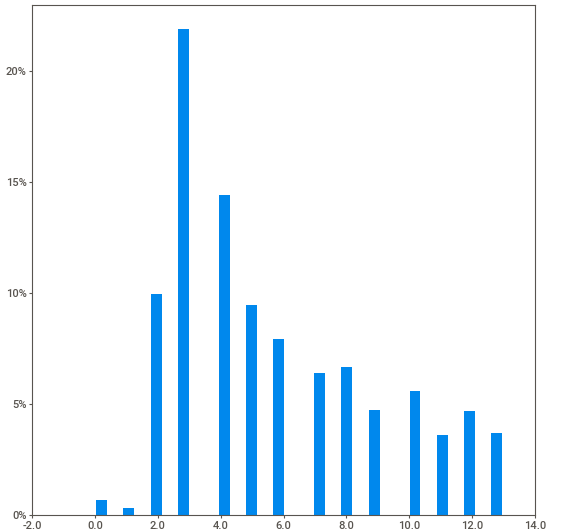
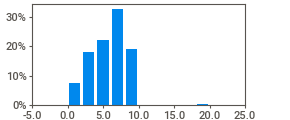
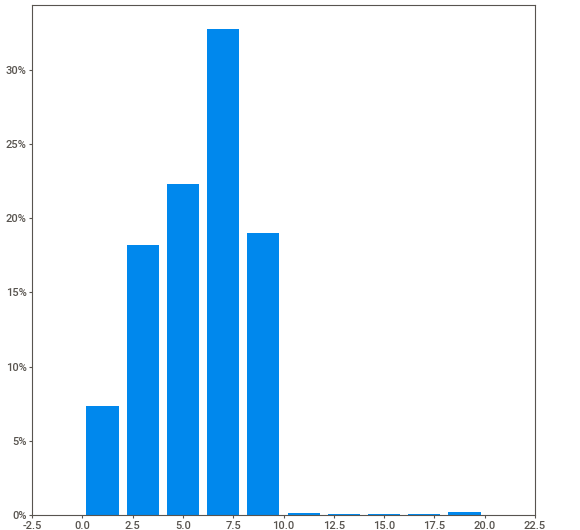
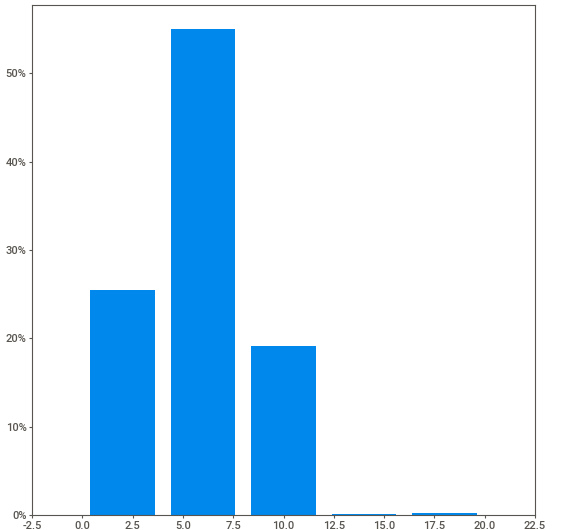
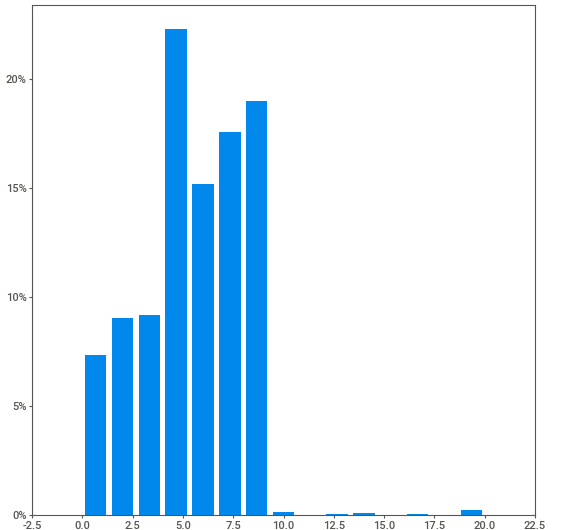
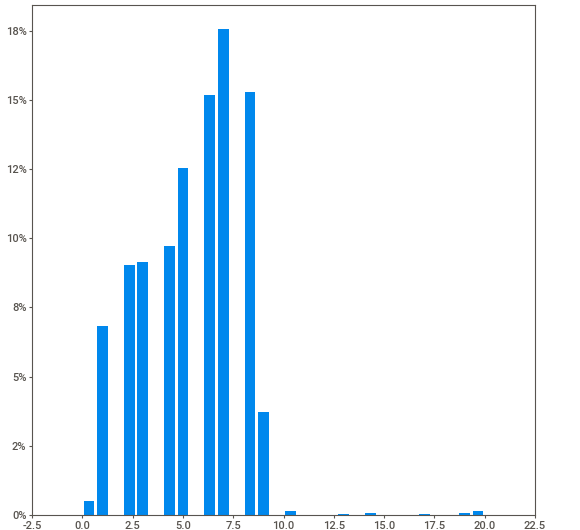
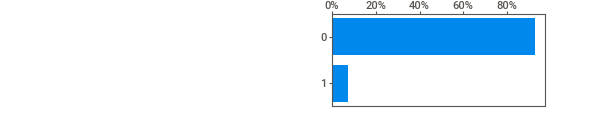
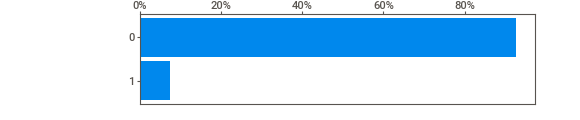
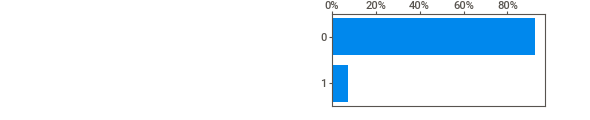
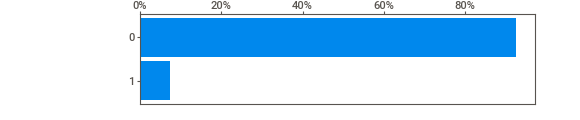
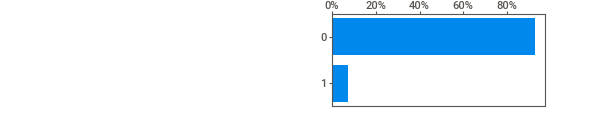
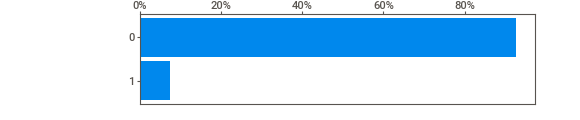
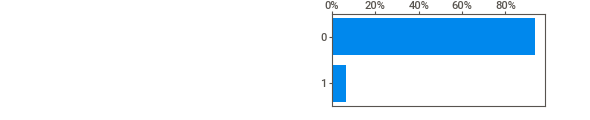
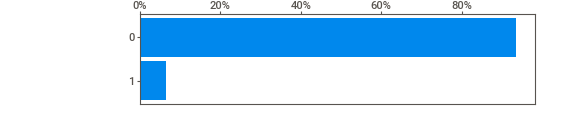
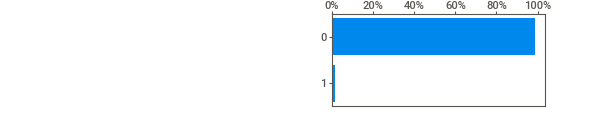
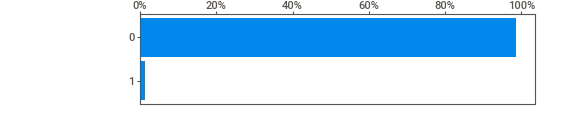
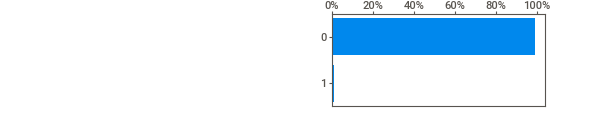
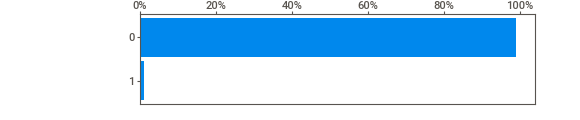
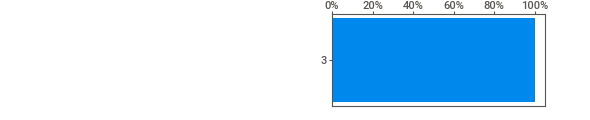
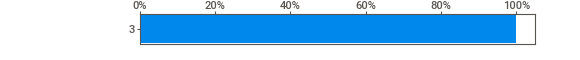
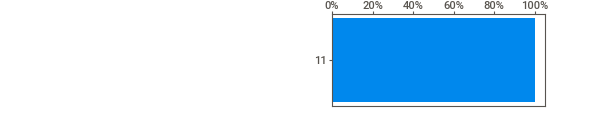
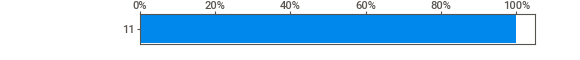
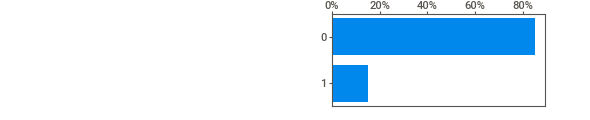
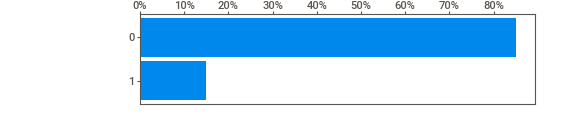
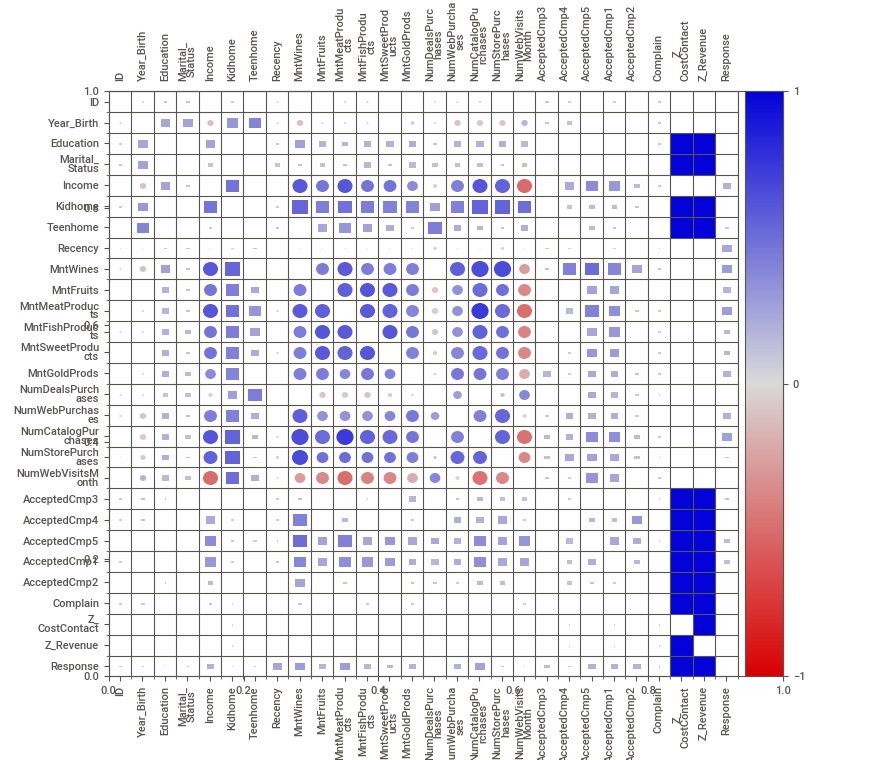
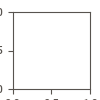

In [9]:
# Xem sweetviz_report trực tiếp trong notebook
report.show_notebook()

### Bài tập thực hành 2

In [10]:
# Cài đặt thư viện AutoViz
# !pip install autoviz

In [15]:
from autoviz.AutoViz_Class import AutoViz_Class

AV = AutoViz_Class()

df = AV.AutoViz(
    filename="Data/marketing_campaign.csv", sep='\t',
    depVar="",    #Data không có biến mục tiêu, để chuỗi rỗng, AutoViz sẽ chạy EDA tổng quát
    dfte=None,
    header=0,
    verbose=1,
    lowess=False,
    chart_format="svg",
)

Shape of your Data Set loaded: (2240, 29)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  1
    Number of Integer-Categorical Columns =  15
    Number of String-Categorical Columns =  2
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  7
    Number of Discrete String Columns =  1
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  1
    Number of Columns to Delete =  2
    29 Predictors classified...
        3 variable(s) removed since they were ID or low-information variables
        List of variables removed: ['ID', 'Z_CostContact', 'Z_Revenue']
To fix these data quality issu

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
ID,int64,0.000000,100,0.000000,11191.000000,Possible ID column: drop before modeling step.
Year_Birth,int64,0.000000,2,1893.000000,1996.000000,Column has 3 outliers greater than upper bound (2004.00) or lower than lower bound(1932.00). Cap them or remove them.
Education,object,0.000000,0,,,No issue
Marital_Status,object,0.000000,0,,,"3 rare categories: ['Alone', 'Absurd', 'YOLO']. Group them into a single category or drop the categories."
Income,float64,1.071429,NA,1730.000000,666666.000000,"24 missing values. Impute them with mean, median, mode, or a constant value such as 123., Column has 8 outliers greater than upper bound (118350.50) or lower than lower bound(-14525.50). Cap them or remove them."
Kidhome,int64,0.000000,0,0.000000,2.000000,No issue
Teenhome,int64,0.000000,0,0.000000,2.000000,No issue
Dt_Customer,object,0.000000,29,,,Possible high cardinality column with 663 unique values: Use hash encoding or text embedding to reduce dimension.
Recency,int64,0.000000,4,0.000000,99.000000,No issue
MntWines,int64,0.000000,34,0.000000,1493.000000,Column has 35 outliers greater than upper bound (1225.00) or lower than lower bound(-697.00). Cap them or remove them.


Could not draw wordcloud plot for Dt_Customer. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

All Plots done
Time to run AutoViz = 3 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     C:\Users\Dong\AppData\Roaming\nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     C:\Users\Dong\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     C:\Users\Dong\AppData\Roaming\nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     C:\Users\Dong\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     C:\Users\Dong\AppData\Roaming\nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |   

# KẾT THÚC LAB 01